<a href="https://colab.research.google.com/github/TrippleA001/DSN-30-days-of-learning-2025/blob/Personal/Machine%20Learning%20with%20Python%20and%20%20Azure/DSN_Microsoft_30_days_Pre_Bootcamp_Learning_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Foundations of data science for machine learning

###Introduction to machine learning

####Learning objectives

###Build classical machine learning models with supervised learning

####Learning objectives

###Introduction to data for machine learning

####Learning objectives

####Exercise: Titanic Dataset - Find and Visualize Missing Data

#####Preparing data

In [ ]:
import pandas as pd
!pip install missingno

# Load data from our dataset file into a pandas dataframe
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/titanic.csv
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/graphing.py
dataset = pd.read_csv('titanic.csv', index_col=False, sep=",", header=0)

# Let's take a look at the data
dataset.head()

--2025-08-07 22:43:08--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/titanic.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 61194 (60K) [text/plain]
Saving to: ‘titanic.csv.6’

titanic.csv.6       100%[===================>]  59.76K  --.-KB/s    in 0.006s  

2025-08-07 22:43:08 (9.10 MB/s) - ‘titanic.csv.6’ saved [61194/61194]

--2025-08-07 22:43:08--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/graphing.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awai

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Shape tells us how many rows and columns we have
print(dataset.shape)

(891, 12)


#####Finding Missing Data

In [ ]:
# Calculate the number of empty cells in each column
# The following line consists of three commands. Try
# to think about how they work together to calculate
# the number of missing entries per column
missing_data = dataset.isnull().sum().to_frame()

# Rename column holding the sums
missing_data = missing_data.rename(columns={0:'Empty Cells'})

# Print the results
print(missing_data)

             Empty Cells
PassengerId            0
Survived               0
Pclass                 0
Name                   0
Sex                    0
Age                  177
SibSp                  0
Parch                  0
Ticket                 0
Fare                   0
Cabin                687
Embarked               2


#####Missing Data Visualizations

<Axes: >

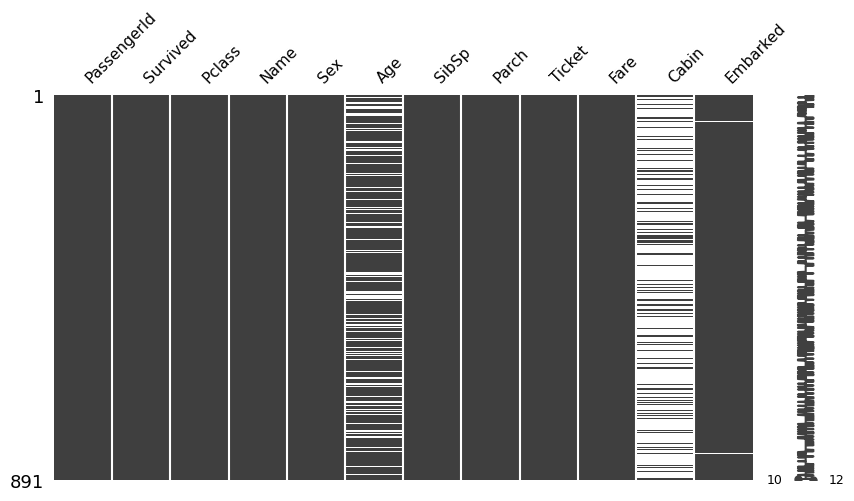

In [ ]:
import missingno as msno

# Plot a matrix chart, set chart and font size
msno.matrix(dataset, figsize=(10,5), fontsize=11)

#####Identifying Individual Passengers with Missing Information.

In [ ]:
# Select Passengers with unknown age
# Notice how we use .isnull() rows with no value
unknown_age = dataset[dataset["Age"].isnull()]

# Print only the columns we want for the moment (to better fit the screen)
# limit output to 20 rows
unknown_age[["PassengerId","Name", "Survived", "Age"]][:20]

,PassengerId,Name,Survived,Age
5,6,"Moran, Mr. James",0,NaN
17,18,"Williams, Mr. Charles Eugene",1,NaN
19,20,"Masselmani, Mrs. Fatima",1,NaN
26,27,"Emir, Mr. Farred Chehab",0,NaN
28,29,"O'Dwyer, Miss. Ellen ""Nellie""",1,NaN
29,30,"Todoroff, Mr. Lalio",0,NaN
31,32,"Spencer, Mrs. William Augustus (Marie Eugenie)",1,NaN
32,33,"Glynn, Miss. Mary Agatha",1,NaN
36,37,"Mamee, Mr. Hanna",1,NaN
42,43,"Kraeff, Mr. Theodor",0,NaN


In [ ]:
# Find those passengers with missing age or cabin information
missing_age = dataset["Age"].isnull()
missing_cabin = dataset["Cabin"].isnull()

# Find those passengers missing both
unknown_age_and_cabin = dataset[missing_age & missing_cabin]
print("Number of passengers missing age and cabin information:", len(unknown_age_and_cabin))

Number of passengers missing age and cabin information: 158


Text(0, 0.5, 'Passenger Count')

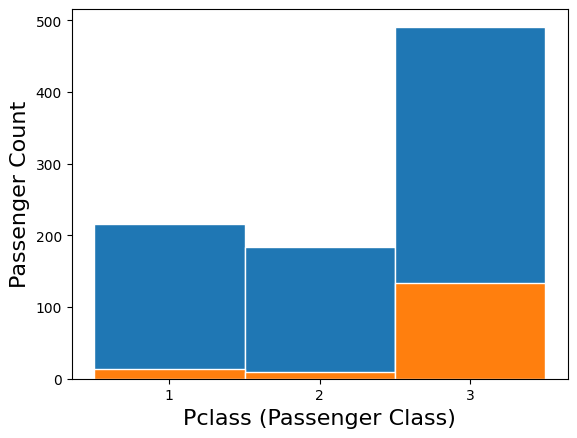

In [ ]:
import matplotlib.pyplot as plt

plt.hist((dataset.values[:,2]),bins=[0.5, 1.5, 2.5, 3.5],edgecolor="white")
plt.hist((unknown_age_and_cabin.values[:,2]),bins=[0.5, 1.5, 2.5, 3.5],edgecolor="white")
plt.xticks([1, 2, 3])
plt.xlabel("Pclass (Passenger Class)", fontsize=16)
plt.ylabel("Passenger Count", fontsize=16)

#####Missing as Zero

In [ ]:
import numpy as np

# Print out the average age of passengers for whom we have age data
mean_age = np.mean(dataset.Age)
print("The average age on the ship was", mean_age, "years old")

# Now, make another model where missing ages contained a '0'
dataset['Age_2'] = dataset['Age'].fillna(0)
mean_age = np.mean(dataset.Age_2)
print("The average age on the ship was", mean_age, "years old")

The average age on the ship was 29.69911764705882 years old
The average age on the ship was 23.79929292929293 years old


Text(0, 0.5, 'Passenger Count')

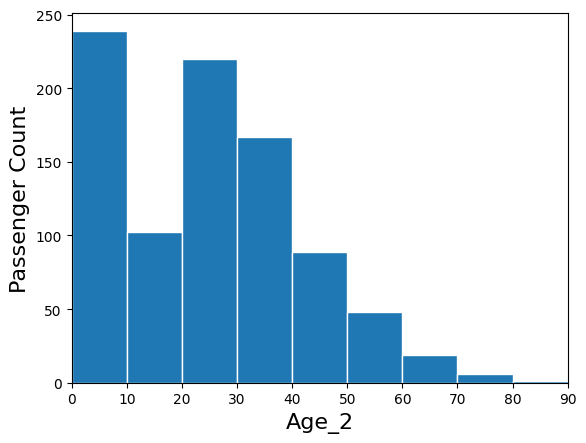

In [ ]:
plt.hist(dataset["Age_2"],bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90],edgecolor="white")
plt.xticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90])
plt.xlim([0, 90])
plt.xlabel("Age_2", fontsize=16)
plt.ylabel("Passenger Count", fontsize=16)

#####Handling Missing Data

######Option 1: Delete data with missing rows

In [ ]:
# Create a "clean" dataset, where we cumulatively fix missing values
# Start by removing rows ONLY where "Embarked" has no values
print(f"The original size of our dataset was", dataset.shape)
clean_dataset = dataset.dropna(subset=["Embarked"])
clean_dataset = clean_dataset.reindex()

# How many rows do we have now?
print("The shape for the clean dataset is", clean_dataset.shape)

The original size of our dataset was (891, 13)
The shape for the clean dataset is (889, 13)


######Option 2: Replace empty values with the mean or median for that data.

In [ ]:
# Calculate the mean value for the Age column
mean_age = clean_dataset["Age"].mean()

print("The mean age is", mean_age)

# Replace empty values in "Age" with the mean calculated above
clean_dataset.fillna({"Age": mean_age}, inplace=True)

# Let's see what the clean dataset looks like now
print(clean_dataset.isnull().sum().to_frame().rename(columns={0:'Empty Cells'}))

The mean age is 29.64209269662921
             Empty Cells
PassengerId            0
Survived               0
Pclass                 0
Name                   0
Sex                    0
Age                    0
SibSp                  0
Parch                  0
Ticket                 0
Fare                   0
Cabin                687
Embarked               0
Age_2                  0


######Option 3: Assign a new category to unknown categorical data

In [ ]:
# Assign unknown to records where "Cabin" is empty
clean_dataset.fillna({"Cabin":"Unknown"}, inplace=True)

# Let's see what the clean dataset looks like now
print(clean_dataset.isnull().sum().to_frame().rename(columns={0:'Empty Cells'}))

             Empty Cells
PassengerId            0
Survived               0
Pclass                 0
Name                   0
Sex                    0
Age                    0
SibSp                  0
Parch                  0
Ticket                 0
Fare                   0
Cabin                  0
Embarked               0
Age_2                  0


#####Summary

Missing values can affect the way a Machine Learning model works in a negative way. It's important to quickly verify the existence of data gaps and the locations of those gaps.

You can now get a big picture of what's missing. Using lists and charts, you can select only those items that you must address.

In this exercise, we practiced:

* Finding and visualizing missing dataset values with the pandas and missingno packages.
* Checking whether a dataset uses the value '0' to represent missing values.
* Handling missing data in three ways: removing rows that contain missing values, replacing the missing values with the mean or median of that particular feature, and creating a new Unknown category when dealing with categorical data.

####Exercise: Titanic Dataset - Visualising Different Types of Data

#####First Inspection

In [ ]:
import pandas as pd

# Load data from our dataset file into a pandas dataframe
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/titanic.csv
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/graphing.py
dataset = pd.read_csv('titanic.csv', index_col=False, sep=",", header=0)

# Let's take a look at the data
dataset.head()


--2025-08-07 22:43:10--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/titanic.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 61194 (60K) [text/plain]
Saving to: ‘titanic.csv.7’

titanic.csv.7       100%[===================>]  59.76K  --.-KB/s    in 0.009s  

2025-08-07 22:43:10 (6.77 MB/s) - ‘titanic.csv.7’ saved [61194/61194]

--2025-08-07 22:43:10--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/graphing.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awai

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


#####Visualising Ordinal Data

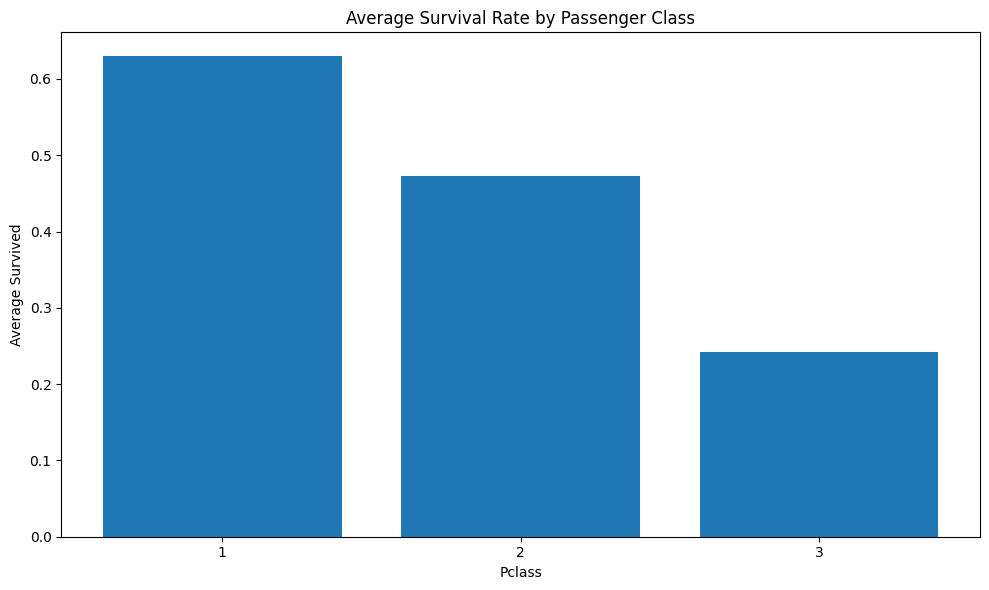

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns  # For better boxplots

# Group by 'Pclass' and compute average 'Survived'
avg_survived = dataset.groupby('Pclass')['Survived'].mean()

# Plot histogram (bar chart of averages)
plt.figure(figsize=(10, 6))
plt.bar(avg_survived.index.astype(str), avg_survived.values)
plt.xlabel('Pclass')
plt.ylabel('Average Survived')
plt.title('Average Survival Rate by Passenger Class')

plt.tight_layout()
plt.show()

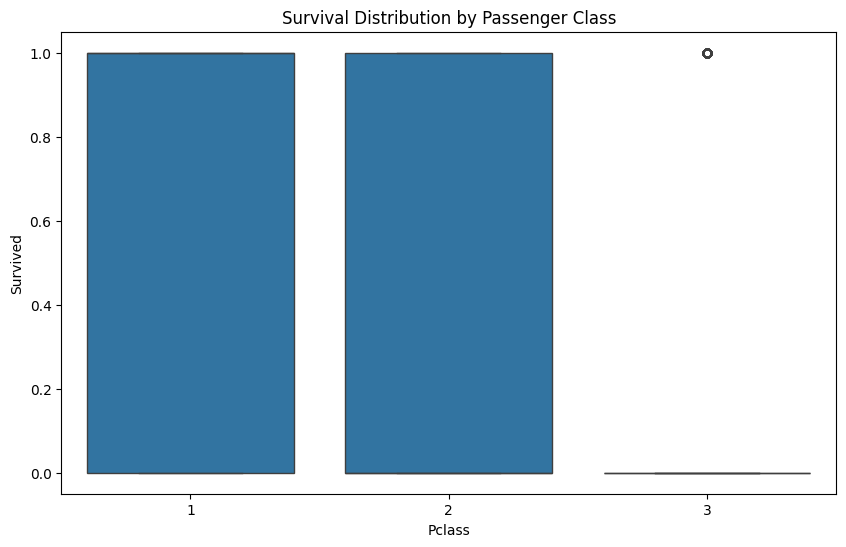

In [ ]:
# Optionally add a boxplot
# We use seaborn's boxplot to display distribution of 'Survived' by 'Pclass'
plt.figure(figsize=(10, 6))
sns.boxplot(x='Pclass', y='Survived', data=dataset)
plt.xlabel('Pclass')
plt.ylabel('Survived')
plt.title('Survival Distribution by Passenger Class')

#plt.tight_layout()
plt.show()

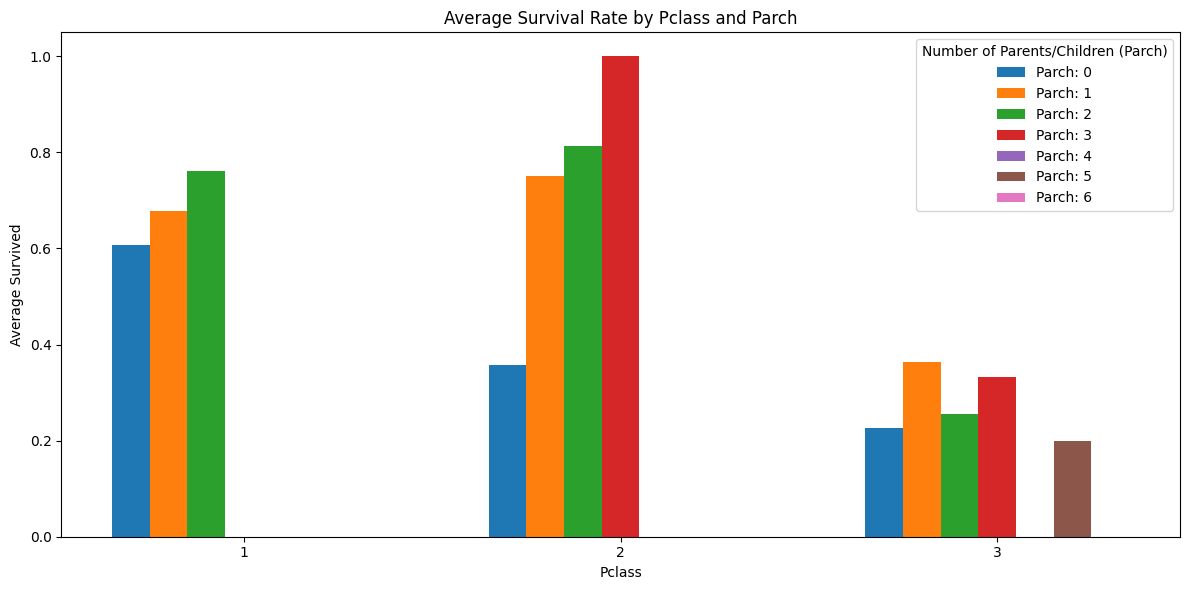

In [ ]:
import numpy as np

# Group by Pclass and Parch, and compute the average of Survived
grouped = dataset.groupby(['Pclass', 'Parch'])['Survived'].mean().unstack(fill_value=0)

# Create bar plot
x = np.arange(len(grouped.index))  # the label locations
width = 0.1  # width of the bars

fig, ax = plt.subplots(figsize=(12, 6))

# Loop through each Parch value to create grouped bars
for i, parch in enumerate(grouped.columns):
    ax.bar(x + i * width, grouped[parch], width, label=f'Parch: {parch}')

# Labeling
ax.set_xlabel('Pclass')
ax.set_ylabel('Average Survived')
ax.set_title('Average Survival Rate by Pclass and Parch')
ax.set_xticks(x + width * (len(grouped.columns) - 1) / 2)
ax.set_xticklabels(grouped.index.astype(str))
ax.legend(title='Number of Parents/Children (Parch)')

plt.tight_layout()
plt.show()

/tmp/ipython-input-3108894609.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grouped, labels=sorted(dataset['Pclass'].dropna().unique()))


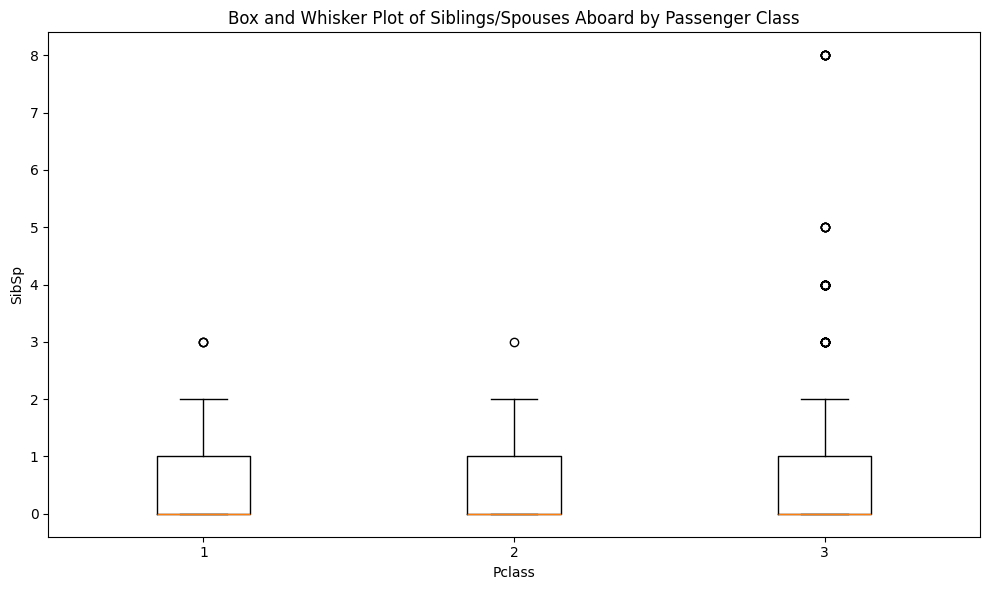

In [ ]:
# Group data by 'Pclass'
grouped = [group['SibSp'].dropna().values for name, group in dataset.groupby('Pclass')]

# Create the boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(grouped, labels=sorted(dataset['Pclass'].dropna().unique()))
plt.xlabel('Pclass')
plt.ylabel('SibSp')
plt.title('Box and Whisker Plot of Siblings/Spouses Aboard by Passenger Class')

plt.tight_layout()
plt.show()

#####Visualising Continuous Data

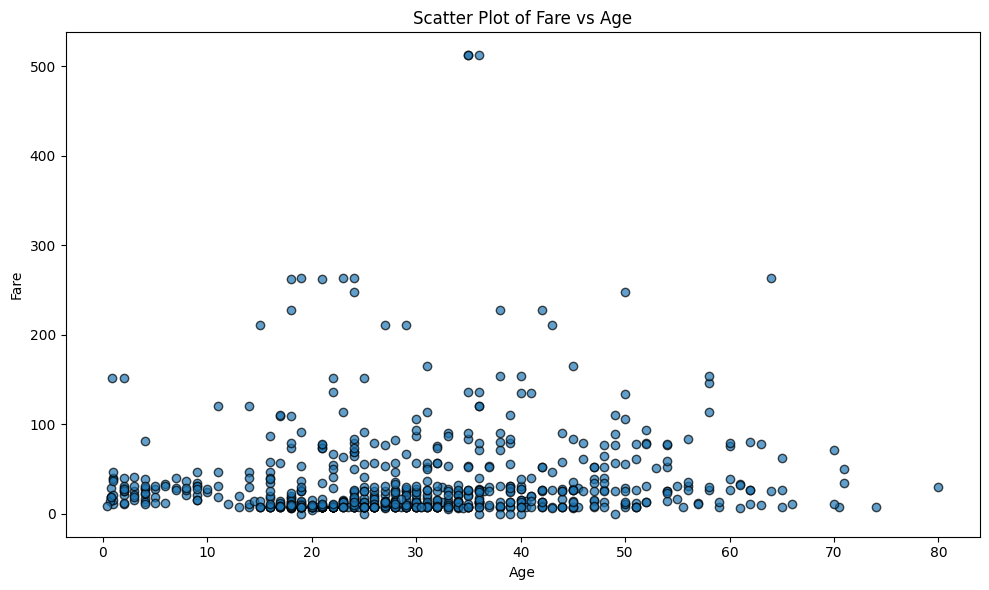

In [ ]:
# Remove rows with missing values in Age or Fare
filtered_data = dataset.dropna(subset=['Age', 'Fare'])

# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(filtered_data['Age'], filtered_data['Fare'], alpha=0.7, edgecolors='k')

# Labeling
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Scatter Plot of Fare vs Age')

plt.tight_layout()
plt.show()

/tmp/ipython-input-3340020106.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_survival_by_fare = fare_data.groupby('Fare_bin')['Survived'].mean()


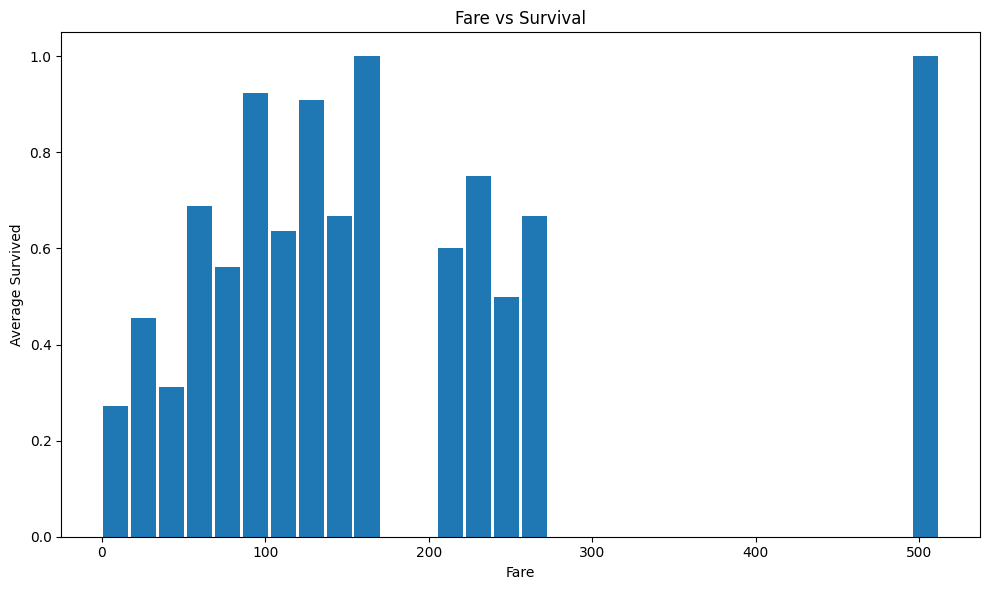

<Figure size 1000x600 with 0 Axes>

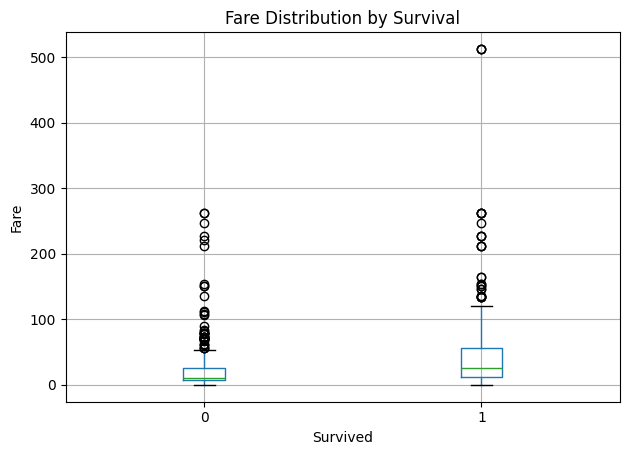

/tmp/ipython-input-3340020106.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age_data['Age_bin'] = pd.cut(age_data['Age'], bins)
/tmp/ipython-input-3340020106.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_survival_by_age = age_data.groupby('Age_bin')['Survived'].mean()


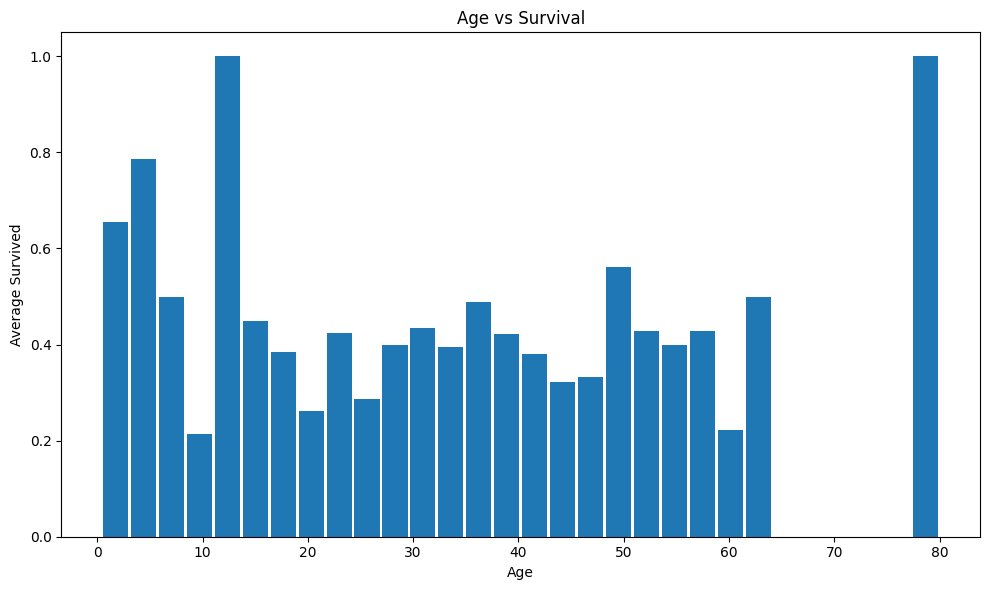

<Figure size 1000x600 with 0 Axes>

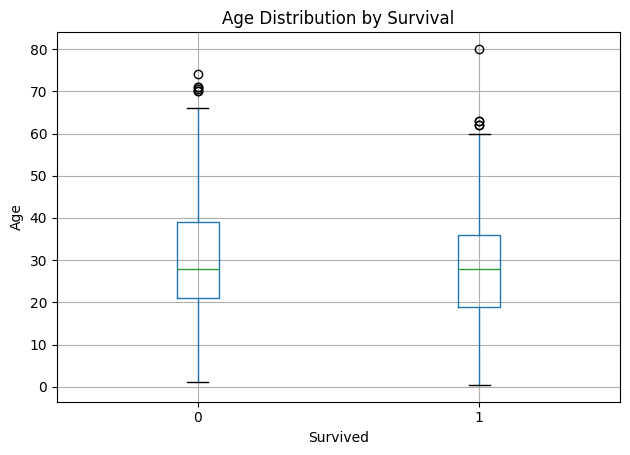

In [ ]:
# Drop missing values
fare_data = dataset.dropna(subset=['Fare', 'Survived'])

# Bin the Fare values
bins = np.linspace(fare_data['Fare'].min(), fare_data['Fare'].max(), 31)  # 30 bins = 31 edges
fare_data['Fare_bin'] = pd.cut(fare_data['Fare'], bins)

# Compute average survival per Fare bin
avg_survival_by_fare = fare_data.groupby('Fare_bin')['Survived'].mean()

# Midpoints of the bins for plotting
bin_midpoints = [interval.mid for interval in avg_survival_by_fare.index]

# Plot histogram of averages
plt.figure(figsize=(10, 6))
plt.bar(bin_midpoints, avg_survival_by_fare, width=(bins[1] - bins[0]) * 0.9)
plt.xlabel('Fare')
plt.ylabel('Average Survived')
plt.title('Fare vs Survival')

plt.tight_layout()
plt.show()

# Optional boxplot of Fare by Survived
plt.figure(figsize=(10, 6))
dataset.dropna(subset=['Fare', 'Survived'])[['Fare', 'Survived']].boxplot(by='Survived')
plt.title('Fare Distribution by Survival')
plt.suptitle('')  # Remove default Pandas title
plt.xlabel('Survived')
plt.ylabel('Fare')
plt.tight_layout()
plt.show()

# Drop missing values
age_data = dataset.dropna(subset=['Age', 'Survived'])

# Bin the Age values
bins = np.linspace(age_data['Age'].min(), age_data['Age'].max(), 31)
age_data['Age_bin'] = pd.cut(age_data['Age'], bins)

# Compute average survival per Age bin
avg_survival_by_age = age_data.groupby('Age_bin')['Survived'].mean()
bin_midpoints = [interval.mid for interval in avg_survival_by_age.index]

# Plot histogram of averages
plt.figure(figsize=(10, 6))
plt.bar(bin_midpoints, avg_survival_by_age, width=(bins[1] - bins[0]) * 0.9)
plt.xlabel('Age')
plt.ylabel('Average Survived')
plt.title('Age vs Survival')

plt.tight_layout()
plt.show()

# Optional boxplot of Age by Survived
plt.figure(figsize=(10, 6))
dataset.dropna(subset=['Age', 'Survived'])[['Age', 'Survived']].boxplot(by='Survived')
plt.title('Age Distribution by Survival')
plt.suptitle('')
plt.xlabel('Survived')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

#####Visualising Categorical Data

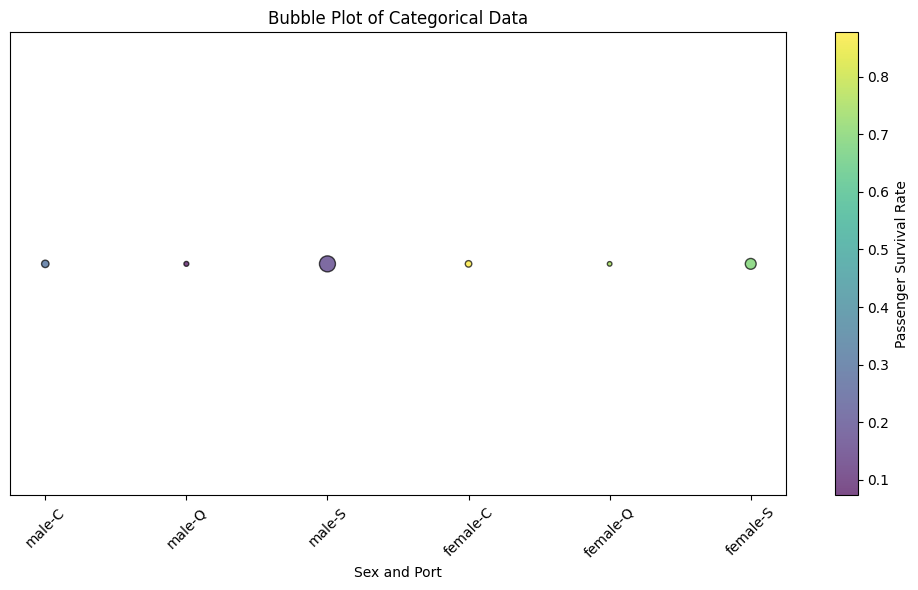

In [ ]:
import numpy as np

# Create some simple functions
# Read their descriptions to find out more
def get_rows(sex, port):
    '''Returns rows that match in terms of sex and embarkment port'''
    return dataset[(dataset.Embarked == port) & (dataset.Sex == sex)]

def proportion_survived(sex, port):
    '''Returns the proportion of people meeting criteria who survived'''
    survived = get_rows(sex, port).Survived
    return np.mean(survived)

# Make two columns of data - together these represent each combination
# of sex and embarkment port
sexes = ["male", "male", "male", "female","female", "female"]
ports = ["C", "Q", "S" ] * 2

# Calculate the number of passengers at each port + sex combination
passenger_count = [len(get_rows(sex, port)) for sex,port in zip(sexes, ports)]

# Calculate the proportion of passengers from each port + sex combination who survived
passenger_survival = [proportion_survived(sex, port) for sex,port in zip(sexes, ports)]

# Combine into a single data frame
table = pd.DataFrame(dict(
    sex=sexes,
    port=ports,
    passenger_count=passenger_count,
    passenger_survival_rate=passenger_survival
))

# Make a bubble plot
# This is just a scatter plot but each entry in the plot
# has a size and color. We set color to passenger_survival
# and size to the number of passengers

# Define x-axis labels as combined categories (e.g., "male-C")
table['category'] = table['sex'] + '-' + table['port']

# Set up the figure
plt.figure(figsize=(10, 6))

# Create the scatter plot (bubble plot)
scatter = plt.scatter(
    x=table['category'],
    y=[1] * len(table),  # Place all bubbles on same y level (optional)
    s=table['passenger_count'] * 0.3,  # Size scaled
    c=table['passenger_survival_rate'],  # Color by survival rate
    cmap='viridis',  # Color map
    alpha=0.7,
    edgecolors='k'
)

# Colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Passenger Survival Rate')

# Formatting
plt.title('Bubble Plot of Categorical Data')
plt.xlabel('Sex and Port')
plt.yticks([])  # Hide y-axis ticks since it's not meaningful
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#####Summary

You learned about different types of data, and you practiced data exploration through graphs.

Through these, we've discovered that some features are related to others, and that many features seem to influence the survival rate.

####Exercise - Predict unknown values using one-hot vectors

#####Data prepartion

In [ ]:
import pandas
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/m0c_logistic_regression.py
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/titanic.csv

# Open our dataset from file
dataset = pandas.read_csv("titanic.csv", index_col=False, sep=",", header=0)

# Fill missing cabin information with 'Unknown'
dataset.fillna({"Cabin":"Unknown"}, inplace=True)

# Remove rows missing Age information
dataset.dropna(subset=["Age"], inplace=True)

# Remove the Name, PassengerId, and Ticket fields
# This is optional; it makes it easier to read our print-outs
dataset.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)

dataset.head()


--2025-08-07 22:43:12--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/m0c_logistic_regression.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 827 [text/plain]
Saving to: ‘m0c_logistic_regression.py.2’

m0c_logistic_regres 100%[===================>]     827  --.-KB/s    in 0s      

2025-08-07 22:43:12 (50.9 MB/s) - ‘m0c_logistic_regression.py.2’ saved [827/827]

--2025-08-07 22:43:12--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/titanic.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... c

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,Unknown,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,Unknown,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,Unknown,S


#####Numerical Only

In [ ]:
from m0c_logistic_regression import train_logistic_regression

features = ["Age", "Pclass", "SibSp", "Parch", "Fare"]
loss_numerical_only = train_logistic_regression(dataset, features)

print(f"Numerical-Only, Log-Loss (cost): {loss_numerical_only}")

Numerical-Only, Log-Loss (cost): 0.6121682789483441


#####Binary Categorical Features

In [ ]:
# Swap male / female with numerical values
# We can do this because there are only two categories
dataset["IsFemale"] = dataset.Sex.replace({'male':0, 'female':1})

# Print out the first few rows of the dataset
print(dataset.head())

# Run and test the model, also using IsFemale this time
features = ["Age", "Pclass", "SibSp", "Parch", "Fare", "IsFemale"]
loss_binary_categoricals = train_logistic_regression(dataset, features)

print(f"\nNumerical + Sex, Log-Loss (cost): {loss_binary_categoricals}")

   Survived  Pclass     Sex   Age  SibSp  Parch     Fare    Cabin Embarked  \
0         0       3    male  22.0      1      0   7.2500  Unknown        S   
1         1       1  female  38.0      1      0  71.2833      C85        C   
2         1       3  female  26.0      0      0   7.9250  Unknown        S   
3         1       1  female  35.0      1      0  53.1000     C123        S   
4         0       3    male  35.0      0      0   8.0500  Unknown        S   

   IsFemale  
0         0  
1         1  
2         1  
3         1  
4         0  


/tmp/ipython-input-3184598399.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset["IsFemale"] = dataset.Sex.replace({'male':0, 'female':1})



Numerical + Sex, Log-Loss (cost): 0.4707118595966243


#####One-Hot Encoding

In [ ]:
# Get all possible categories for the "PClass" column
print(f"Possible values for PClass: {dataset['Pclass'].unique()}")

# Use Pandas to One-Hot encode the PClass category
dataset_with_one_hot = pandas.get_dummies(dataset, columns=["Pclass"], drop_first=False)

# Add back in the old Pclass column, for learning purposes
dataset_with_one_hot["Pclass"] = dataset.Pclass

# Print out the first few rows
dataset_with_one_hot.head()

Possible values for PClass: [3 1 2]


,Survived,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,IsFemale,Pclass_1,Pclass_2,Pclass_3,Pclass
0,0,male,22.0,1,0,7.2500,Unknown,S,0,False,False,True,3
1,1,female,38.0,1,0,71.2833,C85,C,1,True,False,False,1
2,1,female,26.0,0,0,7.9250,Unknown,S,1,False,False,True,3
3,1,female,35.0,1,0,53.1000,C123,S,1,True,False,False,1
4,0,male,35.0,0,0,8.0500,Unknown,S,0,False,False,True,3


In [ ]:
# Run and test the model, also using Pclass as a categorical feature this time
features = ["Age", "SibSp", "Parch", "Fare", "IsFemale",
            "Pclass_1", "Pclass_2", "Pclass_3"]

loss_pclass_categorical = train_logistic_regression(dataset_with_one_hot, features)

print(f"\nNumerical, Sex, Categorical Pclass, Log-Loss (cost): {loss_pclass_categorical}")


Numerical, Sex, Categorical Pclass, Log-Loss (cost): 0.4717302923736227


In [ ]:
# Use Pandas to One-Hot encode the Cabin and Pclass categories
dataset_with_one_hot = pandas.get_dummies(dataset, columns=["Pclass", "Cabin"], drop_first=False)

# Find cabin column names
cabin_column_names = list(c for c in dataset_with_one_hot.columns if c.startswith("Cabin_"))

# Print out how many cabins there were
print(len(cabin_column_names), "cabins found")

# Make a list of features
features = ["Age", "SibSp", "Parch", "Fare", "IsFemale",
            "Pclass_1", "Pclass_2", "Pclass_3"] + \
            cabin_column_names

# Run the model and print the result
loss_cabin_categorical = train_logistic_regression(dataset_with_one_hot, features)

print(f"\nNumerical, Sex, Categorical Pclass, Cabin, Log-Loss (cost): {loss_cabin_categorical}")

135 cabins found

Numerical, Sex, Categorical Pclass, Cabin, Log-Loss (cost): 0.4600048688202762


In [ ]:
# We have cabin names, like A31, G45. The letter refers to the deck that
# the cabin was on. Extract just the deck and save it to a column.
dataset["Deck"] = [c[0] for c in dataset.Cabin]

print("Decks: ", sorted(dataset.Deck.unique()))

# Create one-hot vectors for:
# Pclass - the class of ticket. (This could be treated as ordinal or categorical)
# Deck - the deck that the cabin was on
dataset_with_one_hot = pandas.get_dummies(dataset, columns=["Pclass", "Deck"], drop_first=False)

# Find the deck names
deck_of_cabin_column_names = list(c for c in dataset_with_one_hot.columns if c.startswith("Deck_"))

features = ["Age", "IsFemale", "SibSp", "Parch", "Fare",
            "Pclass_1", "Pclass_2", "Pclass_3",
            "Deck_A", "Deck_B", "Deck_C", "Deck_D",
            "Deck_E", "Deck_F", "Deck_G", "Deck_U", "Deck_T"]

loss_deck = train_logistic_regression(dataset_with_one_hot, features)

print(f"\nSimplifying Cabin Into Deck, Log-Loss (cost): {loss_deck}")

Decks:  ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T', 'U']

Simplifying Cabin Into Deck, Log-Loss (cost): 0.4588927791855666


#####Comparing Models

In [ ]:
# Use a dataframe to create a comparison table of metrics
# Copy metrics from previous Unit

l =[["Numeric Features Only", loss_numerical_only],
    ["Adding Sex as Binary", loss_binary_categoricals],
    ["Treating Pclass as Categorical", loss_pclass_categorical],
    ["Using Cabin as Categorical", loss_cabin_categorical],
    ["Using Deck rather than Cabin", loss_deck]]

pandas.DataFrame(l, columns=["Dataset", "Log-Loss (Lower is better)"])

,Dataset,Log-Loss (Lower is better)
0,Numeric Features Only,0.612168
1,Adding Sex as Binary,0.470712
2,Treating Pclass as Categorical,0.471730
3,Using Cabin as Categorical,0.460005
4,Using Deck rather than Cabin,0.458893


#####Summary

In this unit you learned how to use one-hot encoding to address categorical data.

We also explored how critical thinking about the problem at hand can sometimes improve a solution more than simply including all possible features in a model.

####Summary

We covered much ground. Let's review some of the key messages.

**What are data categories?**

Data falls into several conceptual categories. The most common are:

* Continuous data (numbers).
* Categorical data that has no order.
* Ordinal data, which can be treated as numbers or ordered categories.

Computers store data as distinct types, and we usually try to match the datatype to the specific data. For example, to store continuous data, floating-point numbers work best because floating-point numbers allow the storage of fractions. By contrast, categorical data often arrive as strings (text) and must be converted to one-hot vectors for the computer to understand them properly.

**What makes a good dataset?**

We learned that a dataset is helpful if:

- It contains relevant information.
- It's complete.
- It's a good representation of the population (real-world).

If we must deal with incomplete data, we can take steps to make sure that incomplete data doesn't cause significant issues. When doing so, we must avoid introduction of new issues, such as changes that would make the data no longer representative.

**Thinking about data**

We showed how data visualization can help to build an understanding of what might be useful in a model. Use of different types of graphs, colors, and the like can be fun and make complex information much more intuitive.

We learned that understanding our data lets us make better decisions about our models. In the final exercise, we improved our model as we explored the count of cabins on the Titanic, and we considered how this information helped us. Yet overall, we found that we could improve this through simplification into nine Deck labels.

###Explore and analyze data with Python

####Learning objectives

####Exercise - Explore data with NumPy and Pandas

#####Exploring data arrays with NumPy

In [ ]:
data = [50,50,47,97,49,3,53,42,26,74,82,62,37,15,70,27,36,35,48,52,63,64]
data

[50,
 50,
 47,
 97,
 49,
 3,
 53,
 42,
 26,
 74,
 82,
 62,
 37,
 15,
 70,
 27,
 36,
 35,
 48,
 52,
 63,
 64]

In [ ]:
import numpy as np

grades = np.array(data)
grades

array([50, 50, 47, 97, 49,  3, 53, 42, 26, 74, 82, 62, 37, 15, 70, 27, 36,
       35, 48, 52, 63, 64])

In [ ]:
print (type(data),'x 2:', data * 2)
print('---')
print (type(grades),'x 2:', grades * 2)

<class 'list'> x 2: [50, 50, 47, 97, 49, 3, 53, 42, 26, 74, 82, 62, 37, 15, 70, 27, 36, 35, 48, 52, 63, 64, 50, 50, 47, 97, 49, 3, 53, 42, 26, 74, 82, 62, 37, 15, 70, 27, 36, 35, 48, 52, 63, 64]
---
<class 'numpy.ndarray'> x 2: [100 100  94 194  98   6 106  84  52 148 164 124  74  30 140  54  72  70
  96 104 126 128]


In [ ]:
grades.shape

(22,)

In [ ]:
grades[0]

np.int64(50)

In [ ]:
grades.mean()

np.float64(49.18181818181818)

In [ ]:
# Define an array of study hours
study_hours = [10.0,11.5,9.0,16.0,9.25,1.0,11.5,9.0,8.5,14.5,15.5,
               13.75,9.0,8.0,15.5,8.0,9.0,6.0,10.0,12.0,12.5,12.0]

# Create a 2D array (an array of arrays)
student_data = np.array([study_hours, grades])

# display the array
student_data

array([[10.  , 11.5 ,  9.  , 16.  ,  9.25,  1.  , 11.5 ,  9.  ,  8.5 ,
        14.5 , 15.5 , 13.75,  9.  ,  8.  , 15.5 ,  8.  ,  9.  ,  6.  ,
        10.  , 12.  , 12.5 , 12.  ],
       [50.  , 50.  , 47.  , 97.  , 49.  ,  3.  , 53.  , 42.  , 26.  ,
        74.  , 82.  , 62.  , 37.  , 15.  , 70.  , 27.  , 36.  , 35.  ,
        48.  , 52.  , 63.  , 64.  ]])

In [ ]:
# Show shape of 2D array
student_data.shape

(2, 22)

In [ ]:
# Show the first element of the first element
student_data[0][0]

np.float64(10.0)

In [ ]:
# Get the mean value of each sub-array
avg_study = student_data[0].mean()
avg_grade = student_data[1].mean()

print('Average study hours: {:.2f}\nAverage grade: {:.2f}'.format(avg_study, avg_grade))

Average study hours: 10.52
Average grade: 49.18


#####Exploring tabular data with Pandas

In [ ]:
import pandas as pd

df_students = pd.DataFrame({'Name': ['Dan', 'Joann', 'Pedro', 'Rosie', 'Ethan', 'Vicky', 'Frederic', 'Jimmie',
                                     'Rhonda', 'Giovanni', 'Francesca', 'Rajab', 'Naiyana', 'Kian', 'Jenny',
                                     'Jakeem','Helena','Ismat','Anila','Skye','Daniel','Aisha'],
                            'StudyHours':student_data[0],
                            'Grade':student_data[1]})

df_students

,Name,StudyHours,Grade
0,Dan,10.00,50.0
1,Joann,11.50,50.0
2,Pedro,9.00,47.0
3,Rosie,16.00,97.0
4,Ethan,9.25,49.0
5,Vicky,1.00,3.0
6,Frederic,11.50,53.0
7,Jimmie,9.00,42.0
8,Rhonda,8.50,26.0
9,Giovanni,14.50,74.0


######Finding and filtering data in a DataFrame

In [ ]:
# Get the data for index value 5
df_students.loc[5]

,5
Name,Vicky
StudyHours,1.0
Grade,3.0


In [ ]:
# Get the rows with index values from 0 to 5
df_students.loc[0:5]

,Name,StudyHours,Grade
0,Dan,10.00,50.0
1,Joann,11.50,50.0
2,Pedro,9.00,47.0
3,Rosie,16.00,97.0
4,Ethan,9.25,49.0
5,Vicky,1.00,3.0


In [ ]:
# Get data in the first five rows
df_students.iloc[0:5]

,Name,StudyHours,Grade
0,Dan,10.00,50.0
1,Joann,11.50,50.0
2,Pedro,9.00,47.0
3,Rosie,16.00,97.0
4,Ethan,9.25,49.0


In [ ]:
df_students.iloc[0,[1,2]]

,0
StudyHours,10.0
Grade,50.0


In [ ]:
df_students.loc[0,'Grade']

np.float64(50.0)

In [ ]:
df_students.loc[df_students['Name']=='Aisha']

,Name,StudyHours,Grade
21,Aisha,12.0,64.0


In [ ]:
df_students[df_students['Name']=='Aisha']

,Name,StudyHours,Grade
21,Aisha,12.0,64.0


In [ ]:
df_students.query('Name=="Aisha"')

,Name,StudyHours,Grade
21,Aisha,12.0,64.0


In [ ]:
df_students[df_students.Name == 'Aisha']

,Name,StudyHours,Grade
21,Aisha,12.0,64.0


#####Loading a DataFrame from a file

In [ ]:
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/ml-basics/grades.csv
df_students = pd.read_csv('grades.csv',delimiter=',',header='infer')
df_students.head()

--2025-08-07 23:21:28--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/ml-basics/grades.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 322 [text/plain]
Saving to: ‘grades.csv’

grades.csv          100%[===================>]     322  --.-KB/s    in 0s      

2025-08-07 23:21:29 (18.5 MB/s) - ‘grades.csv’ saved [322/322]



,Name,StudyHours,Grade
0,Dan,10.00,50.0
1,Joann,11.50,50.0
2,Pedro,9.00,47.0
3,Rosie,16.00,97.0
4,Ethan,9.25,49.0


#####Handling missing values

In [ ]:
df_students.isnull()

,Name,StudyHours,Grade
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
5,False,False,False
6,False,False,False
7,False,False,False
8,False,False,False
9,False,False,False


In [ ]:
df_students.isnull().sum()

,0
Name,0
StudyHours,1
Grade,2


In [ ]:
df_students[df_students.isnull().any(axis=1)]

,Name,StudyHours,Grade
22,Bill,8.0,NaN
23,Ted,NaN,NaN


In [ ]:
df_students.StudyHours = df_students.StudyHours.fillna(df_students.StudyHours.mean())
df_students

,Name,StudyHours,Grade
0,Dan,10.000000,50.0
1,Joann,11.500000,50.0
2,Pedro,9.000000,47.0
3,Rosie,16.000000,97.0
4,Ethan,9.250000,49.0
5,Vicky,1.000000,3.0
6,Frederic,11.500000,53.0
7,Jimmie,9.000000,42.0
8,Rhonda,8.500000,26.0
9,Giovanni,14.500000,74.0


In [ ]:
df_students = df_students.dropna(axis=0, how='any')
df_students

,Name,StudyHours,Grade
0,Dan,10.00,50.0
1,Joann,11.50,50.0
2,Pedro,9.00,47.0
3,Rosie,16.00,97.0
4,Ethan,9.25,49.0
5,Vicky,1.00,3.0
6,Frederic,11.50,53.0
7,Jimmie,9.00,42.0
8,Rhonda,8.50,26.0
9,Giovanni,14.50,74.0


#####Explore data in the DataFrame

In [ ]:
# Get the mean study hours using to column name as an index
mean_study = df_students['StudyHours'].mean()

# Get the mean grade using the column name as a property (just to make the point!)
mean_grade = df_students.Grade.mean()

# Print the mean study hours and mean grade
print('Average weekly study hours: {:.2f}\nAverage grade: {:.2f}'.format(mean_study, mean_grade))

Average weekly study hours: 10.52
Average grade: 49.18


In [ ]:
# Get students who studied for the mean or more hours
df_students[df_students.StudyHours > mean_study]

,Name,StudyHours,Grade
1,Joann,11.50,50.0
3,Rosie,16.00,97.0
6,Frederic,11.50,53.0
9,Giovanni,14.50,74.0
10,Francesca,15.50,82.0
11,Rajab,13.75,62.0
14,Jenny,15.50,70.0
19,Skye,12.00,52.0
20,Daniel,12.50,63.0
21,Aisha,12.00,64.0


In [ ]:
# What was their mean grade?
df_students[df_students.StudyHours > mean_study].Grade.mean()

np.float64(66.7)

In [ ]:
passes  = pd.Series(df_students['Grade'] >= 60)
df_students = pd.concat([df_students, passes.rename("Pass")], axis=1)

df_students

,Name,StudyHours,Grade,Pass
0,Dan,10.00,50.0,False
1,Joann,11.50,50.0,False
2,Pedro,9.00,47.0,False
3,Rosie,16.00,97.0,True
4,Ethan,9.25,49.0,False
5,Vicky,1.00,3.0,False
6,Frederic,11.50,53.0,False
7,Jimmie,9.00,42.0,False
8,Rhonda,8.50,26.0,False
9,Giovanni,14.50,74.0,True


In [ ]:
print(df_students.groupby(df_students.Pass).Name.count())

Pass
False    15
True      7
Name: Name, dtype: int64


In [ ]:
print(df_students.groupby(df_students.Pass)[['StudyHours', 'Grade']].mean())

       StudyHours      Grade
Pass                        
False    8.783333  38.000000
True    14.250000  73.142857


In [ ]:
# Create a DataFrame with the data sorted by Grade (descending) and StudyHours if tied
df_students = df_students.sort_values(['Grade','StudyHours'], ascending=False)

# Show the DataFrame
df_students

,Name,StudyHours,Grade,Pass
3,Rosie,16.00,97.0,True
10,Francesca,15.50,82.0,True
9,Giovanni,14.50,74.0,True
14,Jenny,15.50,70.0,True
21,Aisha,12.00,64.0,True
20,Daniel,12.50,63.0,True
11,Rajab,13.75,62.0,True
6,Frederic,11.50,53.0,False
19,Skye,12.00,52.0,False
1,Joann,11.50,50.0,False


#####Summary

NumPy and DataFrames are the workhorses of data science in Python. They provide us ways to load, explore, and analyze tabular data. As we will learn in subsequent modules, even advanced analysis methods typically rely on NumPy and Pandas for these important roles.

In our next workbook, we'll take a look at how create graphs and explore your data in more interesting ways.

####Exercise - Visualize data with Matplotlib


#####Loading our data

In [ ]:
import pandas as pd

# Load data from a text file
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/ml-basics/grades.csv
df_students = pd.read_csv('grades.csv',delimiter=',',header='infer')

# Remove any rows with missing data
df_students = df_students.dropna(axis=0, how='any')

# Calculate who passed, assuming '60' is the grade needed to pass
passes  = pd.Series(df_students['Grade'] >= 60)

# Save who passed to the Pandas dataframe
df_students = pd.concat([df_students, passes.rename("Pass")], axis=1)


# Print the result out into this notebook
df_students

--2025-08-08 00:00:36--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/ml-basics/grades.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 322 [text/plain]
Saving to: ‘grades.csv.1’

grades.csv.1        100%[===================>]     322  --.-KB/s    in 0s      

2025-08-08 00:00:37 (27.0 MB/s) - ‘grades.csv.1’ saved [322/322]



,Name,StudyHours,Grade,Pass
0,Dan,10.00,50.0,False
1,Joann,11.50,50.0,False
2,Pedro,9.00,47.0,False
3,Rosie,16.00,97.0,True
4,Ethan,9.25,49.0,False
5,Vicky,1.00,3.0,False
6,Frederic,11.50,53.0,False
7,Jimmie,9.00,42.0,False
8,Rhonda,8.50,26.0,False
9,Giovanni,14.50,74.0,True


#####Visualizing data with Matplotlib

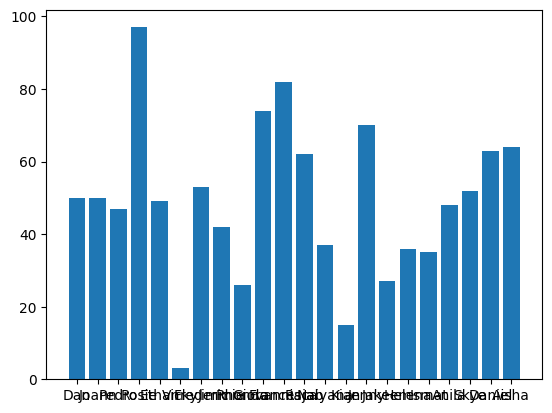

In [ ]:
# Ensure plots are displayed inline in the notebook
%matplotlib inline

from matplotlib import pyplot as plt

# Create a bar plot of name vs grade
plt.bar(x=df_students.Name, height=df_students.Grade)

# Display the plot
plt.show()

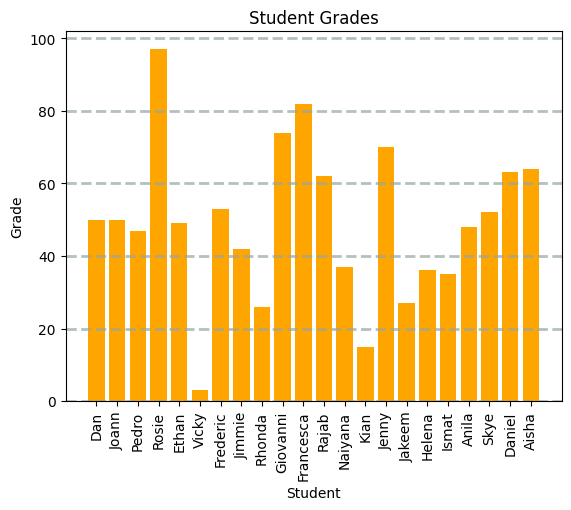

In [ ]:
# Create a bar plot of name vs grade
plt.bar(x=df_students.Name, height=df_students.Grade, color='orange')

# Customize the chart
plt.title('Student Grades')
plt.xlabel('Student')
plt.ylabel('Grade')
plt.grid(color='#95a5a6', linestyle='--', linewidth=2, axis='y', alpha=0.7)
plt.xticks(rotation=90)

# Display the plot
plt.show()

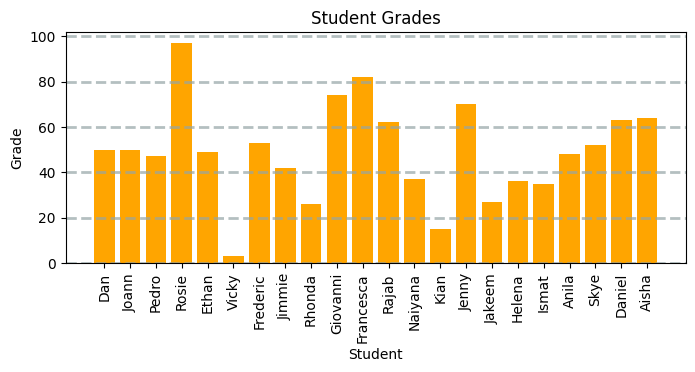

In [ ]:
# Create a Figure
fig = plt.figure(figsize=(8,3))

# Create a bar plot of name vs grade
plt.bar(x=df_students.Name, height=df_students.Grade, color='orange')

# Customize the chart
plt.title('Student Grades')
plt.xlabel('Student')
plt.ylabel('Grade')
plt.grid(color='#95a5a6', linestyle='--', linewidth=2, axis='y', alpha=0.7)
plt.xticks(rotation=90)

# Show the figure
plt.show()

/tmp/ipython-input-2786848323.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(df_students.Name, rotation=90)


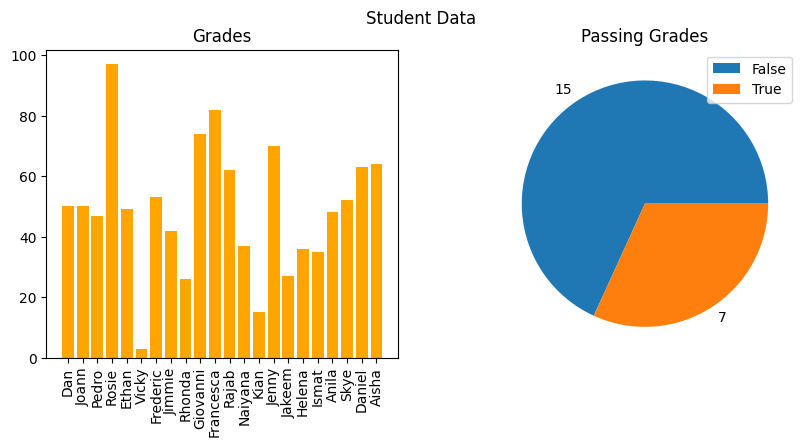

In [ ]:
# Create a figure for 2 subplots (1 row, 2 columns)
fig, ax = plt.subplots(1, 2, figsize = (10,4))

# Create a bar plot of name vs grade on the first axis
ax[0].bar(x=df_students.Name, height=df_students.Grade, color='orange')
ax[0].set_title('Grades')
ax[0].set_xticklabels(df_students.Name, rotation=90)

# Create a pie chart of pass counts on the second axis
pass_counts = df_students['Pass'].value_counts()
ax[1].pie(pass_counts, labels=pass_counts)
ax[1].set_title('Passing Grades')
ax[1].legend(pass_counts.keys().tolist())

# Add a title to the Figure
fig.suptitle('Student Data')

# Show the figure
fig.show()

<Axes: xlabel='Name'>

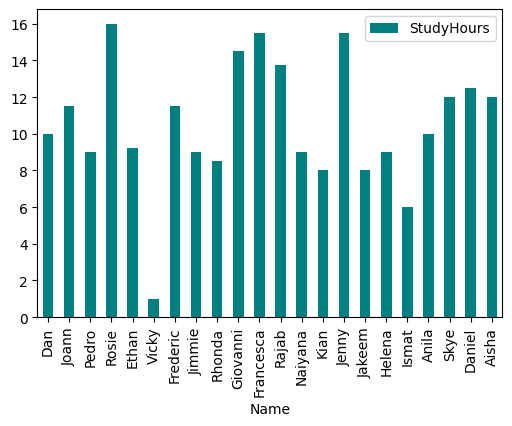

In [ ]:
df_students.plot.bar(x='Name', y='StudyHours', color='teal', figsize=(6,4))

#####Getting started with statistical analysis

######Getting started with statistical analysis

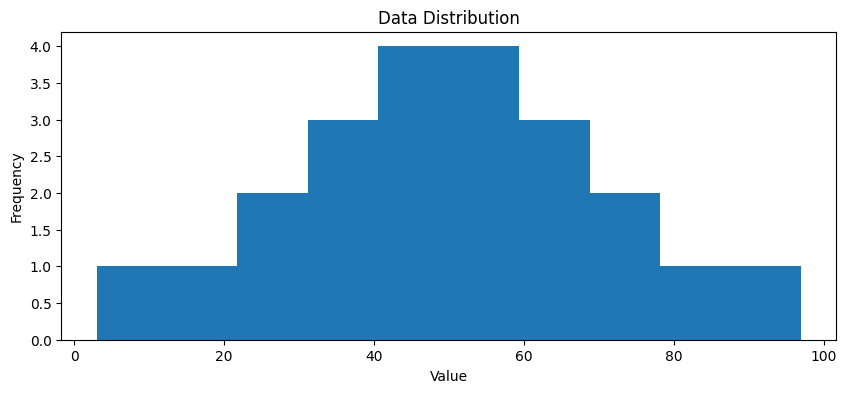

In [ ]:
# Get the variable to examine
var_data = df_students['Grade']

# Create a Figure
fig = plt.figure(figsize=(10,4))

# Plot a histogram
plt.hist(var_data)

# Add titles and labels
plt.title('Data Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Show the figure
fig.show()

######Measures of central tendency

Minimum:3.00
Mean:49.18
Median:49.50
Mode:50.00
Maximum:97.00



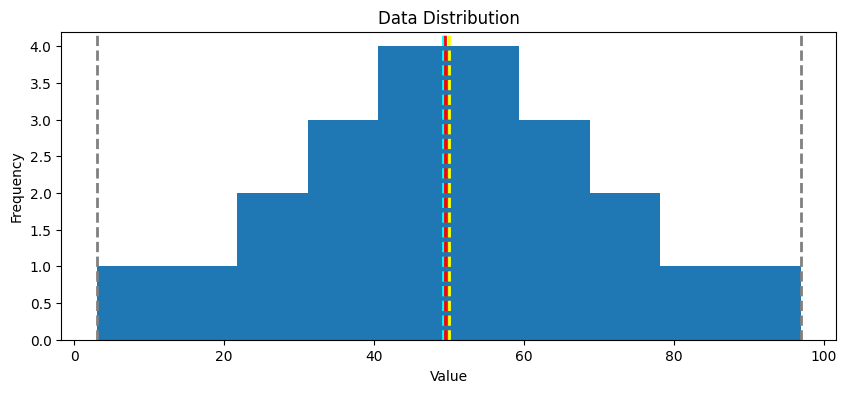

In [ ]:
# Get the variable to examine
var = df_students['Grade']

# Get statistics
min_val = var.min()
max_val = var.max()
mean_val = var.mean()
med_val = var.median()
mod_val = var.mode()[0]

print('Minimum:{:.2f}\nMean:{:.2f}\nMedian:{:.2f}\nMode:{:.2f}\nMaximum:{:.2f}\n'.format(min_val,
                                                                                        mean_val,
                                                                                        med_val,
                                                                                        mod_val,
                                                                                        max_val))

# Create a Figure
fig = plt.figure(figsize=(10,4))

# Plot a histogram
plt.hist(var)

# Add lines for the statistics
plt.axvline(x=min_val, color = 'gray', linestyle='dashed', linewidth = 2)
plt.axvline(x=mean_val, color = 'cyan', linestyle='dashed', linewidth = 2)
plt.axvline(x=med_val, color = 'red', linestyle='dashed', linewidth = 2)
plt.axvline(x=mod_val, color = 'yellow', linestyle='dashed', linewidth = 2)
plt.axvline(x=max_val, color = 'gray', linestyle='dashed', linewidth = 2)

# Add titles and labels
plt.title('Data Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Show the figure
fig.show()

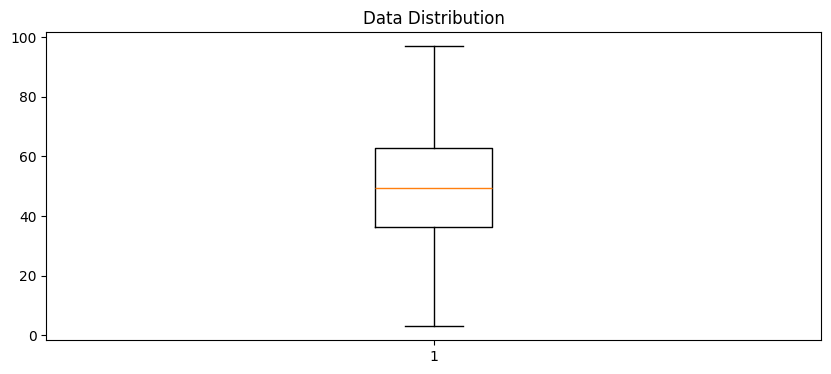

In [ ]:
# Get the variable to examine
var = df_students['Grade']

# Create a Figure
fig = plt.figure(figsize=(10,4))

# Plot a histogram
plt.boxplot(var)

# Add titles and labels
plt.title('Data Distribution')

# Show the figure
fig.show()

Minimum:3.00
Mean:49.18
Median:49.50
Mode:50.00
Maximum:97.00



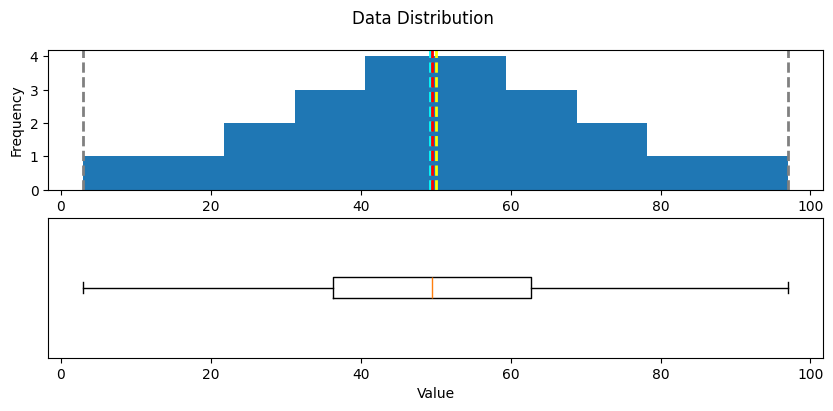

In [ ]:
# Create a function that we can re-use
def show_distribution(var_data):
    from matplotlib import pyplot as plt

    # Get statistics
    min_val = var_data.min()
    max_val = var_data.max()
    mean_val = var_data.mean()
    med_val = var_data.median()
    mod_val = var_data.mode()[0]

    print('Minimum:{:.2f}\nMean:{:.2f}\nMedian:{:.2f}\nMode:{:.2f}\nMaximum:{:.2f}\n'.format(min_val,
                                                                                            mean_val,
                                                                                            med_val,
                                                                                            mod_val,
                                                                                            max_val))

    # Create a figure for 2 subplots (2 rows, 1 column)
    fig, ax = plt.subplots(2, 1, figsize = (10,4))

    # Plot the histogram
    ax[0].hist(var_data)
    ax[0].set_ylabel('Frequency')

    # Add lines for the mean, median, and mode
    ax[0].axvline(x=min_val, color = 'gray', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=mean_val, color = 'cyan', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=med_val, color = 'red', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=mod_val, color = 'yellow', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=max_val, color = 'gray', linestyle='dashed', linewidth = 2)

    # Plot the boxplot
    ax[1].boxplot(var_data, vert=False)
    ax[1].set_xlabel('Value')
    ax[1].set_yticks([]) # Corrected method to remove y-axis ticks

    # Add a title to the Figure
    fig.suptitle('Data Distribution')

    # Show the figure
    fig.show()

# Get the variable to examine
col = df_students['Grade']
# Call the function
show_distribution(col)

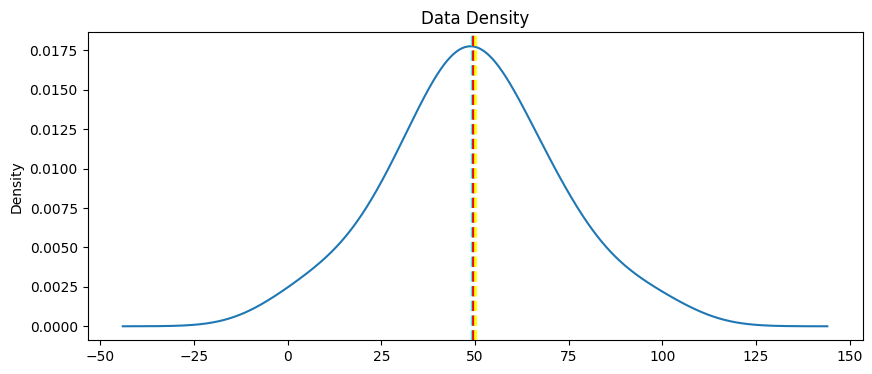

In [ ]:
def show_density(var_data):
    from matplotlib import pyplot as plt

    fig = plt.figure(figsize=(10,4))

    # Plot density
    var_data.plot.density()

    # Add titles and labels
    plt.title('Data Density')

    # Show the mean, median, and mode
    plt.axvline(x=var_data.mean(), color = 'cyan', linestyle='dashed', linewidth = 2)
    plt.axvline(x=var_data.median(), color = 'red', linestyle='dashed', linewidth = 2)
    plt.axvline(x=var_data.mode()[0], color = 'yellow', linestyle='dashed', linewidth = 2)

    # Show the figure
    plt.show()

# Get the density of Grade
col = df_students['Grade']
show_density(col)

#####Summary

Well done! There were a number of new concepts in here, so let's summarize.

Here, we:

1. Made graphs with Matplotlib.
2. Learned how to customize these graphs.
3. Calculated basic statistics, such as medians.
4. Looked at the spread of data using box plots and histograms.
5. Learned about samples versus populations.
6. Estimated what the population of grades might look like from a sample of grades.

In our next notebook, we'll look at spotting unusual data and finding relationships between data.

To learn more about the Python packages you explored in this notebook, see the following documentation:

- [NumPy](https://numpy.org/doc/stable/)
- [Pandas](https://pandas.pydata.org/pandas-docs/stable/)
- [Matplotlib](https://matplotlib.org/contents.html)

####Exercise - Examine real world data

#####Exploring data with Python - real world data distributions

--2025-08-08 00:28:15--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/ml-basics/grades.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 322 [text/plain]
Saving to: ‘grades.csv.2’

grades.csv.2        100%[===================>]     322  --.-KB/s    in 0s      

2025-08-08 00:28:15 (6.73 MB/s) - ‘grades.csv.2’ saved [322/322]

         Name  StudyHours  Grade   Pass
0         Dan       10.00   50.0  False
1       Joann       11.50   50.0  False
2       Pedro        9.00   47.0  False
3       Rosie       16.00   97.0   True
4       Ethan        9.25   49.0  False
5       Vicky        1.00    3.0  False
6    Frederic       11.50   53.0  False
7      Jimmie        9.00   42.0  False
8      Rhonda        8.5

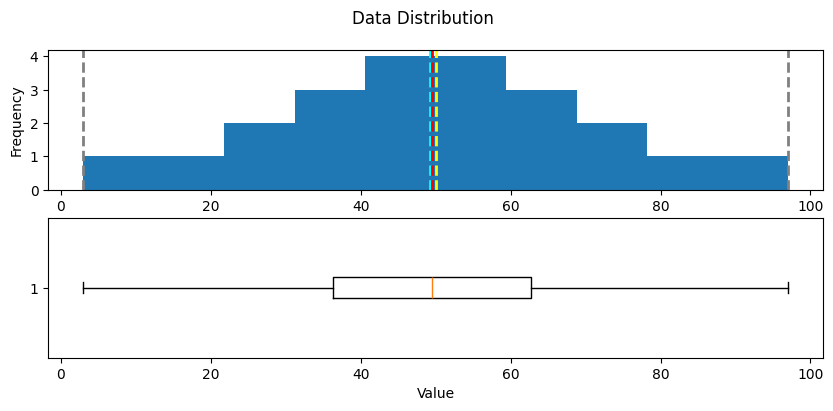

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

# Load data from a text file
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/ml-basics/grades.csv
df_students = pd.read_csv('grades.csv',delimiter=',',header='infer')

# Remove any rows with missing data
df_students = df_students.dropna(axis=0, how='any')

# Calculate who passed, assuming '60' is the grade needed to pass
passes  = pd.Series(df_students['Grade'] >= 60)

# Save who passed to the Pandas dataframe
df_students = pd.concat([df_students, passes.rename("Pass")], axis=1)


# Print the result out into this notebook
print(df_students)


# Create a function that we can re-use
def show_distribution(var_data):
    '''
    This function will make a distribution (graph) and display it
    '''

    # Get statistics
    min_val = var_data.min()
    max_val = var_data.max()
    mean_val = var_data.mean()
    med_val = var_data.median()
    mod_val = var_data.mode()[0]

    print('Minimum:{:.2f}\nMean:{:.2f}\nMedian:{:.2f}\nMode:{:.2f}\nMaximum:{:.2f}\n'.format(min_val,
                                                                                            mean_val,
                                                                                            med_val,
                                                                                            mod_val,
                                                                                            max_val))

    # Create a figure for 2 subplots (2 rows, 1 column)
    fig, ax = plt.subplots(2, 1, figsize = (10,4))

    # Plot the histogram
    ax[0].hist(var_data)
    ax[0].set_ylabel('Frequency')

    # Add lines for the mean, median, and mode
    ax[0].axvline(x=min_val, color = 'gray', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=mean_val, color = 'cyan', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=med_val, color = 'red', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=mod_val, color = 'yellow', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=max_val, color = 'gray', linestyle='dashed', linewidth = 2)

    # Plot the boxplot
    ax[1].boxplot(var_data, vert=False)
    ax[1].set_xlabel('Value')

    # Add a title to the Figure
    fig.suptitle('Data Distribution')

    # Show the figure
    fig.show()


show_distribution(df_students['Grade'])

Minimum:1.00
Mean:10.52
Median:10.00
Mode:9.00
Maximum:16.00



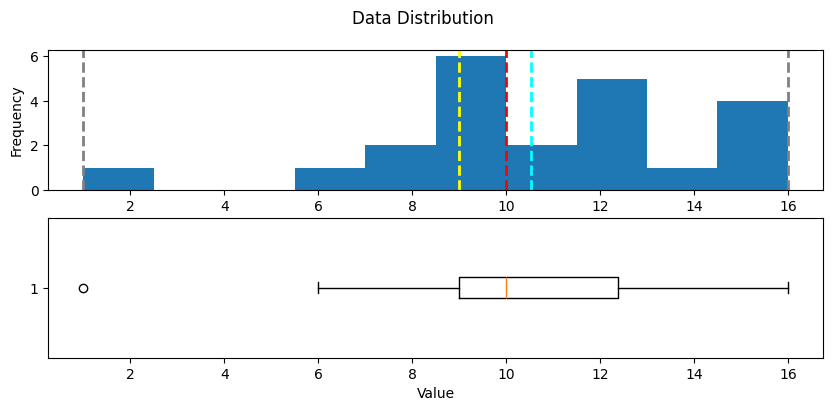

In [ ]:
# Get the variable to examine
col = df_students['StudyHours']
# Call the function
show_distribution(col)

Minimum:6.00
Mean:10.98
Median:10.00
Mode:9.00
Maximum:16.00



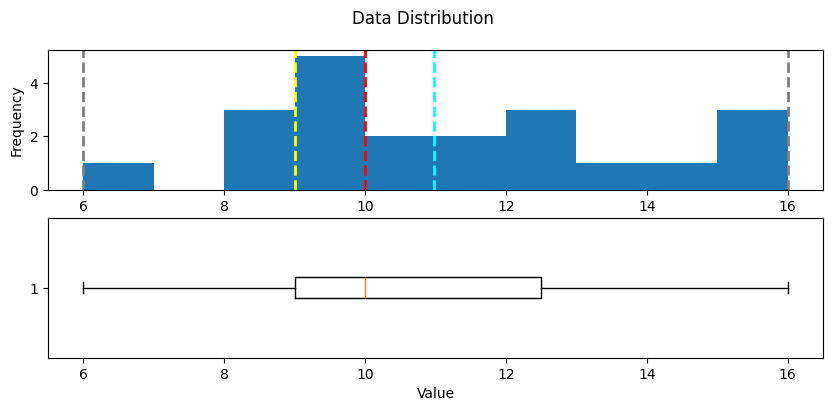

In [ ]:
# Get the variable to examine
# We will only get students who have studied more than one hour
col = df_students[df_students.StudyHours>1]['StudyHours']

# Call the function
show_distribution(col)

Minimum:6.00
Mean:10.98
Median:10.00
Mode:9.00
Maximum:16.00



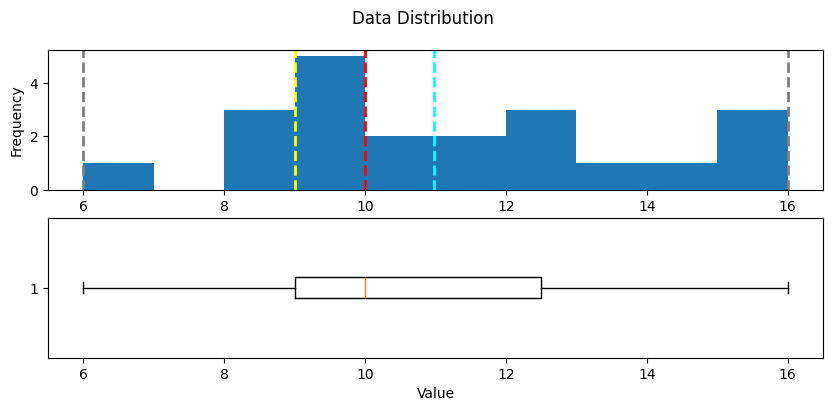

In [ ]:
# calculate the 0.01th percentile
q01 = df_students.StudyHours.quantile(0.01)
# Get the variable to examine
col = df_students[df_students.StudyHours>q01]['StudyHours']
# Call the function
show_distribution(col)

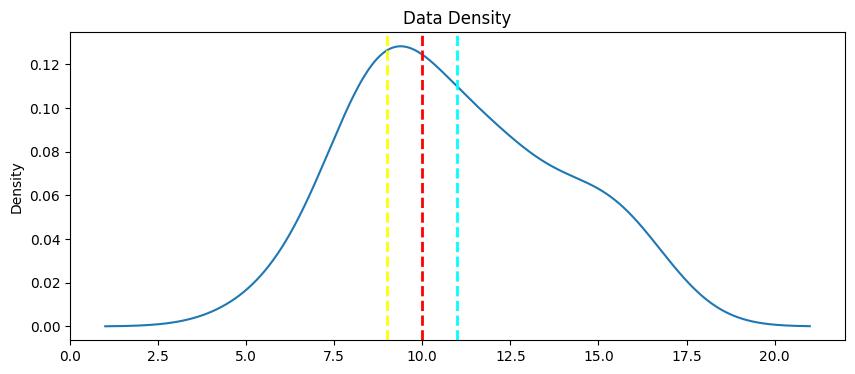

In [ ]:
def show_density(var_data):
    fig = plt.figure(figsize=(10,4))

    # Plot density
    var_data.plot.density()

    # Add titles and labels
    plt.title('Data Density')

    # Show the mean, median, and mode
    plt.axvline(x=var_data.mean(), color = 'cyan', linestyle='dashed', linewidth = 2)
    plt.axvline(x=var_data.median(), color = 'red', linestyle='dashed', linewidth = 2)
    plt.axvline(x=var_data.mode()[0], color = 'yellow', linestyle='dashed', linewidth = 2)

    # Show the figure
    plt.show()

# Get the density of StudyHours
show_density(col)

#####Measures of variance

In [ ]:
for col_name in ['Grade','StudyHours']:
    col = df_students[col_name]
    rng = col.max() - col.min()
    var = col.var()
    std = col.std()
    print('\n{}:\n - Range: {:.2f}\n - Variance: {:.2f}\n - Std.Dev: {:.2f}'.format(col_name, rng, var, std))


Grade:
 - Range: 94.00
 - Variance: 472.54
 - Std.Dev: 21.74

StudyHours:
 - Range: 15.00
 - Variance: 12.16
 - Std.Dev: 3.49


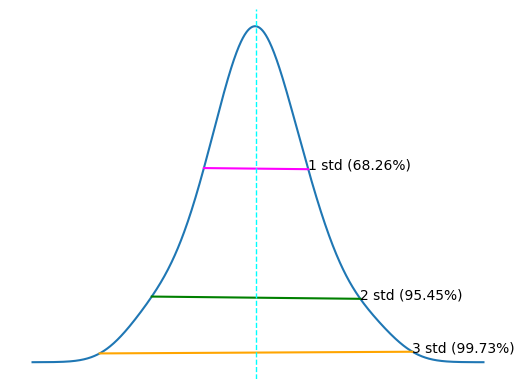

In [ ]:
import scipy.stats as stats

# Get the Grade column
col = df_students['Grade']

# get the density
density = stats.gaussian_kde(col)

# Plot the density
col.plot.density()

# Get the mean and standard deviation
s = col.std()
m = col.mean()

# Annotate 1 stdev
x1 = [m-s, m+s]
y1 = density(x1)
plt.plot(x1,y1, color='magenta')
plt.annotate('1 std (68.26%)', (x1[1],y1[1]))

# Annotate 2 stdevs
x2 = [m-(s*2), m+(s*2)]
y2 = density(x2)
plt.plot(x2,y2, color='green')
plt.annotate('2 std (95.45%)', (x2[1],y2[1]))

# Annotate 3 stdevs
x3 = [m-(s*3), m+(s*3)]
y3 = density(x3)
plt.plot(x3,y3, color='orange')
plt.annotate('3 std (99.73%)', (x3[1],y3[1]))

# Show the location of the mean
plt.axvline(col.mean(), color='cyan', linestyle='dashed', linewidth=1)

plt.axis('off')

plt.show()

In [ ]:
df_students.describe()

,StudyHours,Grade
count,22.000000,22.000000
mean,10.522727,49.181818
std,3.487144,21.737912
min,1.000000,3.000000
25%,9.000000,36.250000
50%,10.000000,49.500000
75%,12.375000,62.750000
max,16.000000,97.000000


#####Comparing data

In [ ]:
df_sample = df_students[df_students['StudyHours']>1]
df_sample

,Name,StudyHours,Grade,Pass
0,Dan,10.00,50.0,False
1,Joann,11.50,50.0,False
2,Pedro,9.00,47.0,False
3,Rosie,16.00,97.0,True
4,Ethan,9.25,49.0,False
6,Frederic,11.50,53.0,False
7,Jimmie,9.00,42.0,False
8,Rhonda,8.50,26.0,False
9,Giovanni,14.50,74.0,True
10,Francesca,15.50,82.0,True


######Comparing numeric and categorical variables

<Axes: title={'center': 'StudyHours'}, xlabel='Pass'>

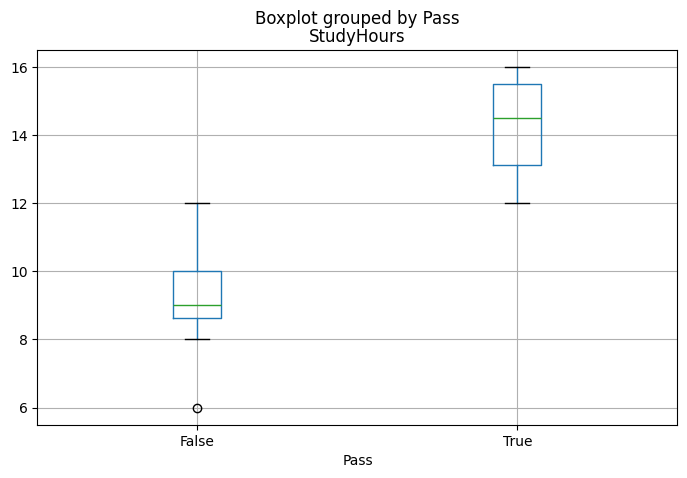

In [ ]:
df_sample.boxplot(column='StudyHours', by='Pass', figsize=(8,5))

######Comparing numeric variables

<Axes: xlabel='Name'>

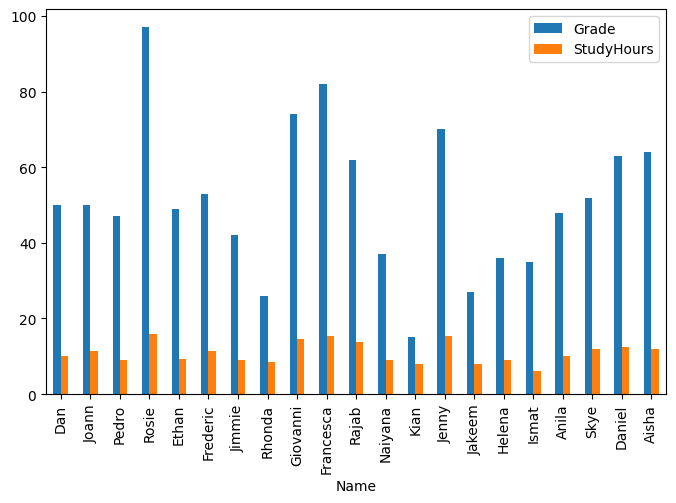

In [ ]:
# Create a bar plot of name vs grade and study hours
df_sample.plot(x='Name', y=['Grade','StudyHours'], kind='bar', figsize=(8,5))

<Axes: xlabel='Name'>

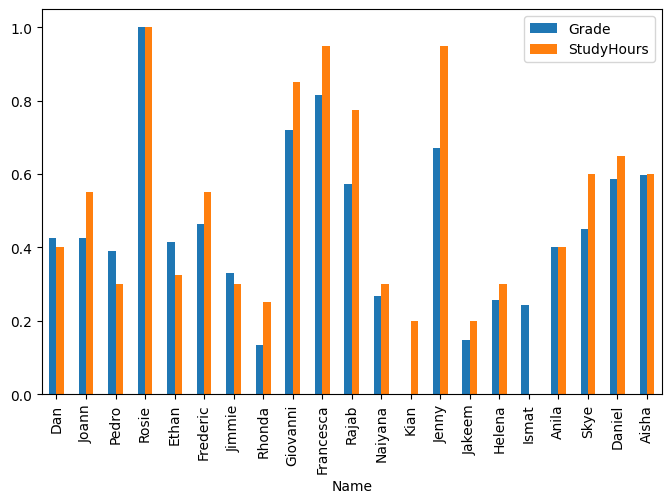

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Get a scaler object
scaler = MinMaxScaler()

# Create a new dataframe for the scaled values
df_normalized = df_sample[['Name', 'Grade', 'StudyHours']].copy()

# Normalize the numeric columns
df_normalized[['Grade','StudyHours']] = scaler.fit_transform(df_normalized[['Grade','StudyHours']])

# Plot the normalized values
df_normalized.plot(x='Name', y=['Grade','StudyHours'], kind='bar', figsize=(8,5))

In [ ]:
df_normalized.Grade.corr(df_normalized.StudyHours)

np.float64(0.9117666413789677)

<Axes: title={'center': 'Study Time vs Grade'}, xlabel='StudyHours', ylabel='Grade'>

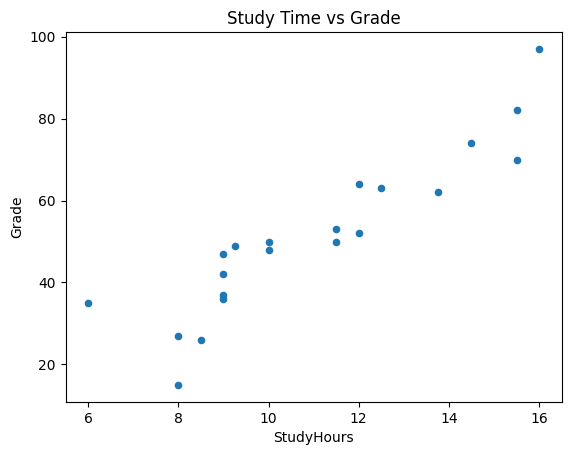

In [ ]:
# Create a scatter plot
df_sample.plot.scatter(title='Study Time vs Grade', x='StudyHours', y='Grade')

slope: 6.3134
y-intercept: -17.9164
so...
 f(x) = 6.3134x + -17.9164


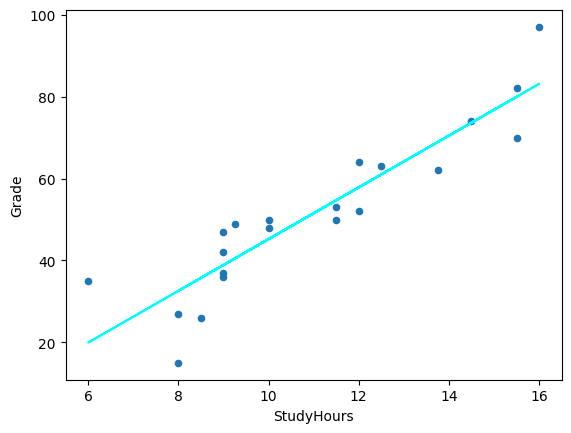

In [ ]:
from scipy import stats

#
df_regression = df_sample[['Grade', 'StudyHours']].copy()

# Get the regression slope and intercept
m, b, r, p, se = stats.linregress(df_regression['StudyHours'], df_regression['Grade'])
print('slope: {:.4f}\ny-intercept: {:.4f}'.format(m,b))
print('so...\n f(x) = {:.4f}x + {:.4f}'.format(m,b))

# Use the function (mx + b) to calculate f(x) for each x (StudyHours) value
df_regression['fx'] = (m * df_regression['StudyHours']) + b

# Calculate the error between f(x) and the actual y (Grade) value
df_regression['error'] = df_regression['fx'] - df_regression['Grade']

# Create a scatter plot of Grade vs StudyHours
df_regression.plot.scatter(x='StudyHours', y='Grade')

# Plot the regression line
plt.plot(df_regression['StudyHours'],df_regression['fx'], color='cyan')

# Display the plot
plt.show()

In [ ]:
# Show the original x,y values, the f(x) value, and the error
df_regression[['StudyHours', 'Grade', 'fx', 'error']]

,StudyHours,Grade,fx,error
0,10.00,50.0,45.217846,-4.782154
1,11.50,50.0,54.687985,4.687985
2,9.00,47.0,38.904421,-8.095579
3,16.00,97.0,83.098400,-13.901600
4,9.25,49.0,40.482777,-8.517223
6,11.50,53.0,54.687985,1.687985
7,9.00,42.0,38.904421,-3.095579
8,8.50,26.0,35.747708,9.747708
9,14.50,74.0,73.628262,-0.371738
10,15.50,82.0,79.941687,-2.058313


#####Using the regression coefficients for prediction

In [ ]:
# Define a function based on our regression coefficients
def f(x):
    m = 6.3134
    b = -17.9164
    return m*x + b

study_time = 14

# Get f(x) for study time
prediction = f(study_time)

# Grade can't be less than 0 or more than 100
expected_grade = max(0,min(100,prediction))

#Print the estimated grade
print ('Studying for {} hours per week may result in a grade of {:.0f}'.format(study_time, expected_grade))

Studying for 14 hours per week may result in a grade of 70


#####Summary

Here we've looked at:

1. What an outlier is and how to remove them
2. How data can be skewed
3. How to look at the spread of data
4. Basic ways to compare variables, such as grades and study time

####Summary

In this module, you learned how to use Python to explore, visualize, and manipulate data. Data exploration is at the core of data science and is a key element in data analysis and machine learning.

Machine learning is a subset of data science that deals with predictive modeling. In other words, machine learning uses data to create predictive models in order to predict unknown values. You might use machine learning to predict how much food a supermarket needs to order or to identify plants in photographs.

Machine learning works by identifying relationships between data values that describe the characteristics of something (its features, such as the height and color of a plant) and the value we want to predict (the label, such as the species of plant). These relationships are built into a model through a training process.

####[EDA Hands on](https://github.com/TrippleA001/DSN-30-days-of-learning-2025/blob/Personal/Machine%20Learning%20with%20Python%20and%20%20Azure/01_Flights_Challenge.ipynb)

###Train and understand regression models in machine learning

####Learning objectives

####Exercise: Train a simple linear regression model

#####Loading data

In [ ]:
import pandas
!pip install statsmodels
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/graphing.py
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/doggy-illness.csv

# Convert it into a table using pandas
dataset = pandas.read_csv("doggy-illness.csv", delimiter="\t")

# Print the data
print(dataset)

--2025-08-08 07:49:36--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/graphing.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21511 (21K) [text/plain]
Saving to: ‘graphing.py’

graphing.py         100%[===================>]  21.01K  --.-KB/s    in 0.002s  

2025-08-08 07:49:36 (9.98 MB/s) - ‘graphing.py’ saved [21511/21511]

--2025-08-08 07:49:36--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/doggy-illness.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, aw

#####Data visualization

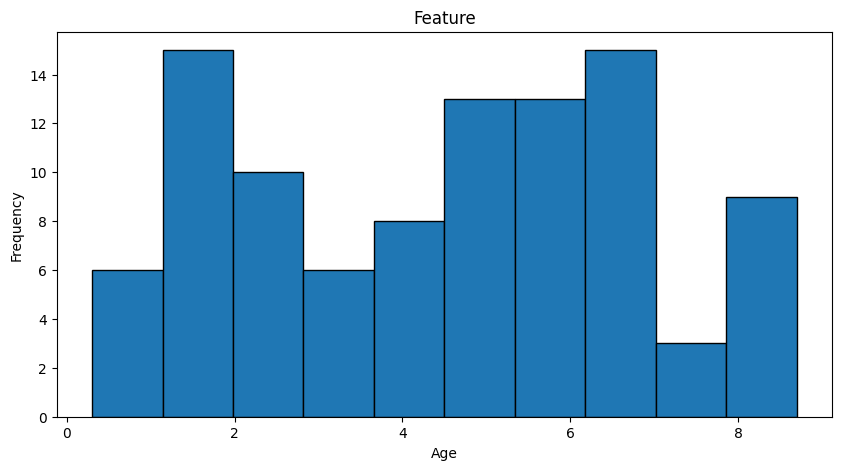

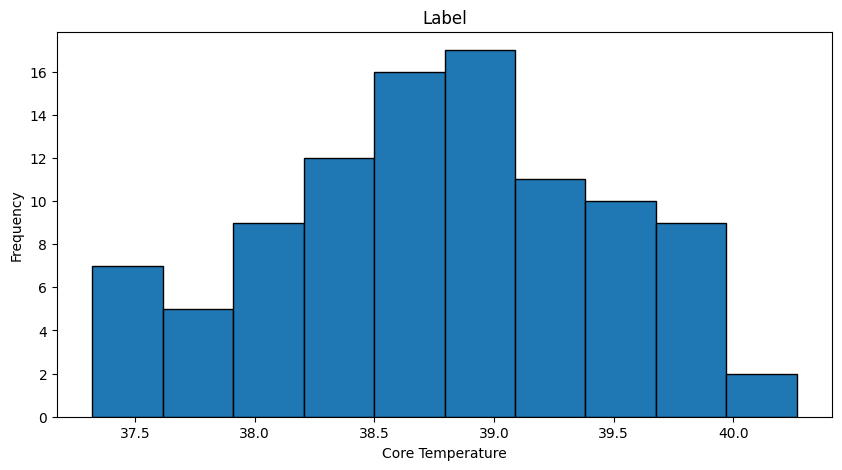

In [ ]:
import matplotlib.pyplot as plt

# Histogram for 'age'
plt.figure(figsize=(10, 5))
plt.hist(dataset['age'], bins=10, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Feature')
plt.show()

# Histogram for 'core_temperature'
plt.figure(figsize=(10, 5))
plt.hist(dataset['core_temperature'], bins=10, edgecolor='black')
plt.xlabel('Core Temperature')
plt.ylabel('Frequency')
plt.title('Label')
plt.show()

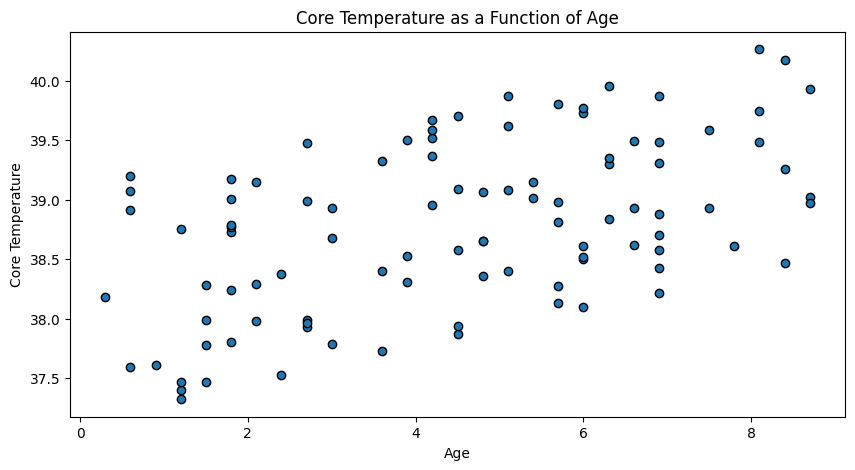

In [ ]:
import matplotlib.pyplot as plt

# Scatter plot for 'age' vs 'core_temperature'
plt.figure(figsize=(10, 5))
plt.scatter(dataset['age'], dataset['core_temperature'], edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Core Temperature')
plt.title('Core Temperature as a Function of Age')
plt.show()

#####Simple linear regression

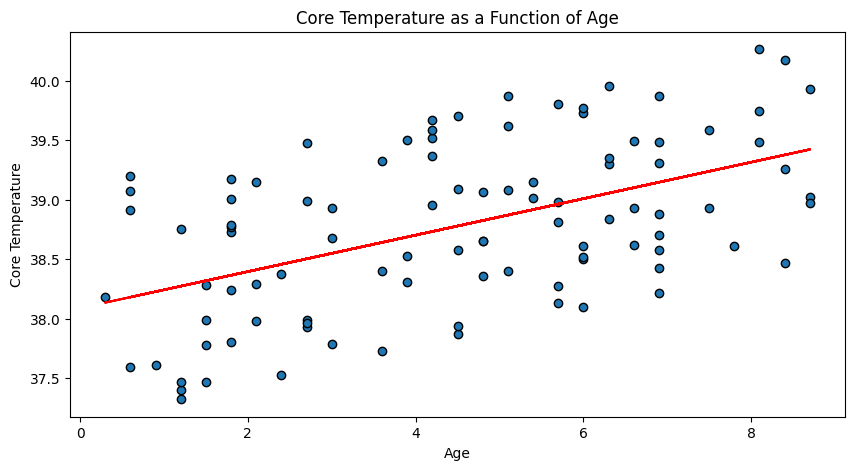

In [ ]:
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# First, we define our formula using a special syntax
# This says that core temperature is explained by age
formula = "core_temperature ~ age"

# Perform linear regression. This method takes care of
# the entire fitting procedure for us.
model = smf.ols(formula = formula, data = dataset).fit()

# Show a graph of the result
plt.figure(figsize=(10, 5))
plt.scatter(dataset['age'], dataset['core_temperature'], edgecolor='black')
plt.plot(dataset['age'], model.params.iloc[1] * dataset['age'] + model.params.iloc[0], color='red')
# plt.plot(dataset['age'], model.predict(dataset['age']), color='red') # Alternative
plt.xlabel('Age')
plt.ylabel('Core Temperature')
plt.title('Core Temperature as a Function of Age')
plt.show()

#####Interpreting our model

In [ ]:
print("Intercept:", model.params.iloc[0], "Slope:", model.params.iloc[1])

Intercept: 38.087867548892085 Slope: 0.15333957754731864


In [ ]:
def estimate_temperature(age):
    # Model param[0] is the intercepts and param[1] is the slope
    return model.params.iloc[0] + model.params.iloc[1] * age

print("Estimate temperature from age")
print(estimate_temperature(age=5))

Estimate temperature from age
38.854565436628675


#####Summary

We covered the following concepts in this exercise:

- Quickly visualizing a dataset
- Qualitatively assessing a linear relationship
- Building a simple linear-regression model
- Understanding parameters of a simple linear-regression model

####Exercise: Train a multiple linear regression model

#####Loading data

In [ ]:
import pandas
!pip install statsmodels
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/graphing.py
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/doggy-illness.csv

#Import the data from the .csv file
dataset = pandas.read_csv('doggy-illness.csv', delimiter="\t")

#Let's have a look at the data
dataset

ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/operations/check.py", line 101, in check_install_conflicts
    package_set, _ = create_package_

,male,attended_training,age,body_fat_percentage,core_temperature,ate_at_tonys_steakhouse,needed_intensive_care,protein_content_of_last_meal
0,0,1,6.9,38,38.423169,0,0,7.66
1,0,1,5.4,32,39.015998,0,0,13.36
2,1,1,5.4,12,39.148341,0,0,12.90
3,1,0,4.8,23,39.060049,0,0,13.45
4,1,0,4.8,15,38.655439,0,0,10.53
...,...,...,...,...,...,...,...,...
93,0,0,4.5,38,37.939942,0,0,7.35
94,1,0,1.8,11,38.790426,1,1,12.18
95,0,0,6.6,20,39.489962,0,0,15.84
96,0,0,6.9,32,38.575742,1,1,9.79


#####Data visualization

<Figure size 800x500 with 0 Axes>

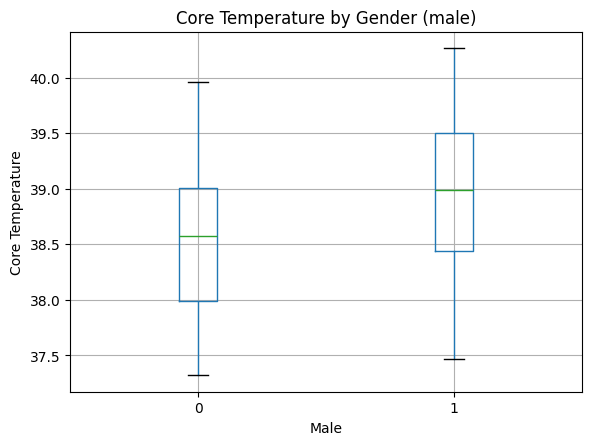

<Figure size 800x500 with 0 Axes>

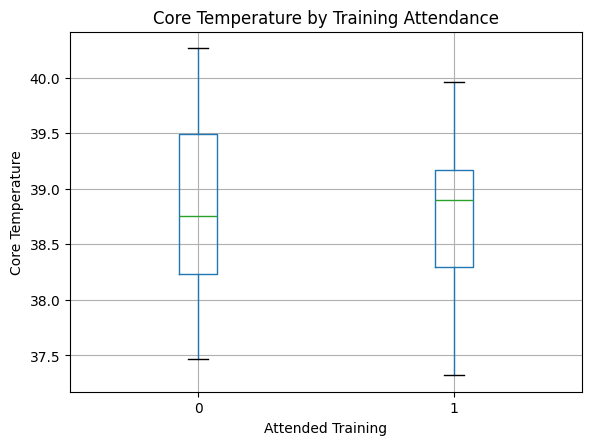

<Figure size 800x500 with 0 Axes>

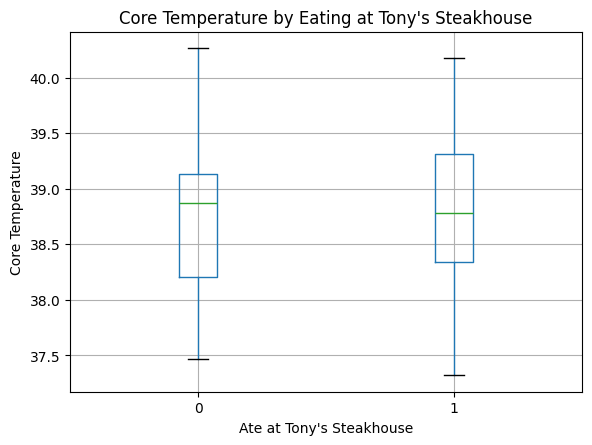

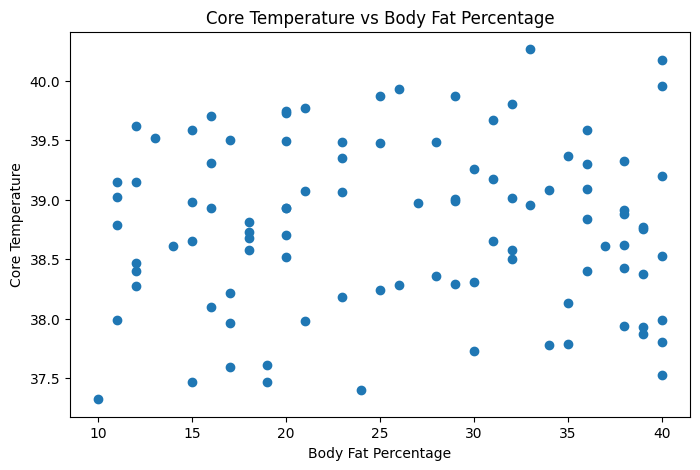

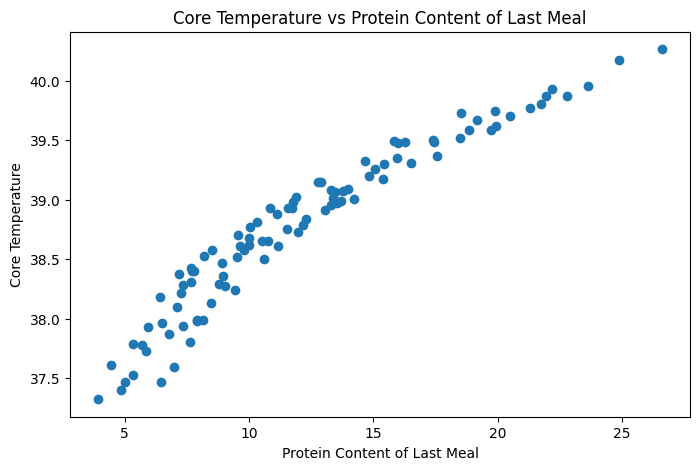

Text(0, 0.5, 'Core Temperature')

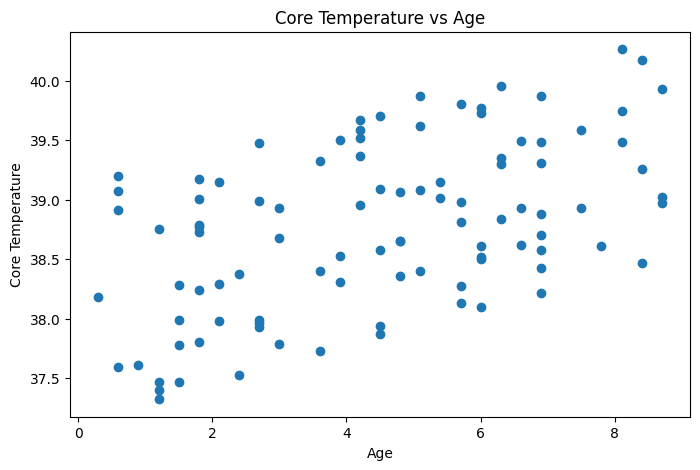

In [ ]:
import matplotlib.pyplot as plt

# Box and whisker plots
plt.figure(figsize=(8, 5))
dataset.boxplot(column="core_temperature", by="male")
plt.title("Core Temperature by Gender (male)")
plt.suptitle("")
plt.xlabel("Male")
plt.ylabel("Core Temperature")
plt.show()

plt.figure(figsize=(8, 5))
dataset.boxplot(column="core_temperature", by="attended_training")
plt.title("Core Temperature by Training Attendance")
plt.suptitle("")
plt.xlabel("Attended Training")
plt.ylabel("Core Temperature")
plt.show()

plt.figure(figsize=(8, 5))
dataset.boxplot(column="core_temperature", by="ate_at_tonys_steakhouse")
plt.title("Core Temperature by Eating at Tony's Steakhouse")
plt.suptitle("")
plt.xlabel("Ate at Tony's Steakhouse")
plt.ylabel("Core Temperature")
plt.show()

# Scatter plots
plt.figure(figsize=(8, 5))
plt.scatter(dataset["body_fat_percentage"], dataset["core_temperature"])
plt.title("Core Temperature vs Body Fat Percentage")
plt.xlabel("Body Fat Percentage")
plt.ylabel("Core Temperature")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(dataset["protein_content_of_last_meal"], dataset["core_temperature"])
plt.title("Core Temperature vs Protein Content of Last Meal")
plt.xlabel("Protein Content of Last Meal")
plt.ylabel("Core Temperature")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(dataset["age"], dataset["core_temperature"])
plt.title("Core Temperature vs Age")
plt.xlabel("Age")
plt.ylabel("Core Temperature")

#####Simple linear regression

male
R-squared: 0.0999007443071992


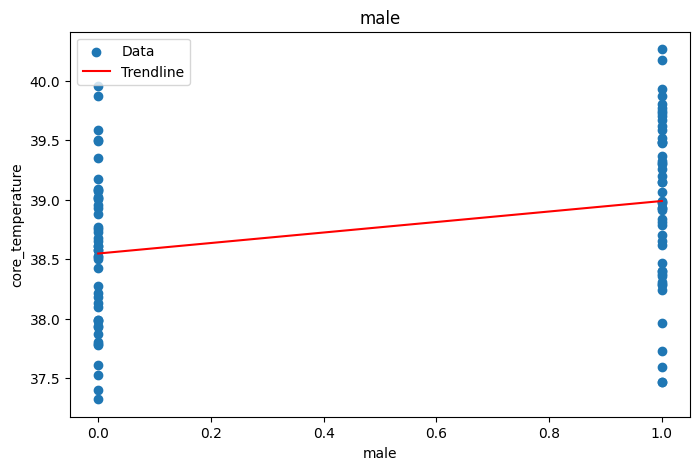

age
R-squared: 0.2648116081342463


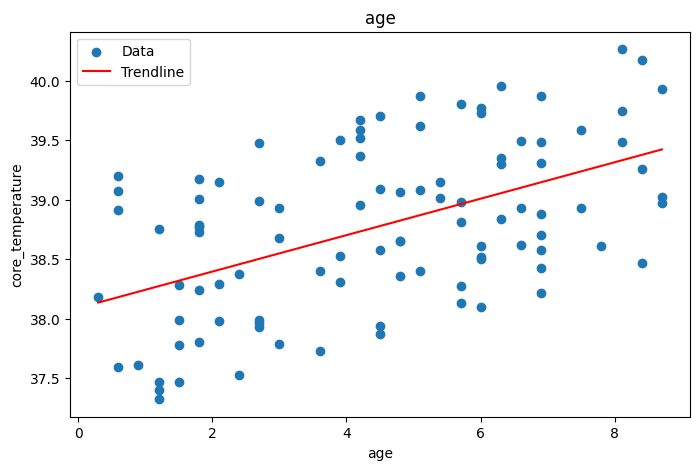

protein_content_of_last_meal
R-squared: 0.9155158150005704


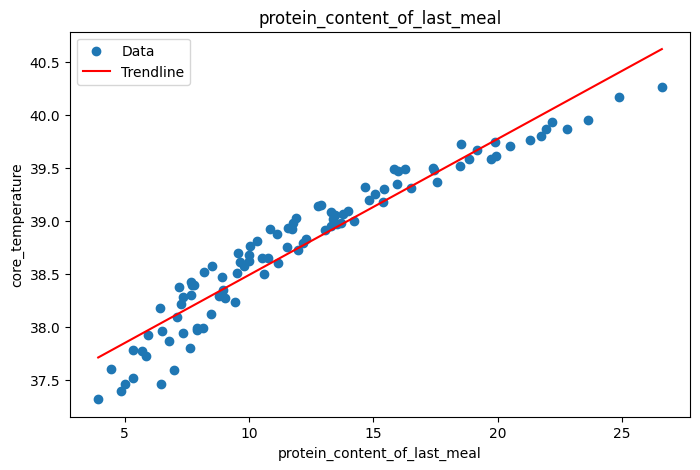

body_fat_percentage
R-squared: 0.00020809002637767193


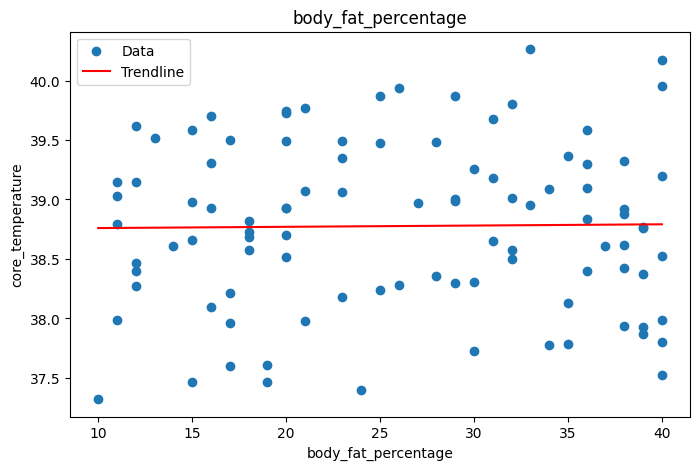

In [ ]:
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import numpy as np

for feature in ["male", "age", "protein_content_of_last_meal", "body_fat_percentage"]:
    # Perform linear regression
    formula = "core_temperature ~ " + feature
    simple_model = smf.ols(formula=formula, data=dataset).fit()

    print(feature)
    print("R-squared:", simple_model.rsquared)

    # Scatter plot with trendline
    plt.figure(figsize=(8, 5))
    plt.scatter(dataset[feature], dataset["core_temperature"], label="Data")

    # Generate trendline values
    x_vals = np.linspace(dataset[feature].min(), dataset[feature].max(), 100)
    y_vals = simple_model.params.iloc[1] * x_vals + simple_model.params.iloc[0]
    plt.plot(x_vals, y_vals, color="red", label="Trendline")

    plt.xlabel(feature)
    plt.ylabel("core_temperature")
    plt.title(feature)
    plt.legend()
    plt.show()

#####R-Squared

/tmp/ipython-input-2008853290.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  age_naive_model.params.iloc[0] = dataset['core_temperature'].mean()
/tmp/ipython-input-2008853290.py:8: FutureWarning: ChainedAssignmentError: behaviour will c

naive R-squared: 0.0
trained R-squared: 0.2648116081342463


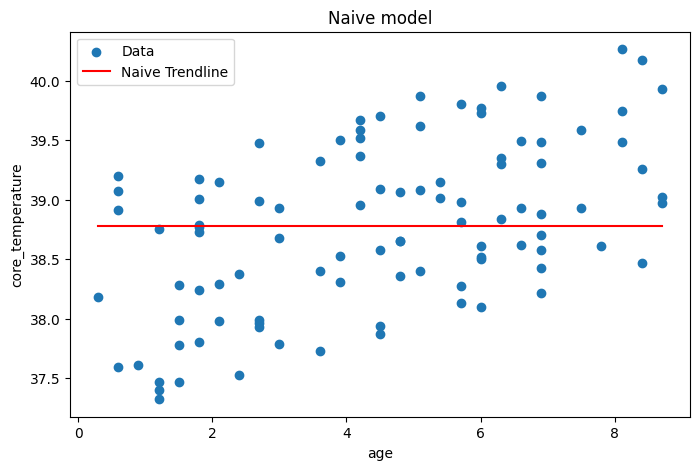

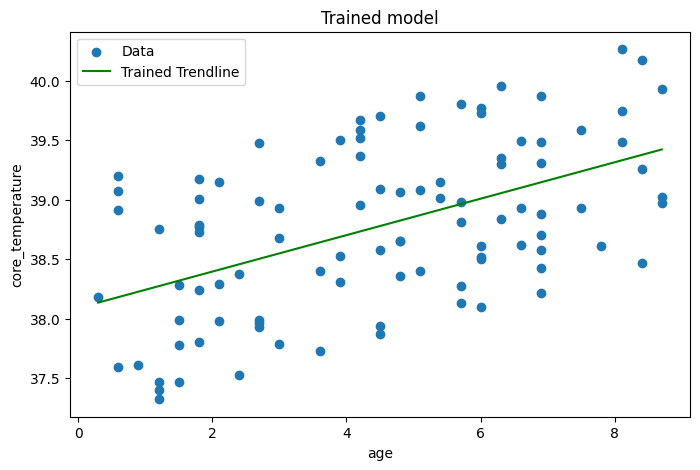

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

formula = "core_temperature ~ age"
age_trained_model = smf.ols(formula = formula, data = dataset).fit()
age_naive_model = smf.ols(formula = formula, data = dataset).fit()
age_naive_model.params.iloc[0] = dataset['core_temperature'].mean()
age_naive_model.params.iloc[1] = 0

print("naive R-squared:", age_naive_model.rsquared)
print("trained R-squared:", age_trained_model.rsquared)

# Naive model plot
plt.figure(figsize=(8, 5))
plt.scatter(dataset["age"], dataset["core_temperature"], label="Data")

# Naive trendline: horizontal line at the mean
mean_temp = dataset["core_temperature"].mean()
plt.plot(
    [dataset["age"].min(), dataset["age"].max()],
    [mean_temp, mean_temp],
    color="red",
    label="Naive Trendline"
)

plt.xlabel("age")
plt.ylabel("core_temperature")
plt.title("Naive model")
plt.legend()
plt.show()

# Trained model plot
plt.figure(figsize=(8, 5))
plt.scatter(dataset["age"], dataset["core_temperature"], label="Data")

# Trained trendline
x_vals = np.linspace(dataset["age"].min(), dataset["age"].max(), 100)
y_vals = age_trained_model.params.iloc[1] * x_vals + age_trained_model.params.iloc[0]
plt.plot(x_vals, y_vals, color="green", label="Trained Trendline")

plt.xlabel("age")
plt.ylabel("core_temperature")
plt.title("Trained model")
plt.legend()
plt.show()

#####Multiple Linear Regression

In [ ]:
model = smf.ols(formula = "core_temperature ~ age + male", data = dataset).fit()

print("R-squared:", model.rsquared)

R-squared: 0.3148512699768006


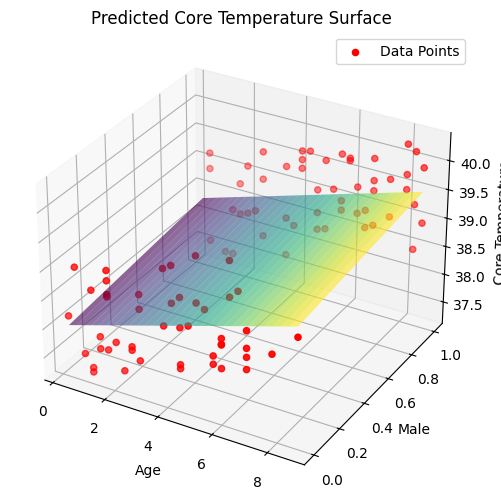

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the prediction function
def predict(age, male):
    df = pd.DataFrame(dict(age=age.ravel(), male=male.ravel()))
    return model.predict(df).values.reshape(age.shape)

# Create a meshgrid over the age and male feature ranges
age_range = np.linspace(dataset.age.min(), dataset.age.max(), 30)
male_range = np.array([0, 1])  # since male is binary

age_grid, male_grid = np.meshgrid(age_range, male_range)
z_vals = predict(age_grid, male_grid)

# Create the 3D plot
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(age_grid, male_grid, z_vals, alpha=0.6, cmap='viridis', edgecolor='none')

# Scatter plot of actual data points
ax.scatter(dataset.age, dataset.male, dataset.core_temperature, color='red', label='Data Points')

ax.set_xlabel("Age")
ax.set_ylabel("Male")
ax.set_zlabel("Core Temperature")
ax.set_title("Predicted Core Temperature Surface")

plt.legend()
plt.show()

#####Inspecting our model

In [ ]:
# Print summary information
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       core_temperature   R-squared:                       0.315
Model:                            OLS   Adj. R-squared:                  0.300
Method:                 Least Squares   F-statistic:                     21.83
Date:                Fri, 08 Aug 2025   Prob (F-statistic):           1.58e-08
Time:                        12:15:50   Log-Likelihood:                -85.295
No. Observations:                  98   AIC:                             176.6
Df Residuals:                      95   BIC:                             184.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     37.9793      0.135    282.094      0.000      37.712      38.247
age            0.1406      0.026      5.459      0.000       0.089       0.192
male           0.3182      0.121      2.634      0.010       0.078       0.558
==============================================================================
Omnibus:                       21.610   Durbin-Watson:                   2.369
Prob(Omnibus):                  0.000   Jarque-Bera (JB):                5.227
Skew:                           0.121   Prob(JB):                       0.0733
Kurtosis:                       1.895   Cond. No.                         12.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
age_trained_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       core_temperature   R-squared:                       0.265
Model:                            OLS   Adj. R-squared:                  0.257
Method:                 Least Squares   F-statistic:                     34.58
Date:                Fri, 08 Aug 2025   Prob (F-statistic):           5.94e-08
Time:                        12:15:50   Log-Likelihood:                -88.749
No. Observations:                  98   AIC:                             181.5
Df Residuals:                      96   BIC:                             186.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     38.0879      0.132    288.373      0.000      37.826      38.350
age            0.1533      0.026      5.880      0.000       0.102       0.205
==============================================================================
Omnibus:                       43.487   Durbin-Watson:                   2.492
Prob(Omnibus):                  0.000   Jarque-Bera (JB):                6.605
Skew:                           0.087   Prob(JB):                       0.0368
Kurtosis:                       1.740   Cond. No.                         11.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#####Summary

We covered the following concepts in this exercise:

- Built simple and multiple linear-regression models.
- Compared the performance of both models by looking at R-Squared values.
- Inspected models to understand how they work.

####Exercise: Fitting a Polynomial Curve


#####Data Loading

In [ ]:
import pandas
!pip install statsmodels
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/graphing.py
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/doggy-illness.csv

#Import the data from the .csv file
dataset = pandas.read_csv('doggy-illness.csv', delimiter="\t")

#Let's have a look at the data
dataset

--2025-08-08 11:57:18--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/graphing.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21511 (21K) [text/plain]
Saving to: ‘graphing.py.1’

graphing.py.1       100%[===================>]  21.01K  --.-KB/s    in 0.002s  

2025-08-08 11:57:18 (13.1 MB/s) - ‘graphing.py.1’ saved [21511/21511]

--2025-08-08 11:57:18--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/doggy-illness.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent

,male,attended_training,age,body_fat_percentage,core_temperature,ate_at_tonys_steakhouse,needed_intensive_care,protein_content_of_last_meal
0,0,1,6.9,38,38.423169,0,0,7.66
1,0,1,5.4,32,39.015998,0,0,13.36
2,1,1,5.4,12,39.148341,0,0,12.90
3,1,0,4.8,23,39.060049,0,0,13.45
4,1,0,4.8,15,38.655439,0,0,10.53
...,...,...,...,...,...,...,...,...
93,0,0,4.5,38,37.939942,0,0,7.35
94,1,0,1.8,11,38.790426,1,1,12.18
95,0,0,6.6,20,39.489962,0,0,15.84
96,0,0,6.9,32,38.575742,1,1,9.79


#####Simple Linear Regression

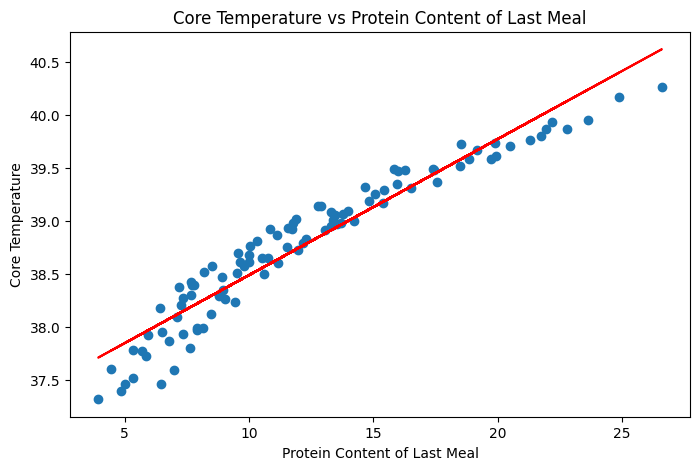

In [ ]:
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# Perform linear regression. This method takes care of
# the entire fitting procedure for us.
simple_formula = "core_temperature ~ protein_content_of_last_meal"
simple_model = smf.ols(formula = simple_formula, data = dataset).fit()

# Show a graph of the result
plt.figure(figsize=(8, 5))
plt.scatter(dataset["protein_content_of_last_meal"], dataset["core_temperature"])
plt.plot(dataset["protein_content_of_last_meal"], simple_model.params.iloc[1] * dataset["protein_content_of_last_meal"] + simple_model.params.iloc[0], color='red')
plt.title("Core Temperature vs Protein Content of Last Meal")
plt.xlabel("Protein Content of Last Meal")
plt.ylabel("Core Temperature")
plt.show()

In [ ]:
print("R-squared:", simple_model.rsquared)

R-squared: 0.9155158150005704


#####Simple Polynomial Regression

/tmp/ipython-input-991338039.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_vals = (polynomial_model.params[2] * x_vals**2 +
/tmp/ipython-input-991338039.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  polynomial_model.params[1] * x_vals +
/tmp/ipython-input-991338039.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  polynomial_model.params[0])


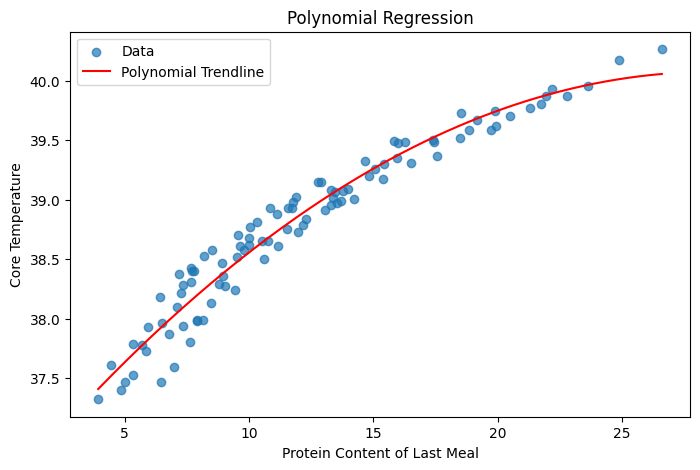

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Perform polynomial regression
polynomial_formula = "core_temperature ~ protein_content_of_last_meal + I(protein_content_of_last_meal**2)"
polynomial_model = smf.ols(formula=polynomial_formula, data=dataset).fit()

# Scatter plot of the data
plt.figure(figsize=(8, 5))
plt.scatter(dataset["protein_content_of_last_meal"], dataset["core_temperature"], label="Data", alpha=0.7)

# Generate smooth x values for the trendline
x_vals = np.linspace(dataset["protein_content_of_last_meal"].min(), dataset["protein_content_of_last_meal"].max(), 200)

# Calculate predicted y values using the polynomial coefficients
y_vals = (polynomial_model.params[2] * x_vals**2 +
          polynomial_model.params[1] * x_vals +
          polynomial_model.params[0])

# Plot the trendline
plt.plot(x_vals, y_vals, color="red", label="Polynomial Trendline")

# Label axes and show plot
plt.xlabel("Protein Content of Last Meal")
plt.ylabel("Core Temperature")
plt.title("Polynomial Regression")
plt.legend()
plt.show()

In [ ]:
print("R-squared:", polynomial_model.rsquared)

R-squared: 0.9514426069911688


/tmp/ipython-input-480228164.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  z_vals = (polynomial_model.params[0]
/tmp/ipython-input-480228164.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  + polynomial_model.params[1] * x_grid
/tmp/ipython-input-480228164.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  + polynomial_model.params[2] * x2_grid)


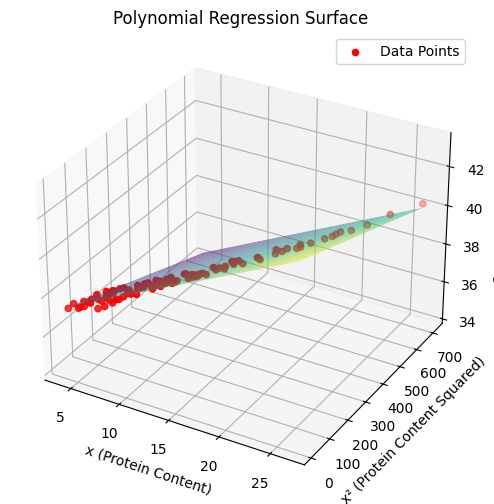

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a grid of x and x² values
x_vals = np.linspace(dataset.protein_content_of_last_meal.min(),
                     dataset.protein_content_of_last_meal.max(), 50)
x2_vals = x_vals**2
x_grid, x2_grid = np.meshgrid(x_vals, x2_vals)

# Compute z using the polynomial model's parameters
z_vals = (polynomial_model.params[0]
          + polynomial_model.params[1] * x_grid
          + polynomial_model.params[2] * x2_grid)

# Create the 3D plot
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(x_grid, x2_grid, z_vals, alpha=0.6, cmap="viridis", edgecolor="none")

# Add the original data points
ax.scatter(dataset.protein_content_of_last_meal,
           dataset.protein_content_of_last_meal**2,
           dataset.core_temperature,
           color="red", label="Data Points")

# Axis labels and title
ax.set_xlabel("x (Protein Content)")
ax.set_ylabel("x² (Protein Content Squared)")
ax.set_zlabel("Core Temperature")
ax.set_title("Polynomial Regression Surface")

plt.legend()
plt.show()

#####Extrapolating

/tmp/ipython-input-1731119894.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_vals = simple_model.params[1] * x_vals + simple_model.params[0]


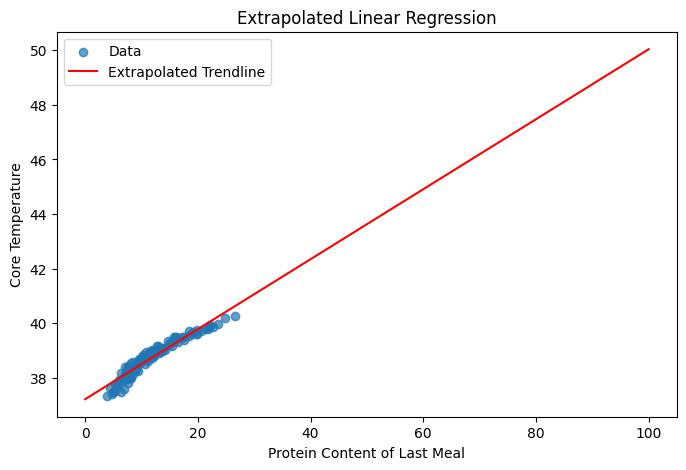

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Scatter plot of the actual data
plt.figure(figsize=(8, 5))
plt.scatter(dataset["protein_content_of_last_meal"], dataset["core_temperature"], label="Data", alpha=0.7)

# Define extrapolation range
x_vals = np.linspace(0, 100, 200)

# Calculate the trendline using the simple linear model
y_vals = simple_model.params[1] * x_vals + simple_model.params[0]

# Plot the extrapolated trendline
plt.plot(x_vals, y_vals, color="red", label="Extrapolated Trendline")

# Label axes and add title/legend
plt.xlabel("Protein Content of Last Meal")
plt.ylabel("Core Temperature")
plt.title("Extrapolated Linear Regression")
plt.legend()
plt.show()

/tmp/ipython-input-3757940325.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_vals = (polynomial_model.params[2] * x_vals**2 +
/tmp/ipython-input-3757940325.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  polynomial_model.params[1] * x_vals +
/tmp/ipython-input-3757940325.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  polynomial_model.params[0])


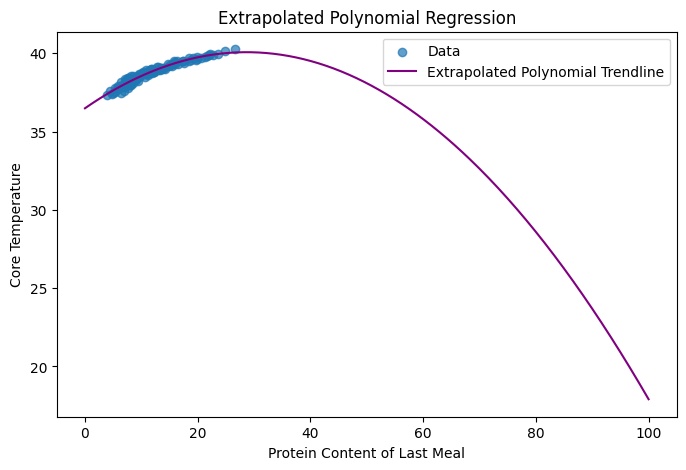

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Scatter plot of the actual data
plt.figure(figsize=(8, 5))
plt.scatter(dataset["protein_content_of_last_meal"], dataset["core_temperature"], label="Data", alpha=0.7)

# Define extrapolation range
x_vals = np.linspace(0, 100, 300)

# Compute the polynomial trendline from the model parameters
y_vals = (polynomial_model.params[2] * x_vals**2 +
          polynomial_model.params[1] * x_vals +
          polynomial_model.params[0])

# Plot the extrapolated polynomial trendline
plt.plot(x_vals, y_vals, color="purple", label="Extrapolated Polynomial Trendline")

# Label axes and add title/legend
plt.xlabel("Protein Content of Last Meal")
plt.ylabel("Core Temperature")
plt.title("Extrapolated Polynomial Regression")
plt.legend()
plt.show()

#####Summary

We covered the following concepts in this exercise:

- Built _simple linear regression_ and _simple polynomial regression_ models.
- Compared the performance of both models by plotting them and looking at R-Squared values.
- Extrapolated the models over a wider range of values.

####Summary

Congratulations on completing your introduction to regression! Let’s recap the important points.

We learned that regression looks for a continuous relationship between features and labels, usually explainable using simple math. We learned that models are named by two things:

- The type of curve that regression models fit. For example, linear regression looks for "straight-line" relationships, while polynomial regression can work with nonlinear relationships.
- How many variables they use: simple regression uses one feature, while multiple uses multiple features.

We also covered R2 values, which we use to assess how well our model fits the data, with the number 0 meaning the model is ineffective and 1 meaning it fits perfectly.

Finally, we learned about extrapolation: predicting values using features that are outside the range of our training data set. While we found this was easy using regression models, we saw how models could be unreasonable if the features were a long way from the features in our training data.

###Refine and test machine learning models


####Learning objectives

####Exercise – Feature scaling

#####Loading Data

In [ ]:
import pandas
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/graphing.py
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/dog-training.csv
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/m1b_gradient_descent.py
data = pandas.read_csv("dog-training.csv", delimiter="\t")
data.head()

--2025-08-08 14:14:49--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/graphing.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21511 (21K) [text/plain]
Saving to: ‘graphing.py.3’

graphing.py.3       100%[===================>]  21.01K  --.-KB/s    in 0.001s  

2025-08-08 14:14:49 (23.1 MB/s) - ‘graphing.py.3’ saved [21511/21511]

--2025-08-08 14:14:49--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/dog-training.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent,

,month_old_when_trained,mean_rescues_per_year,age_last_year,weight_last_year,rescues_last_year
0,68,21.1,9,14.5,35
1,53,14.9,5,14.0,30
2,41,20.5,6,17.7,34
3,3,19.4,1,13.7,29
4,4,24.9,4,18.4,30


In [ ]:
from m1b_gradient_descent import gradient_descent
import numpy as np

# Train model using Gradient Descent
model = gradient_descent(data.month_old_when_trained, data.mean_rescues_per_year, learning_rate=5E-4, number_of_iterations=8000)


Iteration 0  Current estimate: y = 0.6551939999999999 * x + 0.01989 Cost: 285.7519204585047
Iteration 100  Current estimate: y = 0.37017703051219436 * x + 0.6317811959477302 Cost: 151.3711059205156
Iteration 200  Current estimate: y = 0.35765990734380276 * x + 1.233468946326008 Cost: 144.12794309730637
Iteration 300  Current estimate: y = 0.3454643601625017 * x + 1.819698805170826 Cost: 137.252166173823
Iteration 400  Current estimate: y = 0.33358212739619614 * x + 2.390867899414735 Cost: 130.7251406940121
Iteration 500  Current estimate: y = 0.3220051597199002 * x + 2.947363153447446 Cost: 124.52917737405625
Iteration 600  Current estimate: y = 0.3107256146029201 * x + 3.4895615512281988 Cost: 118.64748416158396
Iteration 700  Current estimate: y = 0.29973585099612604 * x + 4.01783039166423 Cost: 113.06412072651936
Iteration 800  Current estimate: y = 0.2890284241557118 * x + 4.532527537428349 Cost: 107.76395526023639
Iteration 900  Current estimate: y = 0.27859608059993735 * x + 5.03

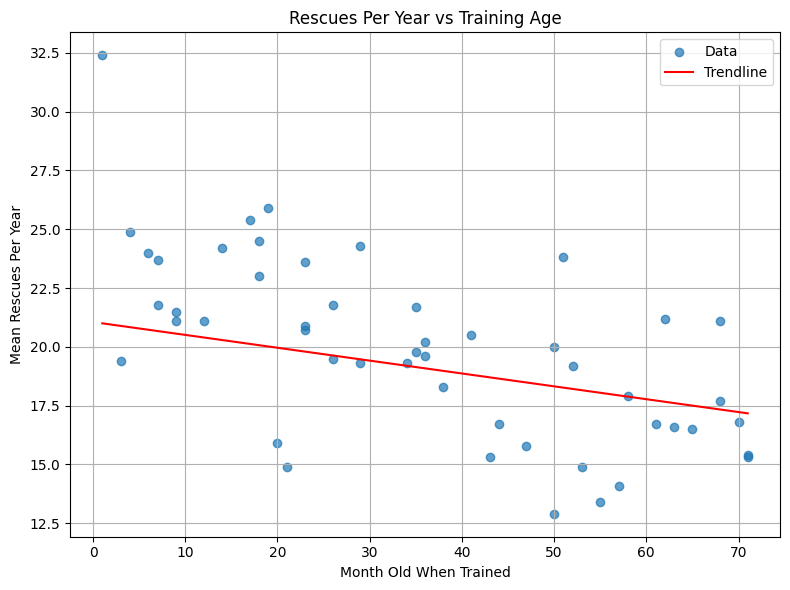

In [ ]:
# Plot the data and trendline after training
import matplotlib.pyplot as plt

x = data["month_old_when_trained"]
y = data["mean_rescues_per_year"]

# Create scatter plot and trendline
plt.figure(figsize=(8, 6))
plt.scatter(x, y, label="Data", alpha=0.7)

x_vals = np.linspace(x.min(), x.max(), 100)
x_vals_df = pandas.DataFrame({"month_old_when_trained": x_vals})
y_preds = model.predict(x_vals_df)

plt.plot(x_vals, y_preds, color="red", label="Trendline")

plt.xlabel("Month Old When Trained")
plt.ylabel("Mean Rescues Per Year")
plt.title("Rescues Per Year vs Training Age")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#####Standardizing data

In [ ]:
# Add the standardized verions of "age_when_trained" to the dataset.
# Notice that it "centers" the mean age around 0
data["standardized_age_when_trained"] = (data.month_old_when_trained - np.mean(data.month_old_when_trained)) / (np.std(data.month_old_when_trained))

# Print a sample of the new dataset
data[:5]

,month_old_when_trained,mean_rescues_per_year,age_last_year,weight_last_year,rescues_last_year,standardized_age_when_trained
0,68,21.1,9,14.5,35,1.537654
1,53,14.9,5,14.0,30,0.826655
2,41,20.5,6,17.7,34,0.257856
3,3,19.4,1,13.7,29,-1.543342
4,4,24.9,4,18.4,30,-1.495942


#####Visualizing Scaled Features

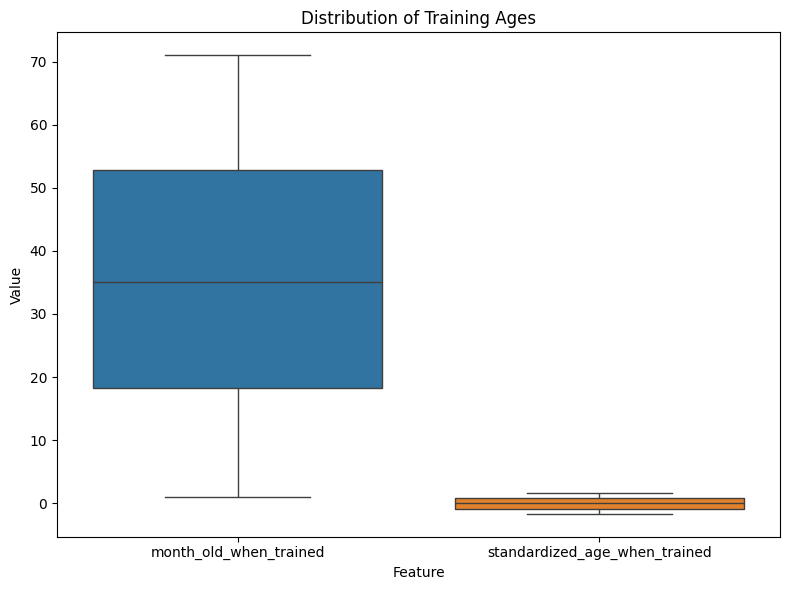

In [ ]:
import seaborn as sns

# Set up the plot
plt.figure(figsize=(8, 6))

# Create the boxplot
sns.boxplot(data=data[["month_old_when_trained", "standardized_age_when_trained"]])

plt.title("Distribution of Training Ages")
plt.ylabel("Value")
plt.xlabel("Feature")

plt.tight_layout()
plt.show()

#####Training with standardized features

In [ ]:
# Let's retrain our model, this time using the standardized feature
model_norm = gradient_descent(data.standardized_age_when_trained, data.mean_rescues_per_year, learning_rate=5E-4, number_of_iterations=8000)


Iteration 0  Current estimate: y = -0.0024692716955674802 * x + 0.01989 Cost: 409.47558290398973
Iteration 100  Current estimate: y = -0.23732823396711042 * x + 1.9116805097144178 Cost: 336.7707406040323
Iteration 200  Current estimate: y = -0.4498267787096774 * x + 3.623357706888266 Cost: 277.25100655774355
Iteration 300  Current estimate: y = -0.642093793265843 * x + 5.172069793284766 Cost: 228.52524594986943
Iteration 400  Current estimate: y = -0.8160554781852587 * x + 6.573332327196407 Cost: 188.63595906277715
Iteration 500  Current estimate: y = -0.9734546445990155 * x + 7.841183663924317 Cost: 155.98064104392154
Iteration 600  Current estimate: y = -1.1158681743324266 * x + 8.988325597103357 Cost: 129.24740317153265
Iteration 700  Current estimate: y = -1.2447228176779614 * x + 10.026250609868582 Cost: 107.3622692791277
Iteration 800  Current estimate: y = -1.361309487096139 * x + 10.965357010711452 Cost: 89.44603003512722
Iteration 900  Current estimate: y = -1.4667961900438482

#####Plotting the standardized model

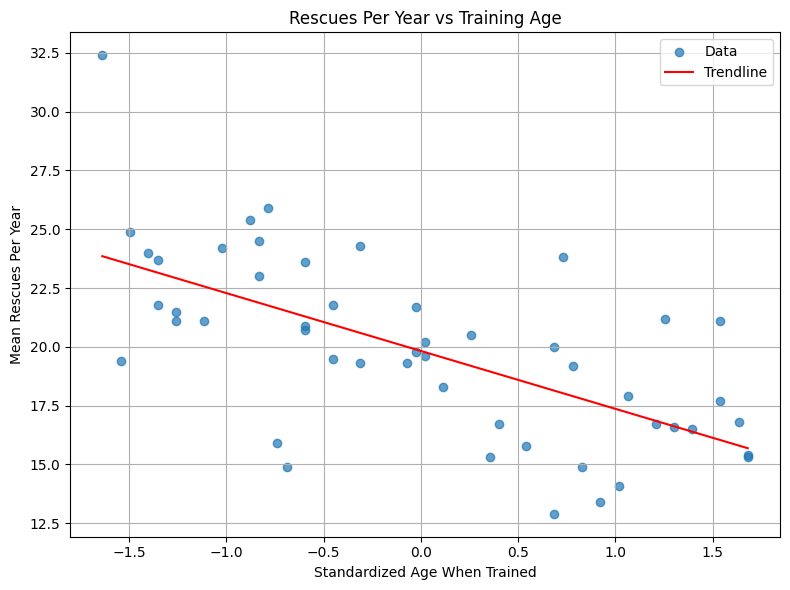

In [ ]:
# Plot the data and trendline again, after training with standardized feature
x = data["standardized_age_when_trained"]
y = data["mean_rescues_per_year"]

# Create scatter plot and trendline
plt.figure(figsize=(8, 6))
plt.scatter(x, y, label="Data", alpha=0.7)

x_vals = np.linspace(x.min(), x.max(), 100)
x_vals_df = pandas.DataFrame({"month_old_when_trained": x_vals})
y_preds = model_norm.predict(x_vals_df)

plt.plot(x_vals, y_preds, color="red", label="Trendline")

plt.xlabel("Standardized Age When Trained")
plt.ylabel("Mean Rescues Per Year")
plt.title("Rescues Per Year vs Training Age")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

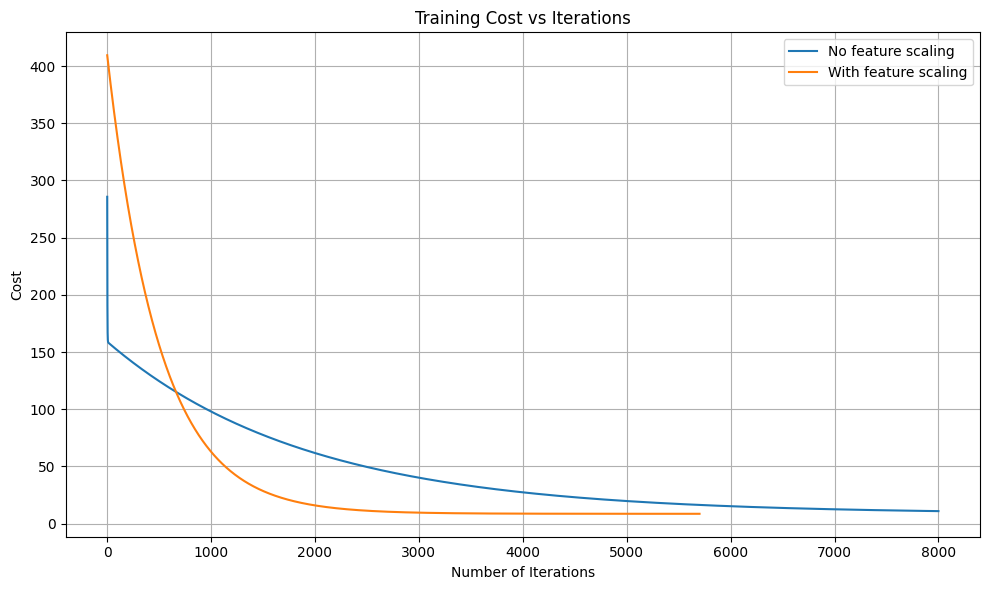

In [ ]:
cost1 = model.cost_history
cost2 = model_norm.cost_history

# Creates dataframes with the cost history for each model
df1 = pandas.DataFrame({"cost": cost1, "Model":"No feature scaling"})
df1["number of iterations"] = df1.index + 1
df2 = pandas.DataFrame({"cost": cost2, "Model":"With feature scaling"})
df2["number of iterations"] = df2.index + 1

# Concatenate dataframes into a single one that we can use in our plot
df = pandas.concat([df1, df2])

# Group the data by model and plot each cost history
plt.figure(figsize=(10, 6))

for label, group in df.groupby("Model"):
    plt.plot(group["number of iterations"], group["cost"], label=label)

plt.xlabel("Number of Iterations")
plt.ylabel("Cost")
plt.title("Training Cost vs Iterations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#####Summary

In this exercise, we covered the following concepts:

- How _Feature scaling_ techniques are used to improve the efficiency of training models
- How to add a standardized feature to a dataset
- How to visualize standardized features and compare them to their original values

Finally, we compared the performance of models before and after using standardized features, using plots to visualize the improvements.

####Exercise - Test and train datasets

#####Loading Data

In [ ]:
import pandas
!pip install statsmodels
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/graphing.py
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/dog-training.csv
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/dog-training-switzerland.csv

data = pandas.read_csv("dog-training.csv", delimiter="\t")

print(data.shape)
print(data.head())

--2025-08-08 16:34:39--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/graphing.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21511 (21K) [text/plain]
Saving to: ‘graphing.py.5’

graphing.py.5       100%[===================>]  21.01K  --.-KB/s    in 0.001s  

2025-08-08 16:34:39 (16.8 MB/s) - ‘graphing.py.5’ saved [21511/21511]

--2025-08-08 16:34:39--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/dog-training.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent,

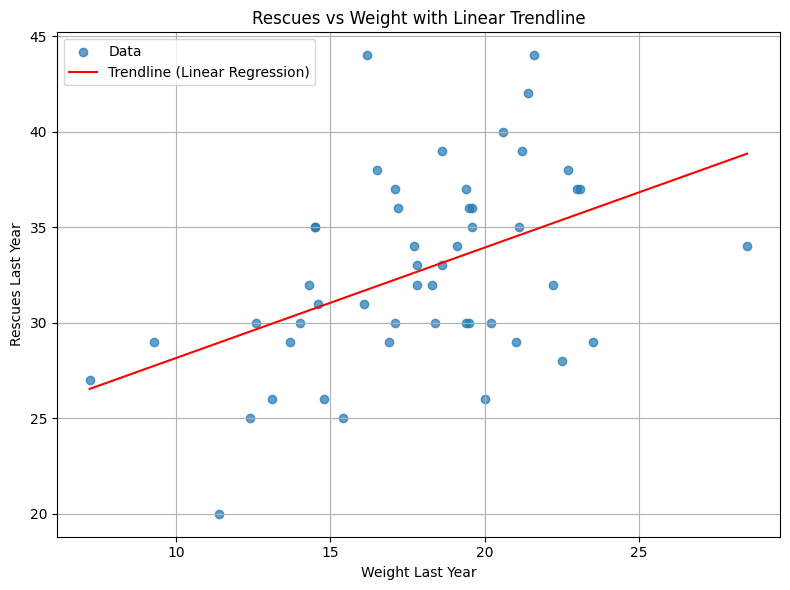

In [ ]:
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import numpy as np

# First, we define our formula using a special syntax
# This says that rescues_last_year is explained by weight_last_year
formula = "rescues_last_year ~ weight_last_year"

model = smf.ols(formula = formula, data = data).fit()

# Extract x and y values
x = data["weight_last_year"]
y = data["rescues_last_year"]

# Scatter plot of the data and trendline
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.7, label="Data")

x_vals = np.linspace(x.min(), x.max(), 100)
y_vals = model.params.iloc[1] * x_vals + model.params.iloc[0]  # Slope * x + Intercept

plt.plot(x_vals, y_vals, color="red", label="Trendline (Linear Regression)")

plt.xlabel("Weight Last Year")
plt.ylabel("Rescues Last Year")
plt.title("Rescues vs Weight with Linear Trendline")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

###### Train/test split


In [ ]:
from sklearn.model_selection import train_test_split


# Obtain the label and feature from the original data
dataset = data[['rescues_last_year','weight_last_year']]

# Split the dataset in an 70/30 train/test ratio. We also obtain the respective corresponding indices from the original dataset.
train, test = train_test_split(dataset, train_size=0.7, random_state=21)

print("Train")
print(train.head())
print(train.shape)

print("Test")
print(test.head())
print(test.shape)

Train
    rescues_last_year  weight_last_year
33                 30              19.4
0                  35              14.5
13                 36              19.5
28                 31              16.1
49                 37              23.0
(35, 2)
Test
    rescues_last_year  weight_last_year
7                  37              17.1
44                 25              15.4
43                 26              20.0
25                 32              22.2
14                 32              18.3
(15, 2)


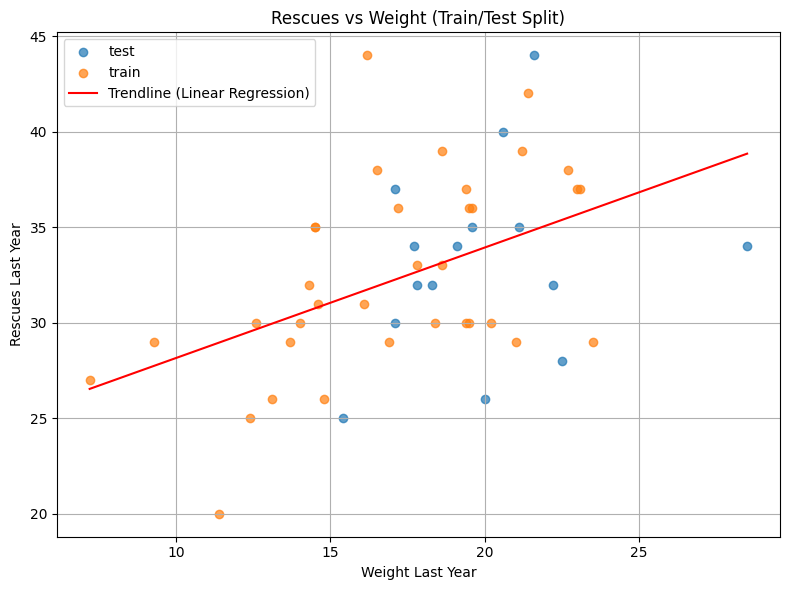

In [ ]:
# You don't need to understand this code well
# It's just used to create a scatter plot

# concatenate training and test so they can be graphed
plot_set = pandas.concat([train,test])
plot_set["Dataset"] = ["train"] * len(train) + ["test"] * len(test)

# Scatter plot with color by Dataset
plt.figure(figsize=(8, 6))

for label, group in plot_set.groupby("Dataset"):
    plt.scatter(group["weight_last_year"], group["rescues_last_year"], label=label, alpha=0.7)

# Regression trendline using model coefficients
x_vals = np.linspace(plot_set["weight_last_year"].min(), plot_set["weight_last_year"].max(), 100)
y_vals = model.params.iloc[1] * x_vals + model.params.iloc[0]

plt.plot(x_vals, y_vals, color="red", label="Trendline (Linear Regression)")

plt.xlabel("Weight Last Year")
plt.ylabel("Rescues Last Year")
plt.title("Rescues vs Weight (Train/Test Split)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#####Training Set

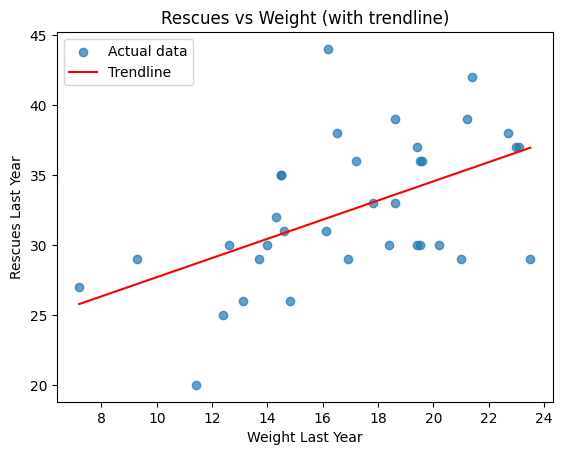

In [ ]:
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error as mse

# First, we define our formula using a special syntax
# This says that rescues_last_year is explained by weight_last_year
formula = "rescues_last_year ~ weight_last_year"

# Create and train the model
model = smf.ols(formula = formula, data = train).fit()

# Graph the result against the data
plt.scatter(train["weight_last_year"], train["rescues_last_year"], label="Actual data", alpha=0.7)

# Create a trendline using the model's parameters
x_vals = np.linspace(train["weight_last_year"].min(), train["weight_last_year"].max(), 100)
y_vals = model.params.iloc[1] * x_vals + model.params.iloc[0]

# Plot the trendline
plt.plot(x_vals, y_vals, color="red", label="Trendline")

plt.xlabel("Weight Last Year")
plt.ylabel("Rescues Last Year")
plt.title("Rescues vs Weight (with trendline)")
plt.legend()
plt.show()

In [ ]:
# We use the in-buit sklearn function to calculate the MSE
correct_labels = train['rescues_last_year']
predicted = model.predict(train['weight_last_year'])

MSE = mse(correct_labels, predicted)
print('MSE = %f ' % MSE)

MSE = 18.674546 


#####Test Set


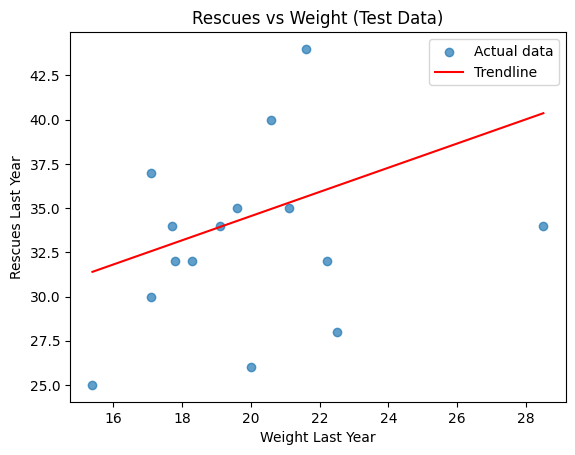

In [ ]:
plt.scatter(test["weight_last_year"], test["rescues_last_year"], label="Actual data", alpha=0.7)

# Create a trendline using the model's parameters
x_vals = np.linspace(test["weight_last_year"].min(), test["weight_last_year"].max(), 100)
y_vals = model.params.iloc[1] * x_vals + model.params.iloc[0]

# Plot the trendline
plt.plot(x_vals, y_vals, color="red", label="Trendline")

plt.xlabel("Weight Last Year")
plt.ylabel("Rescues Last Year")
plt.title("Rescues vs Weight (Test Data)")
plt.legend()
plt.show()

In [ ]:
correct_labels = test['rescues_last_year']
predicted = model.predict(test['weight_last_year'])

MSE = mse(correct_labels, predicted)
print('MSE = %f ' % MSE)

MSE = 24.352949 


#####New Dataset

In [ ]:
# Load an alternative dataset from the charity's European branch
new_data = pandas.read_csv("dog-training-switzerland.csv", delimiter="\t")

print(new_data.shape)
new_data.head()


(500, 5)


,month_old_when_trained,mean_rescues_per_year,age_last_year,weight_last_year,rescues_last_year
0,9,16.7,2,15.709342,30
1,33,24.2,8,14.760819,35
2,43,20.2,4,13.118374,19
3,37,19.2,5,10.614075,24
4,45,16.9,8,17.519890,28


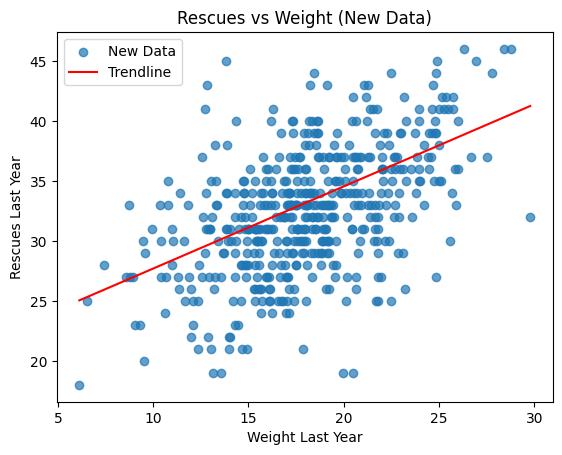

In [ ]:
# Plot the fitted model against this new dataset.

plt.scatter(new_data["weight_last_year"], new_data["rescues_last_year"], label="New Data", alpha=0.7)

# Create a trendline using the model's parameters
x_vals = np.linspace(new_data["weight_last_year"].min(), new_data["weight_last_year"].max(), 100)
y_vals = model.params.iloc[1] * x_vals + model.params.iloc[0]

# Plot the trendline
plt.plot(x_vals, y_vals, color="red", label="Trendline")

plt.xlabel("Weight Last Year")
plt.ylabel("Rescues Last Year")
plt.title("Rescues vs Weight (New Data)")
plt.legend()
plt.show()

In [ ]:
correct_labels = new_data['rescues_last_year']
predicted = model.predict(new_data['weight_last_year'])

MSE = mse(correct_labels, predicted)
print('MSE = %f ' % MSE)

MSE = 20.406905 


#####Summary

In this exercise, we covered the following concepts:

 - Splitting a dataset into a _training set_ and a _test set_
 - Training a model using the _training set_ and testing its performance on the _training set_, _test set_, and on a new, unseen dataset
 - Compared the respective MSEs to highlight the effects and dangers of _overfitting_

####Exercise - Test set nuances

#####Loading Data

In [ ]:
import pandas
!pip install statsmodels
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/dog-training.csv
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/dog-training-switzerland.csv
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/graphing.py

data = pandas.read_csv("dog-training.csv", delimiter="\t")

print(f"Dataset shape: {data.shape}")
data.head()

--2025-08-08 16:52:50--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/dog-training.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 974 [text/plain]
Saving to: ‘dog-training.csv.3’

dog-training.csv.3  100%[===================>]     974  --.-KB/s    in 0s      

2025-08-08 16:52:50 (32.8 MB/s) - ‘dog-training.csv.3’ saved [974/974]

--2025-08-08 16:52:50--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/dog-training-switzerland.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected

,month_old_when_trained,mean_rescues_per_year,age_last_year,weight_last_year,rescues_last_year
0,68,21.1,9,14.5,35
1,53,14.9,5,14.0,30
2,41,20.5,6,17.7,34
3,3,19.4,1,13.7,29
4,4,24.9,4,18.4,30


No. observations: 50


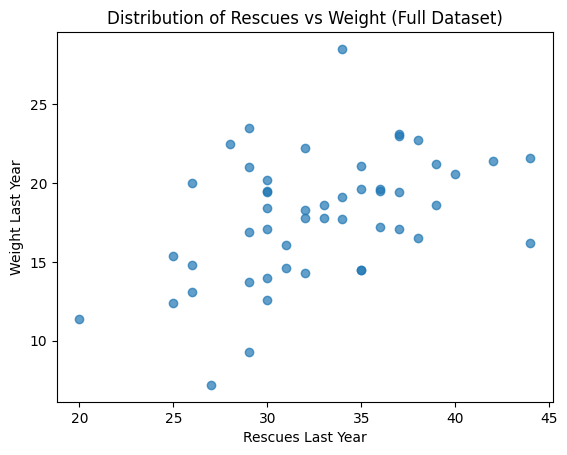

In [ ]:
import matplotlib.pyplot as plt

# Obtain the label and feature from the original data
dataset = data[['rescues_last_year','weight_last_year']]

# Print the number of observations
print("No. observations:", dataset.shape[0])

# Scatter plot of the full (unsplit) dataset
plt.scatter(dataset['rescues_last_year'], dataset['weight_last_year'], alpha=0.7)

plt.xlabel("Rescues Last Year")
plt.ylabel("Weight Last Year")
plt.title("Distribution of Rescues vs Weight (Full Dataset)")
plt.show()

#####Dataset split ratio comparison

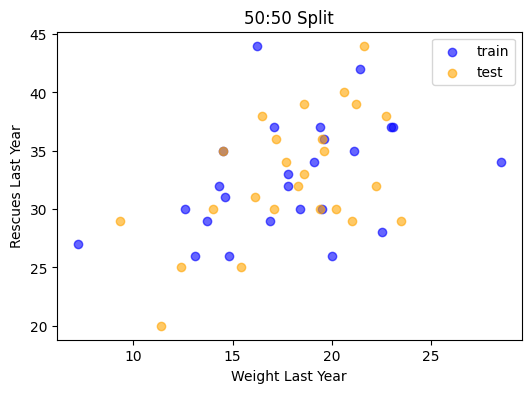

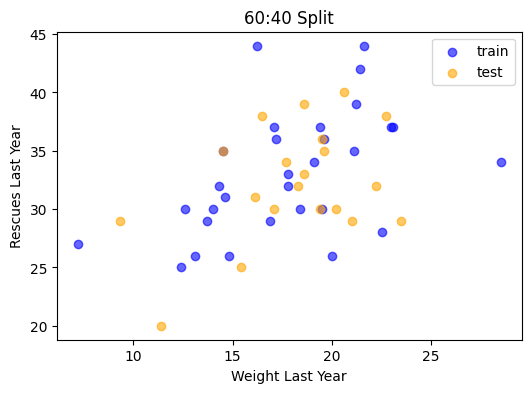

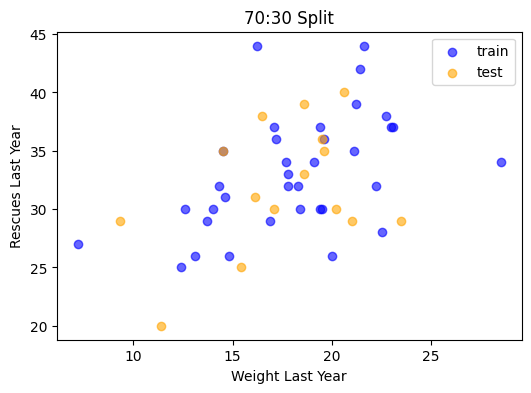

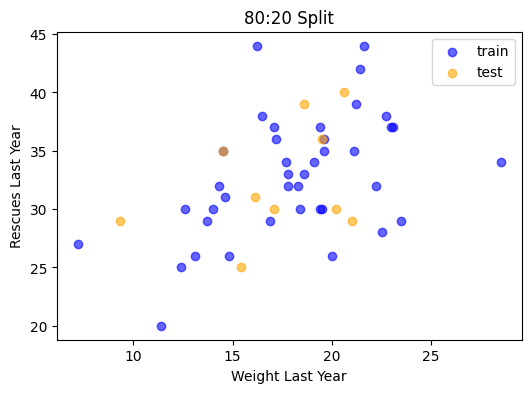

In [ ]:
from sklearn.model_selection import train_test_split

# Split Dataset using different ratios 50:50, 60:40, 70:30, 80:20
train_5050, test_5050 = train_test_split(dataset, test_size=0.5, random_state=2)
train_6040, test_6040 = train_test_split(dataset, test_size=0.4, random_state=2)
train_7030, test_7030 = train_test_split(dataset, test_size=0.3, random_state=2)
train_8020, test_8020 = train_test_split(dataset, test_size=0.2, random_state=2)

# Add a column to each set to identify if a datapoint belongs to "train" or "test"
train_5050, test_5050 = train_5050.assign(Set="train"), test_5050.assign(Set="test")
train_6040, test_6040 = train_6040.assign(Set="train"), test_6040.assign(Set="test")
train_7030, test_7030 = train_7030.assign(Set="train"), test_7030.assign(Set="test")
train_8020, test_8020 = train_8020.assign(Set="train"), test_8020.assign(Set="test")

# Concatenate the "train" and "test" sets for each split so we can plot them on the same chart
df_5050 = pandas.concat([train_5050, test_5050], axis=0)
df_6040 = pandas.concat([train_6040, test_6040], axis=0)
df_7030 = pandas.concat([train_7030, test_7030], axis=0)
df_8020 = pandas.concat([train_8020, test_8020], axis=0)

# Function to plot each split
def plot_split(df, title):
    colors = {'train': 'blue', 'test': 'orange'}
    plt.figure(figsize=(6, 4))
    for label in df["Set"].unique():
        subset = df[df["Set"] == label]
        plt.scatter(subset["weight_last_year"], subset["rescues_last_year"],
                    label=label, alpha=0.6, c=colors[label])
    plt.xlabel("Weight Last Year")
    plt.ylabel("Rescues Last Year")
    plt.title(title)
    plt.legend()
    plt.show()

# Plot each distribution for comparison
plot_split(df_5050, "50:50 Split")
plot_split(df_6040, "60:40 Split")
plot_split(df_7030, "70:30 Split")
plot_split(df_8020, "80:20 Split")

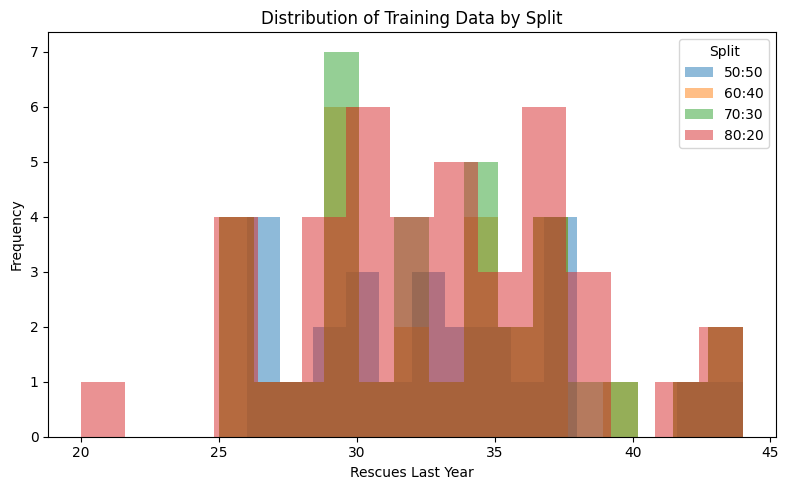

In [ ]:
# Add a column for each "train" set that identifies the split used
train_8020 = train_8020.assign(Split="80:20")
train_7030 = train_7030.assign(Split="70:30")
train_6040 = train_6040.assign(Split="60:40")
train_5050 = train_5050.assign(Split="50:50")

# Concatenate training sets so we can plot them on the same chart
split_df = pandas.concat([train_5050, train_6040, train_7030, train_8020], axis=0)

# Plot a histogram of data distribution
plt.figure(figsize=(8, 5))
splits = split_df["Split"].unique()
for split in splits:
    subset = split_df[split_df["Split"] == split]
    plt.hist(subset["rescues_last_year"], bins=15, alpha=0.5, label=split)

plt.xlabel("Rescues Last Year")
plt.ylabel("Frequency")
plt.title("Distribution of Training Data by Split")
plt.legend(title="Split")
plt.tight_layout()
plt.show()

#####Fitting and evaluating models with different split ratios

In [ ]:
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error as mse

def train_and_test_model(name, train, test):
    '''
    This method creates a model, trains it on the provided data, and assesses
    it against the test data
    '''
    # This formula says that rescues_last_year is explained by weight_last_year
    formula = "rescues_last_year ~ weight_last_year"

    # Create and train a linear regression model using the training data
    model = smf.ols(formula = formula, data = train).fit()

    # Now evaluate the model (by calculating the Mean Squared Error) using the
    # corresponding "test" set for that split
    correct_answers = test['rescues_last_year']
    predictions = model.predict(test['weight_last_year'])
    MSE = mse(correct_answers, predictions)
    print(name + ' MSE = %f ' % MSE)

    return model


# Train a model and test it for each kind of split
print("Mean Squared Error values (smaller is better)")
model_5050 = train_and_test_model("50:50", train_5050, test_5050)
model_6040 = train_and_test_model("60:40", train_6040, test_6040)
model_7030 = train_and_test_model("70:30", train_7030, test_7030)
model_8020 = train_and_test_model("80:20", train_8020, test_8020)

Mean Squared Error values (smaller is better)
50:50 MSE = 21.930788 
60:40 MSE = 19.834762 
70:30 MSE = 23.747817 
80:20 MSE = 18.441786 


#####Model evaluation

The Swiss dataset contains 500 samples


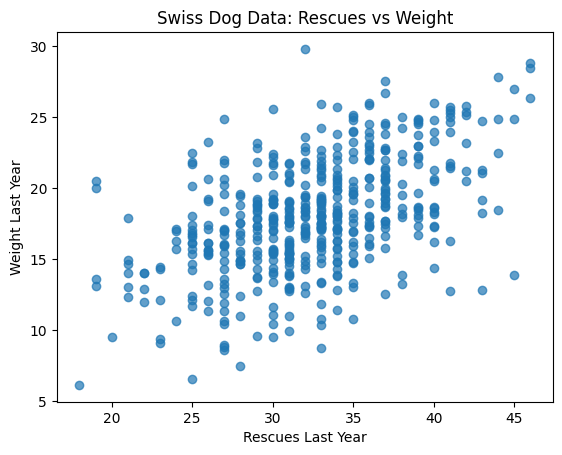

In [ ]:
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error as mse

# Load some dog statistics from our charity's European arm
swiss_data = pandas.read_csv("dog-training-switzerland.csv", delimiter="\t")

# Show show information about the data
print(f"The Swiss dataset contains {swiss_data.shape[0]} samples")

plt.scatter(swiss_data['rescues_last_year'], swiss_data['weight_last_year'], alpha=0.7)

plt.xlabel("Rescues Last Year")
plt.ylabel("Weight Last Year")
plt.title("Swiss Dog Data: Rescues vs Weight")
plt.show()

In [ ]:
# Test our models against the swiss data
features = swiss_data['weight_last_year']
correct_answers = swiss_data['rescues_last_year']

# We will now assess our models. Notice we're not training them again.
# We are simply testing them against some new data

# Assess the model trained on a 50:50 split
predictions = model_5050.predict(features)
MSE = mse(correct_answers, predictions)
print('50:50 MSE = %f ' % MSE)

# Assess the model trained on a 60:40 split
predictions = model_6040.predict(features)
MSE = mse(correct_answers, predictions)
print('60:40 MSE = %f ' % MSE)

# Assess the model trained on a 70:30 split
predictions = model_7030.predict(features)
MSE = mse(correct_answers, predictions)
print('70:30 MSE = %f ' % MSE)

# Assess the model trained on a 80:20 split
predictions = model_8020.predict(features)
MSE = mse(correct_answers, predictions)
print('80:20 MSE = %f ' % MSE)

50:50 MSE = 20.903325 
60:40 MSE = 20.520190 
70:30 MSE = 20.355991 
80:20 MSE = 20.061225 


#####Summary

In this exercise, you learned the following concepts:

 - You can use different *ratios* when splitting your dataset into *train* and *test* sets.
 - Different ratios yield different distributions of variables in the resulting *train* and *test* sets.
 - When the train:test ratios are close, you're possibly leaving a lot of data out of the __training__ set, and that can have a negative impact on your model's performance.
 - When building models, it's important to test them using different train/test splits. Simply assigning more data to the *train* set doesn't always guarantee the best results.


####Summary

In this module, you learned about how to test machine learning models. You also learned about normalization and standardization, and reviewed the hold-out approach.

Now that you've reviewed this module, you should be able to:

- Define feature normalization.
- Create and work with test datasets.
- Articulate how testing models can both improve and harm training.

Use these resources to discover more
- [ML.NET Tutorial](https://dotnet.microsoft.com/learn/ml-dotnet/get-started-tutorial/intro)
- [Azure Machine Learning](https://azure.microsoft.com/products/machine-learning/)

###Train and evaluate regression models

####Learning objectives

####Exercise - Train and evaluate a regression model

#####Explore the Data

In [ ]:
import pandas as pd

# load the training dataset
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/ml-basics/daily-bike-share.csv
bike_data = pd.read_csv('daily-bike-share.csv')
bike_data.head()

--2025-08-08 17:32:54--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/ml-basics/daily-bike-share.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48800 (48K) [text/plain]
Saving to: ‘daily-bike-share.csv’

daily-bike-share.cs 100%[===================>]  47.66K  --.-KB/s    in 0.009s  

2025-08-08 17:32:55 (4.91 MB/s) - ‘daily-bike-share.csv’ saved [48800/48800]



,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120
3,4,1/4/2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108
4,5,1/5/2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82


The data consists of the following columns:

- **instant**: A unique row identifier
- **dteday**: The date on which the data was observed; in this case, the data was collected daily, so there's one row per date.
- **season**: A numerically encoded value indicating the season (1:winter, 2:spring, 3:summer, 4:fall)
- **yr**: The year of the study in which the observation was made (the study took place over two years: year 0 represents 2011, and year 1 represents 2012)
- **mnth**: The calendar month in which the observation was made (1:January ... 12:December)
- **holiday**: A binary value indicating whether or not the observation was made on a public holiday)
- **weekday**: The day of the week on which the observation was made (0:Sunday ... 6:Saturday)
- **workingday**: A binary value indicating whether or not the day is a working day (not a weekend or holiday)
- **weathersit**: A categorical value indicating the weather situation (1:clear, 2:mist/cloud, 3:light rain/snow, 4:heavy rain/hail/snow/fog)
- **temp**: The temperature in celsius (normalized)
- **atemp**: The apparent ("feels-like") temperature in celsius (normalized)
- **hum**: The humidity level (normalized)
- **windspeed**: The windspeed (normalized)
- **rentals**: The number of bicycle rentals recorded.

In this dataset, **rentals** represents the label (the *y* value) we must train our model to predict. The other columns are potential features (*x* values).

#####Feature Engineering

In [ ]:
bike_data['day'] = pd.DatetimeIndex(bike_data['dteday']).day
bike_data.head(32)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals,day
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,1
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,2
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,3
3,4,1/4/2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,4
4,5,1/5/2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,5
5,6,1/6/2011,1,0,1,0,4,1,1,0.204348,0.233209,0.518261,0.089565,88,6
6,7,1/7/2011,1,0,1,0,5,1,2,0.196522,0.208839,0.498696,0.168726,148,7
7,8,1/8/2011,1,0,1,0,6,0,2,0.165000,0.162254,0.535833,0.266804,68,8
8,9,1/9/2011,1,0,1,0,0,0,1,0.138333,0.116175,0.434167,0.361950,54,9
9,10,1/10/2011,1,0,1,0,1,1,1,0.150833,0.150888,0.482917,0.223267,41,10


In [ ]:
numeric_features = ['temp', 'atemp', 'hum', 'windspeed']
bike_data[numeric_features + ['rentals']].describe()

,temp,atemp,hum,windspeed,rentals
count,731.000000,731.000000,731.000000,731.000000,731.000000
mean,0.495385,0.474354,0.627894,0.190486,848.176471
std,0.183051,0.162961,0.142429,0.077498,686.622488
min,0.059130,0.079070,0.000000,0.022392,2.000000
25%,0.337083,0.337842,0.520000,0.134950,315.500000
50%,0.498333,0.486733,0.626667,0.180975,713.000000
75%,0.655417,0.608602,0.730209,0.233214,1096.000000
max,0.861667,0.840896,0.972500,0.507463,3410.000000


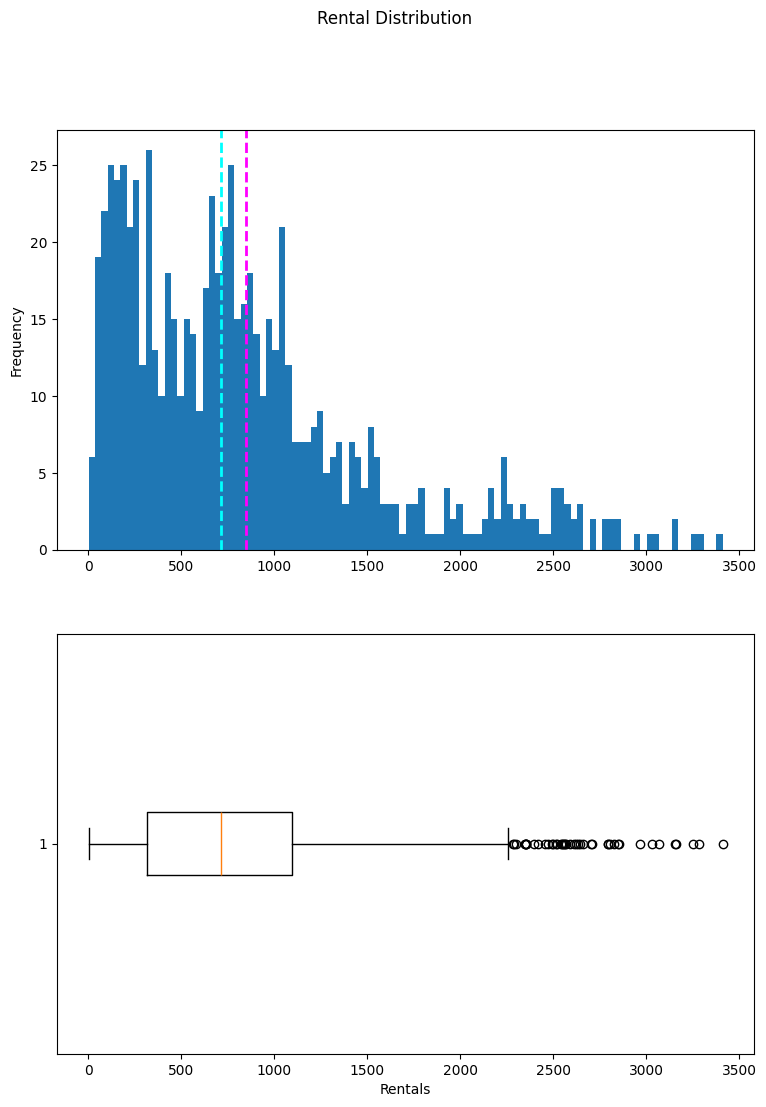

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# This ensures plots are displayed inline in the Jupyter notebook
%matplotlib inline

# Get the label column
label = bike_data['rentals']


# Create a figure for 2 subplots (2 rows, 1 column)
fig, ax = plt.subplots(2, 1, figsize = (9,12))

# Plot the histogram
ax[0].hist(label, bins=100)
ax[0].set_ylabel('Frequency')

# Add lines for the mean, median, and mode
ax[0].axvline(label.mean(), color='magenta', linestyle='dashed', linewidth=2)
ax[0].axvline(label.median(), color='cyan', linestyle='dashed', linewidth=2)

# Plot the boxplot
ax[1].boxplot(label, vert=False)
ax[1].set_xlabel('Rentals')

# Add a title to the Figure
fig.suptitle('Rental Distribution')

# Show the figure
fig.show()


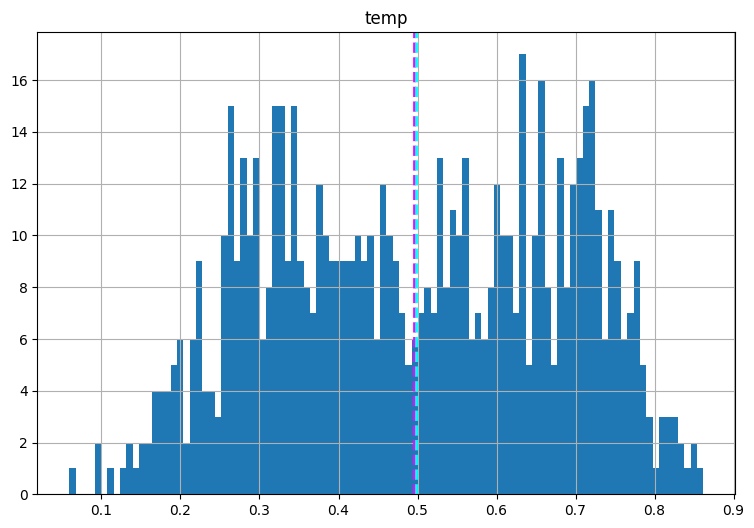

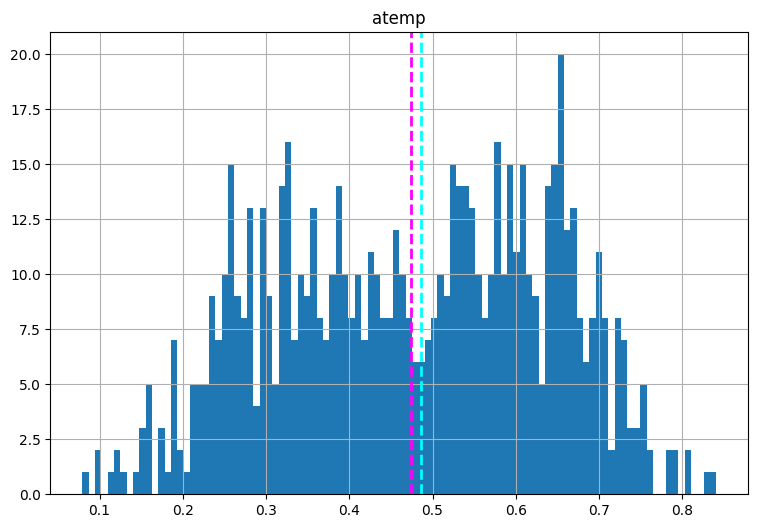

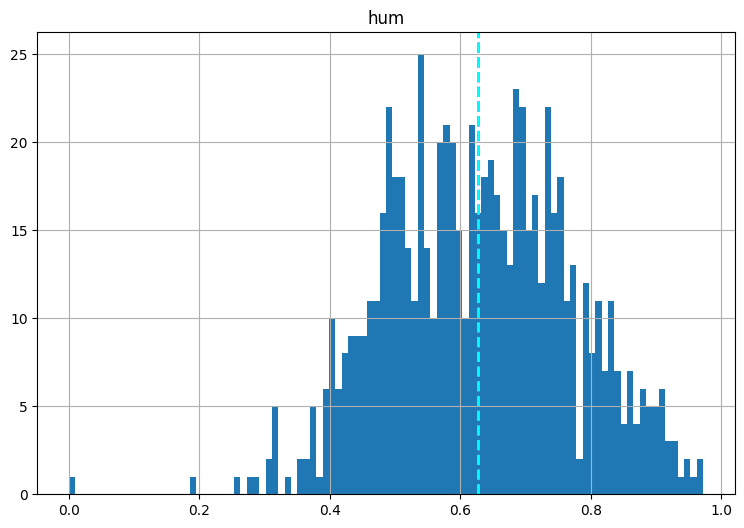

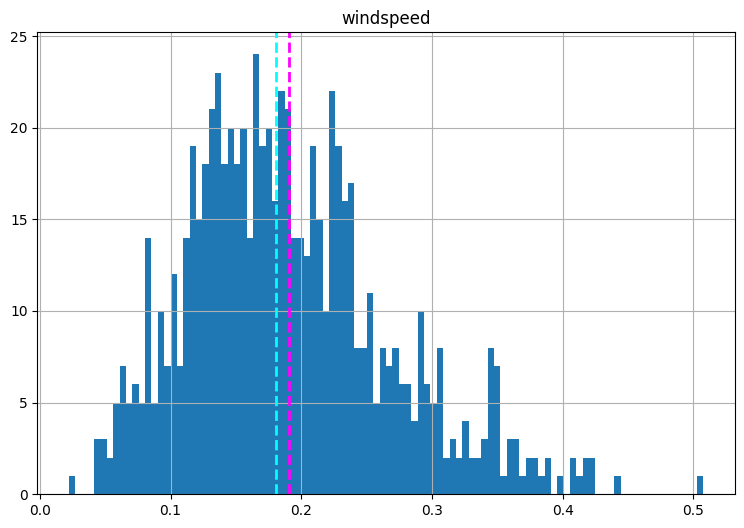

In [ ]:
# Plot a histogram for each numeric feature
for col in numeric_features:
    fig = plt.figure(figsize=(9, 6))
    ax = fig.gca()
    feature = bike_data[col]
    feature.hist(bins=100, ax = ax)
    ax.axvline(feature.mean(), color='magenta', linestyle='dashed', linewidth=2)
    ax.axvline(feature.median(), color='cyan', linestyle='dashed', linewidth=2)
    ax.set_title(col)
plt.show()

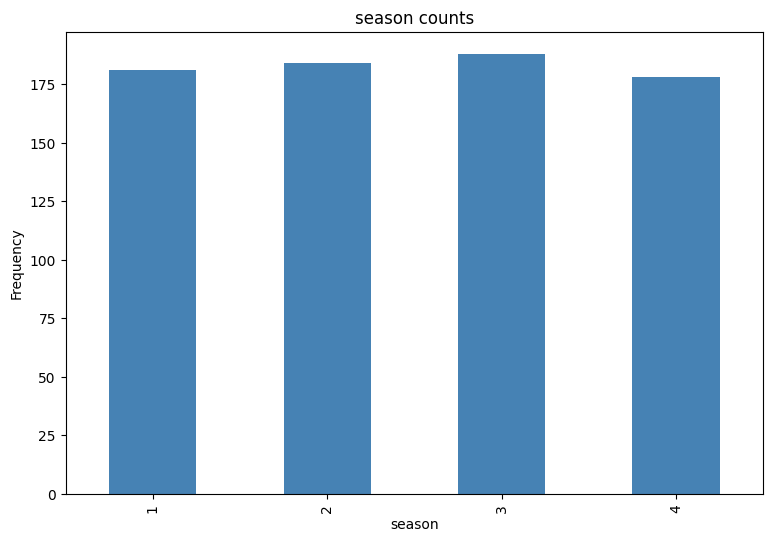

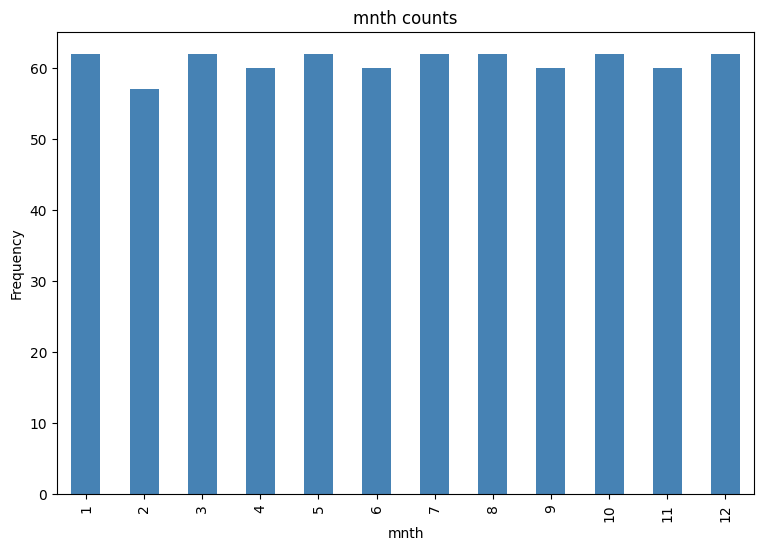

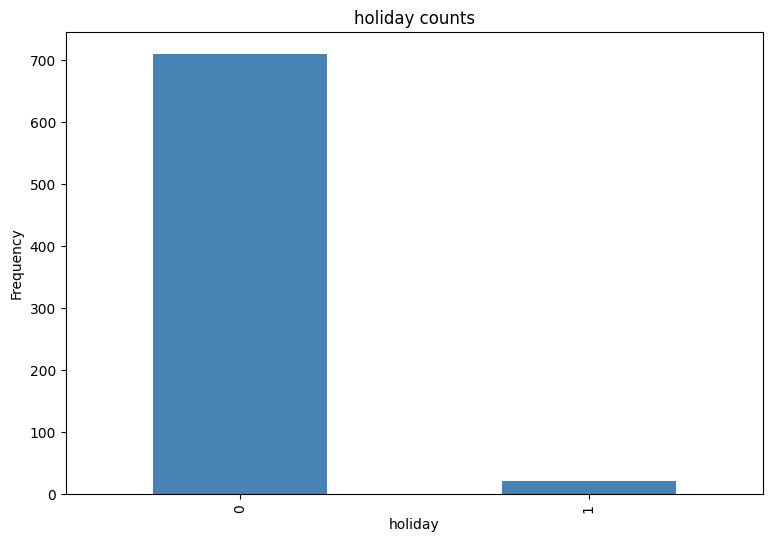

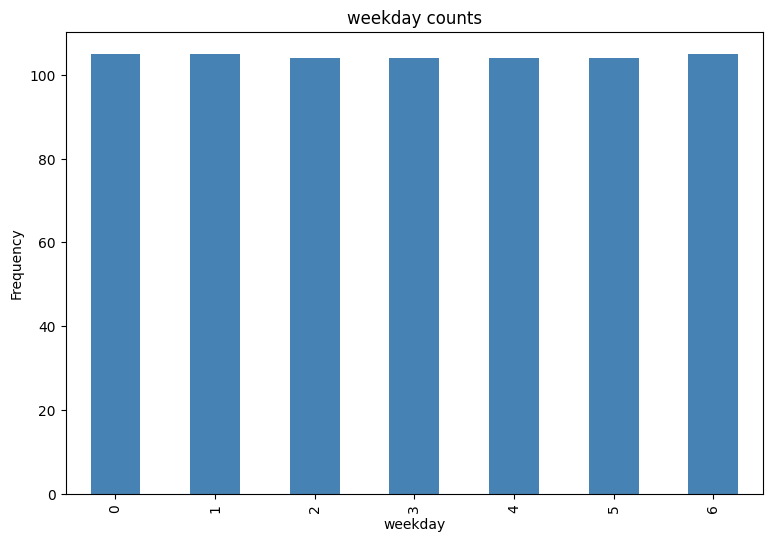

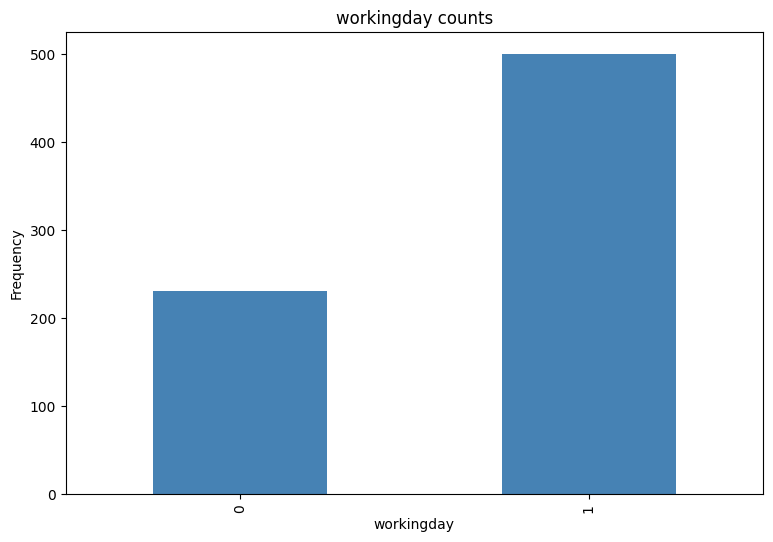

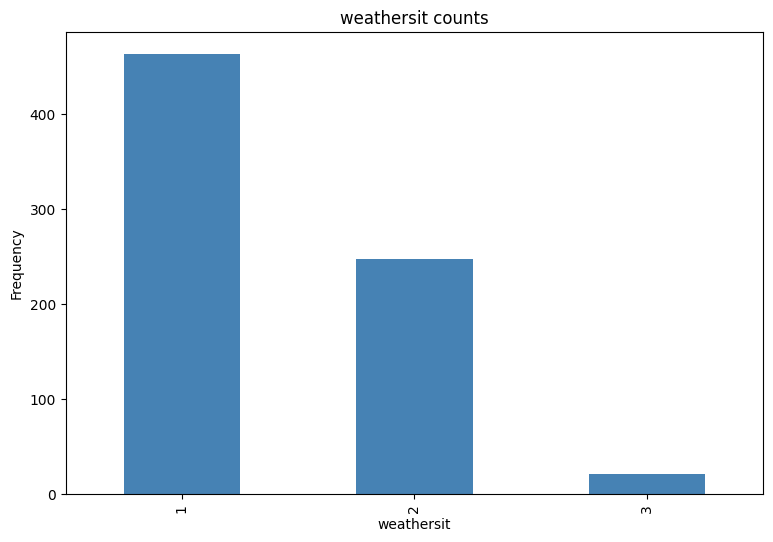

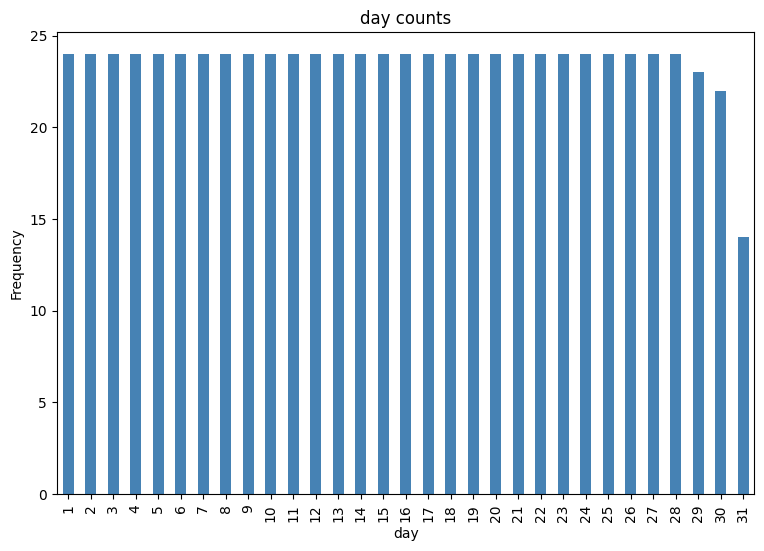

In [ ]:
import numpy as np

# plot a bar plot for each categorical feature count
categorical_features = ['season','mnth','holiday','weekday','workingday','weathersit', 'day']

for col in categorical_features:
    counts = bike_data[col].value_counts().sort_index()
    fig = plt.figure(figsize=(9, 6))
    ax = fig.gca()
    counts.plot.bar(ax = ax, color='steelblue')
    ax.set_title(col + ' counts')
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
plt.show()


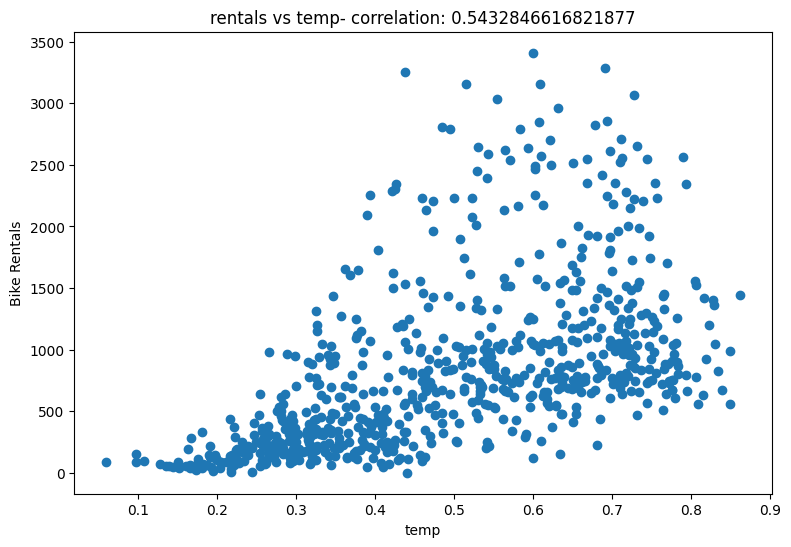

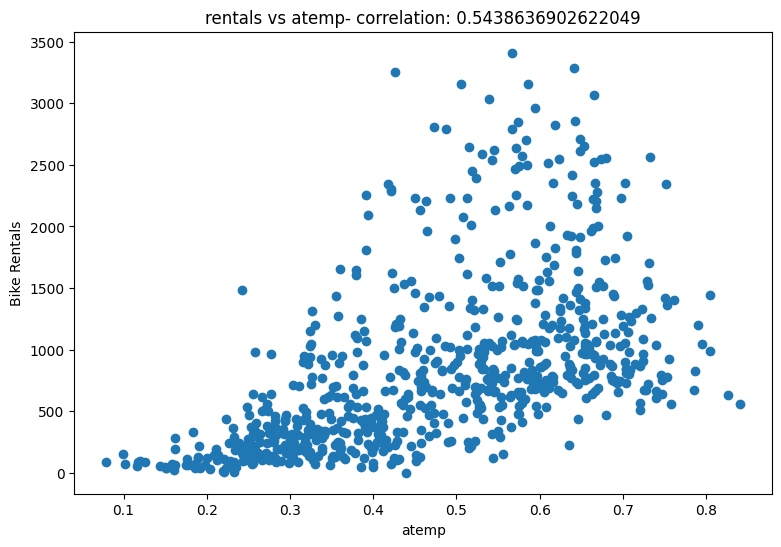

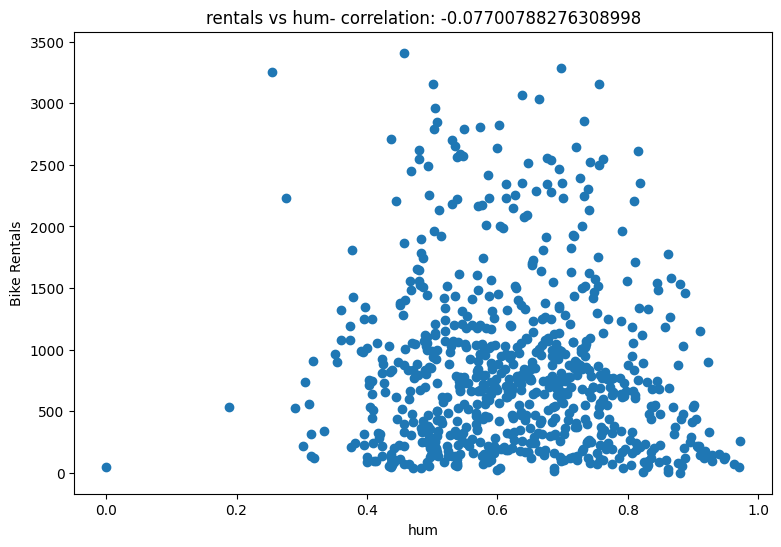

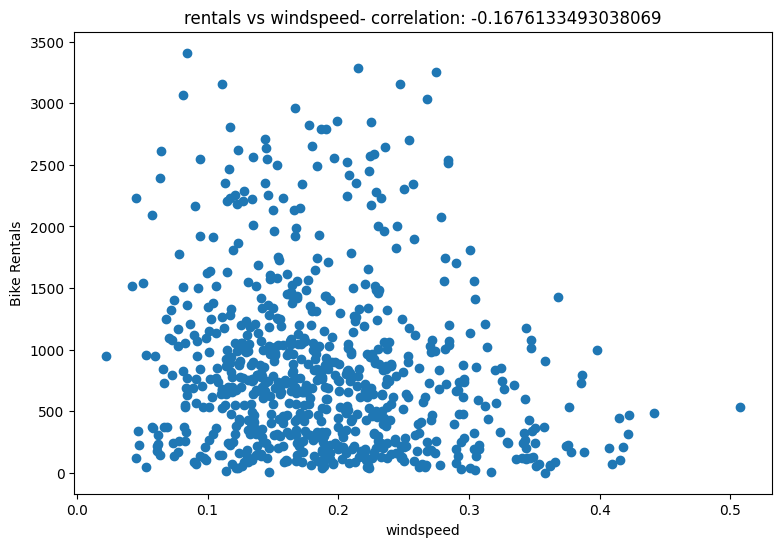

In [ ]:
for col in numeric_features:
    fig = plt.figure(figsize=(9, 6))
    ax = fig.gca()
    feature = bike_data[col]
    label = bike_data['rentals']
    correlation = feature.corr(label)
    plt.scatter(x=feature, y=label)
    plt.xlabel(col)
    plt.ylabel('Bike Rentals')
    ax.set_title('rentals vs ' + col + '- correlation: ' + str(correlation))
plt.show()


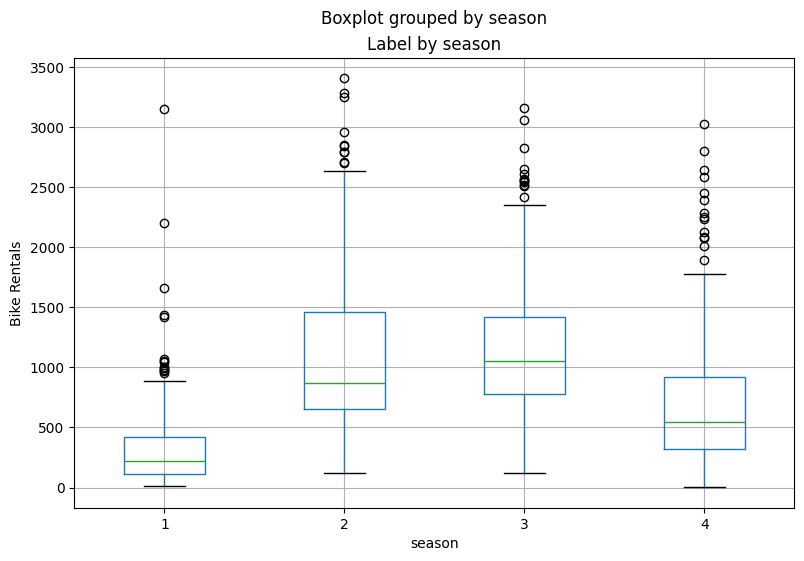

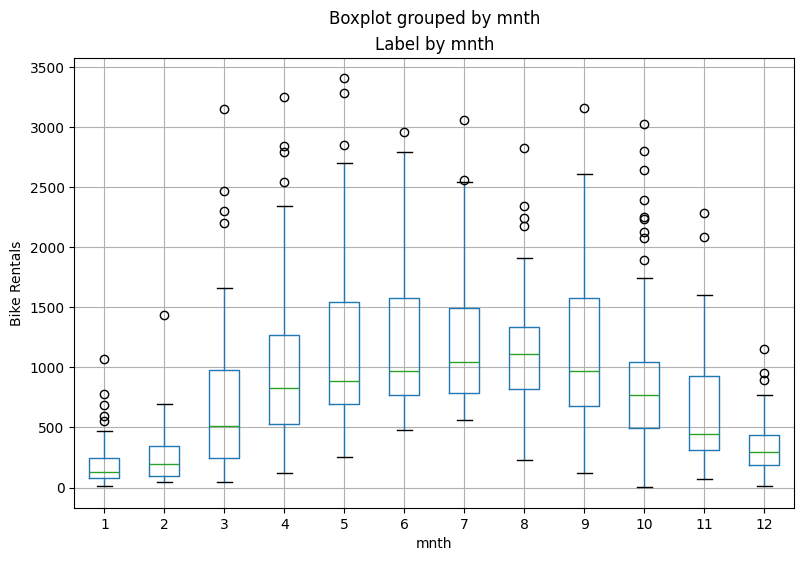

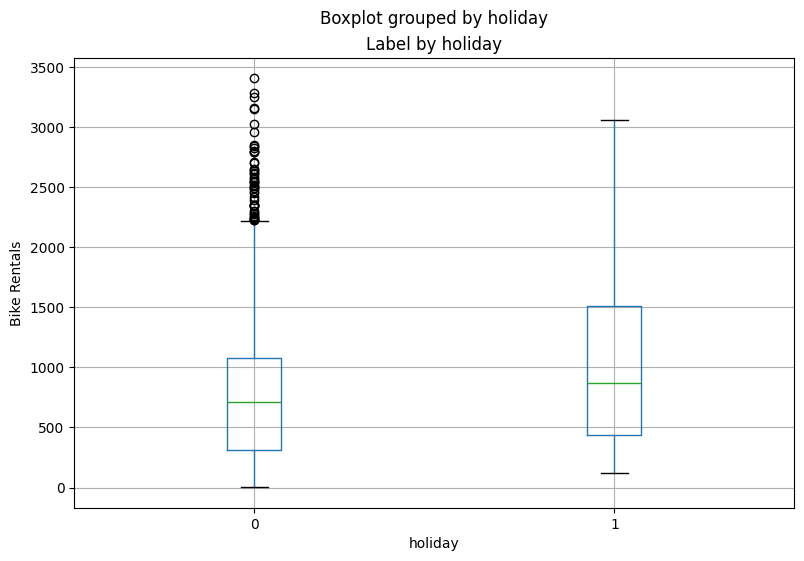

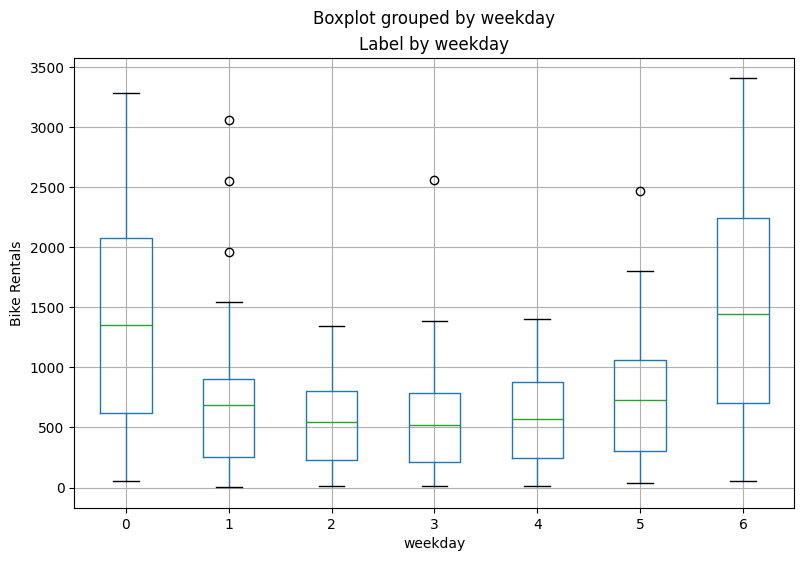

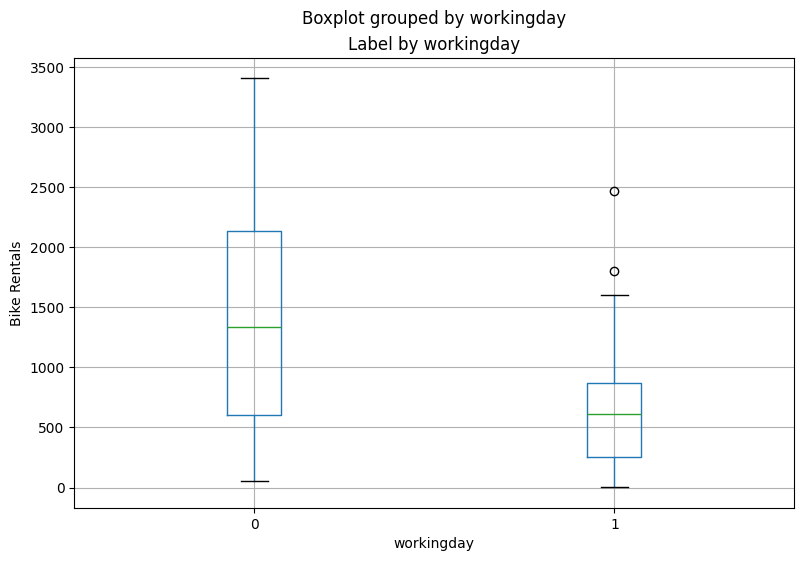

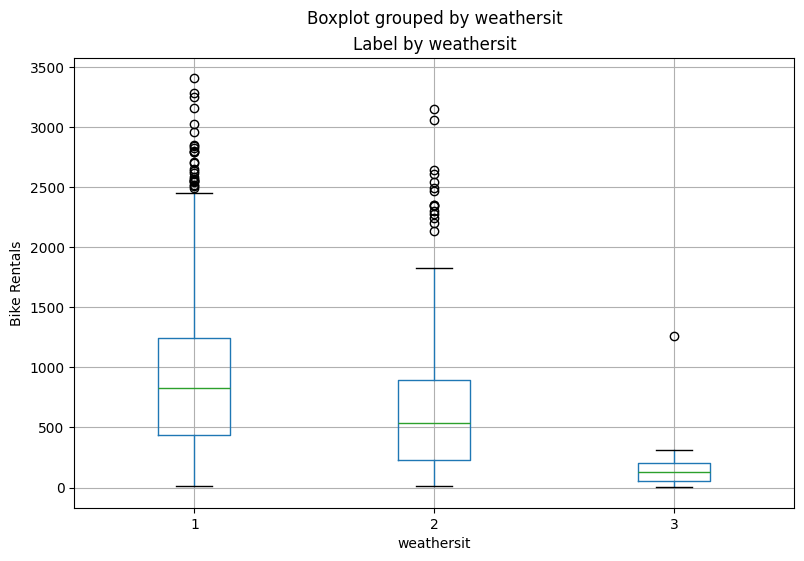

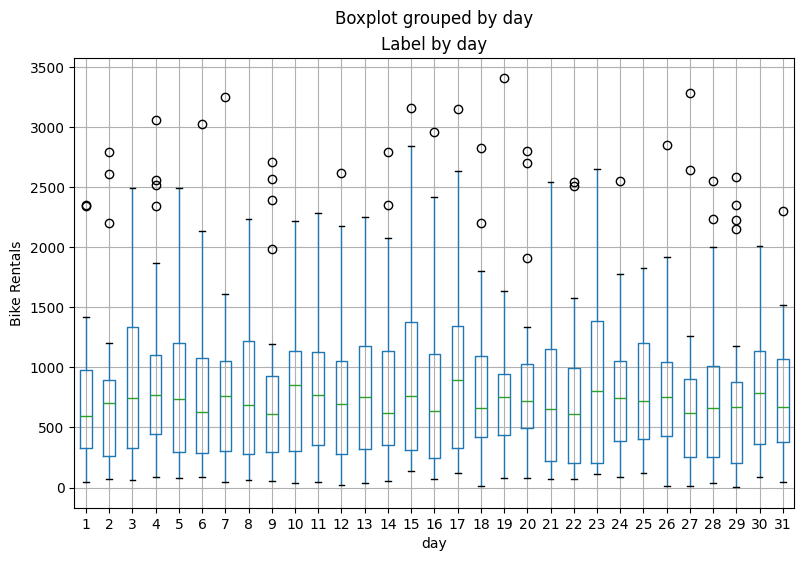

In [ ]:
# plot a boxplot for the label by each categorical feature
for col in categorical_features:
    fig = plt.figure(figsize=(9, 6))
    ax = fig.gca()
    bike_data.boxplot(column = 'rentals', by = col, ax = ax)
    ax.set_title('Label by ' + col)
    ax.set_ylabel("Bike Rentals")
plt.show()

#####Train a Regression Model

In [ ]:
# Separate features and labels
X, y = bike_data[['season','mnth', 'holiday','weekday','workingday','weathersit','temp', 'atemp', 'hum', 'windspeed']].values, bike_data['rentals'].values
print('Features:',X[:10], '\nLabels:', y[:10], sep='\n')

Features:
[[1.        1.        0.        6.        0.        2.        0.344167
  0.363625  0.805833  0.160446 ]
 [1.        1.        0.        0.        0.        2.        0.363478
  0.353739  0.696087  0.248539 ]
 [1.        1.        0.        1.        1.        1.        0.196364
  0.189405  0.437273  0.248309 ]
 [1.        1.        0.        2.        1.        1.        0.2
  0.212122  0.590435  0.160296 ]
 [1.        1.        0.        3.        1.        1.        0.226957
  0.22927   0.436957  0.1869   ]
 [1.        1.        0.        4.        1.        1.        0.204348
  0.233209  0.518261  0.0895652]
 [1.        1.        0.        5.        1.        2.        0.196522
  0.208839  0.498696  0.168726 ]
 [1.        1.        0.        6.        0.        2.        0.165
  0.162254  0.535833  0.266804 ]
 [1.        1.        0.        0.        0.        1.        0.138333
  0.116175  0.434167  0.36195  ]
 [1.        1.        0.        1.        1.        1.        

In [ ]:
from sklearn.model_selection import train_test_split

# Split data 70%-30% into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0)

print ('Training Set: %d rows\nTest Set: %d rows' % (X_train.shape[0], X_test.shape[0]))

Training Set: 511 rows
Test Set: 220 rows


In [ ]:
# Train the model
from sklearn.linear_model import LinearRegression

# Fit a linear regression model on the training set
model = LinearRegression().fit(X_train, y_train)
print (model)

LinearRegression()


#####Evaluate the Trained Model

In [ ]:
import numpy as np

predictions = model.predict(X_test)
np.set_printoptions(suppress=True)
print('Predicted labels: ', np.round(predictions)[:10])
print('Actual labels   : ' ,y_test[:10])

Predicted labels:  [1896. 1184. 1007.  -28.  314.  385.  475.  590. 1476.  -22.]
Actual labels   :  [2418  754  222   47  244  145  240  555 3252   38]


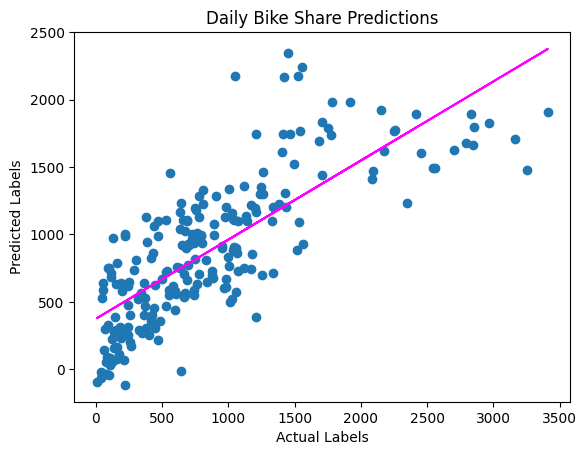

In [ ]:
import matplotlib.pyplot as plt

%matplotlib inline

plt.scatter(y_test, predictions)
plt.xlabel('Actual Labels')
plt.ylabel('Predicted Labels')
plt.title('Daily Bike Share Predictions')
# overlay the regression line
z = np.polyfit(y_test, predictions, 1)
p = np.poly1d(z)
plt.plot(y_test,p(y_test), color='magenta')
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, predictions)
print("MSE:", mse)

rmse = np.sqrt(mse)
print("RMSE:", rmse)

r2 = r2_score(y_test, predictions)
print("R2:", r2)

MSE: 201972.55947035595
RMSE: 449.4135728595165
R2: 0.604045473691919


#####Summary

Here, we've explored our data and fit a basic regression model. In the next notebook, we'll try a number of other regression algorithms to improve performance.

- [Scikit-Learn documentation](https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics).

####Exercise - Experiment with more powerful regression models

#####Explore the Data

In [1]:
# Import modules we'll need for this notebook
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# load the training dataset
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/ml-basics/daily-bike-share.csv
bike_data = pd.read_csv('daily-bike-share.csv')
bike_data['day'] = pd.DatetimeIndex(bike_data['dteday']).day
numeric_features = ['temp', 'atemp', 'hum', 'windspeed']
categorical_features = ['season','mnth','holiday','weekday','workingday','weathersit', 'day']
bike_data[numeric_features + ['rentals']].describe()
print(bike_data.head())


# Separate features and labels
# After separating the dataset, we now have numpy arrays named **X** containing the features, and **y** containing the labels.
X, y = bike_data[['season','mnth', 'holiday','weekday','workingday','weathersit','temp', 'atemp', 'hum', 'windspeed']].values, bike_data['rentals'].values

# Split data 70%-30% into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0)

print ('Training Set: %d rows\nTest Set: %d rows' % (X_train.shape[0], X_test.shape[0]))


--2025-08-09 01:53:57--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/ml-basics/daily-bike-share.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48800 (48K) [text/plain]
Saving to: ‘daily-bike-share.csv’

daily-bike-share.cs 100%[===================>]  47.66K  --.-KB/s    in 0.01s   

2025-08-09 01:53:57 (3.66 MB/s) - ‘daily-bike-share.csv’ saved [48800/48800]

   instant    dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  1/1/2011       1   0     1        0        6           0   
1        2  1/2/2011       1   0     1        0        0           0   
2        3  1/3/2011       1   0     1        0        1           1   
3        4  1/4/2011       1   0     1        0        2  

#####Experiment with Algorithms

![Scikit-Learn Algorithms cheat sheet](https://scikit-learn.org/stable/_downloads/b82bf6cd7438a351f19fac60fbc0d927/ml_map.svg)

######Try Another Linear Algorithm

Lasso() 

MSE: 201155.70593338404
RMSE: 448.5038527519959
R2: 0.6056468637824488


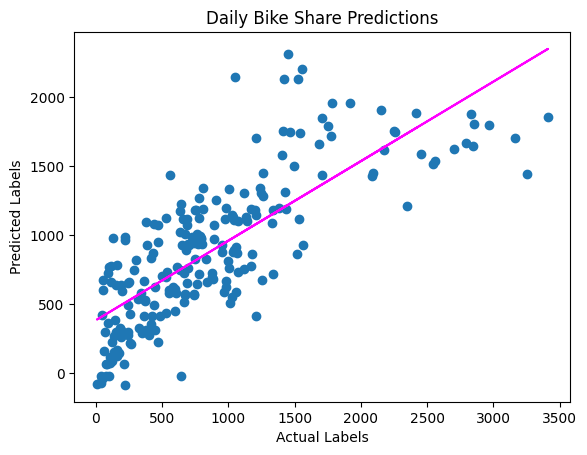

In [2]:
from sklearn.linear_model import Lasso

# Fit a lasso model on the training set
model = Lasso().fit(X_train, y_train)
print (model, "\n")

# Evaluate the model using the test data
predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
print("MSE:", mse)
rmse = np.sqrt(mse)
print("RMSE:", rmse)
r2 = r2_score(y_test, predictions)
print("R2:", r2)

# Plot predicted vs actual
plt.scatter(y_test, predictions)
plt.xlabel('Actual Labels')
plt.ylabel('Predicted Labels')
plt.title('Daily Bike Share Predictions')
# overlay the regression line
z = np.polyfit(y_test, predictions, 1)
p = np.poly1d(z)
plt.plot(y_test,p(y_test), color='magenta')
plt.show()

######Try a Decision Tree Algorithm

In [3]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import export_text

# Train the model
model = DecisionTreeRegressor().fit(X_train, y_train)
print (model, "\n")

# Visualize the model tree
tree = export_text(model)
print(tree)

DecisionTreeRegressor() 

|--- feature_6 <= 0.45
|   |--- feature_4 <= 0.50
|   |   |--- feature_7 <= 0.32
|   |   |   |--- feature_8 <= 0.41
|   |   |   |   |--- feature_1 <= 2.50
|   |   |   |   |   |--- feature_3 <= 3.00
|   |   |   |   |   |   |--- feature_8 <= 0.36
|   |   |   |   |   |   |   |--- value: [558.00]
|   |   |   |   |   |   |--- feature_8 >  0.36
|   |   |   |   |   |   |   |--- value: [515.00]
|   |   |   |   |   |--- feature_3 >  3.00
|   |   |   |   |   |   |--- value: [317.00]
|   |   |   |   |--- feature_1 >  2.50
|   |   |   |   |   |--- feature_8 <= 0.40
|   |   |   |   |   |   |--- feature_6 <= 0.28
|   |   |   |   |   |   |   |--- value: [981.00]
|   |   |   |   |   |   |--- feature_6 >  0.28
|   |   |   |   |   |   |   |--- value: [968.00]
|   |   |   |   |   |--- feature_8 >  0.40
|   |   |   |   |   |   |--- feature_1 <= 7.00
|   |   |   |   |   |   |   |--- value: [710.00]
|   |   |   |   |   |   |--- feature_1 >  7.00
|   |   |   |   |   |   |   |--- val

MSE: 275555.84545454546
RMSE: 524.9341343964454
R2: 0.45979005987498345


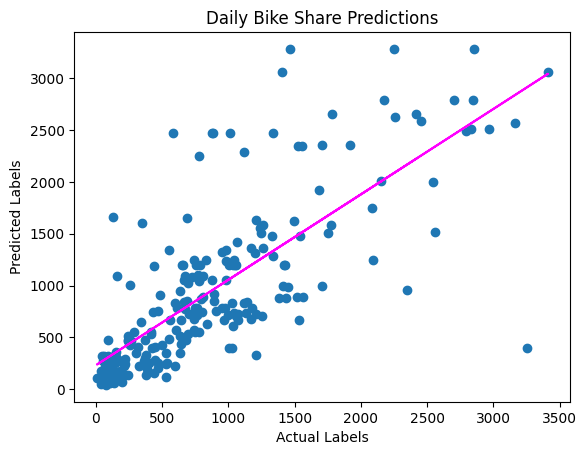

In [4]:
# Evaluate the model using the test data
predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
print("MSE:", mse)
rmse = np.sqrt(mse)
print("RMSE:", rmse)
r2 = r2_score(y_test, predictions)
print("R2:", r2)

# Plot predicted vs actual
plt.scatter(y_test, predictions)
plt.xlabel('Actual Labels')
plt.ylabel('Predicted Labels')
plt.title('Daily Bike Share Predictions')
# overlay the regression line
z = np.polyfit(y_test, predictions, 1)
p = np.poly1d(z)
plt.plot(y_test,p(y_test), color='magenta')
plt.show()

######Try an Ensemble Algorithm

RandomForestRegressor() 

MSE: 112585.80221318183
RMSE: 335.5380786336803
R2: 0.7792826010561169


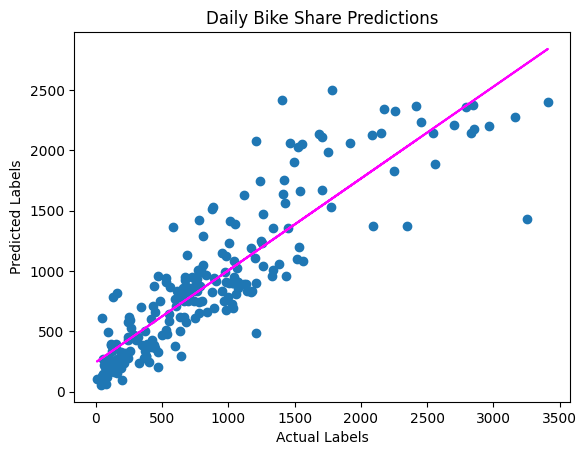

In [5]:
from sklearn.ensemble import RandomForestRegressor

# Train the model
model = RandomForestRegressor().fit(X_train, y_train)
print (model, "\n")

# Evaluate the model using the test data
predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
print("MSE:", mse)
rmse = np.sqrt(mse)
print("RMSE:", rmse)
r2 = r2_score(y_test, predictions)
print("R2:", r2)

# Plot predicted vs actual
plt.scatter(y_test, predictions)
plt.xlabel('Actual Labels')
plt.ylabel('Predicted Labels')
plt.title('Daily Bike Share Predictions')
# overlay the regression line
z = np.polyfit(y_test, predictions, 1)
p = np.poly1d(z)
plt.plot(y_test,p(y_test), color='magenta')
plt.show()

GradientBoostingRegressor() 

MSE: 103641.9985827312
RMSE: 321.9347738016681
R2: 0.7968163667279202


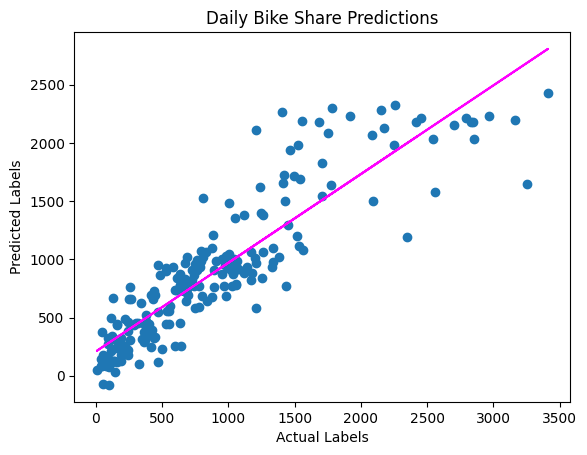

In [6]:
# Train the model
from sklearn.ensemble import GradientBoostingRegressor

# Fit a lasso model on the training set
model = GradientBoostingRegressor().fit(X_train, y_train)
print (model, "\n")

# Evaluate the model using the test data
predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
print("MSE:", mse)
rmse = np.sqrt(mse)
print("RMSE:", rmse)
r2 = r2_score(y_test, predictions)
print("R2:", r2)

# Plot predicted vs actual
plt.scatter(y_test, predictions)
plt.xlabel('Actual Labels')
plt.ylabel('Predicted Labels')
plt.title('Daily Bike Share Predictions')
# overlay the regression line
z = np.polyfit(y_test, predictions, 1)
p = np.poly1d(z)
plt.plot(y_test,p(y_test), color='magenta')
plt.show()

#####Summary

Here, we've tried a number of new regression algorithms to improve performance. In our next notebook, we'll look at tuning these algorithms to improve performance.

####Exercise - Optimize and save models

#####Explore the Data

In [7]:
# Import modules we'll need for this notebook
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# load the training dataset
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/ml-basics/daily-bike-share.csv
bike_data = pd.read_csv('daily-bike-share.csv')
bike_data['day'] = pd.DatetimeIndex(bike_data['dteday']).day
numeric_features = ['temp', 'atemp', 'hum', 'windspeed']
categorical_features = ['season','mnth','holiday','weekday','workingday','weathersit', 'day']
bike_data[numeric_features + ['rentals']].describe()
print(bike_data.head())


# Separate features and labels
# After separating the dataset, we now have numpy arrays named **X** containing the features, and **y** containing the labels.
X, y = bike_data[['season','mnth', 'holiday','weekday','workingday','weathersit','temp', 'atemp', 'hum', 'windspeed']].values, bike_data['rentals'].values

# Split data 70%-30% into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0)

print ('Training Set: %d rows\nTest Set: %d rows' % (X_train.shape[0], X_test.shape[0]))


--2025-08-09 02:19:40--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/ml-basics/daily-bike-share.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48800 (48K) [text/plain]
Saving to: ‘daily-bike-share.csv.1’

daily-bike-share.cs 100%[===================>]  47.66K  --.-KB/s    in 0.01s   

2025-08-09 02:19:40 (3.50 MB/s) - ‘daily-bike-share.csv.1’ saved [48800/48800]

   instant    dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  1/1/2011       1   0     1        0        6           0   
1        2  1/2/2011       1   0     1        0        0           0   
2        3  1/3/2011       1   0     1        0        1           1   
3        4  1/4/2011       1   0     1        0       

GradientBoostingRegressor() 

MSE: 104281.08875436842
RMSE: 322.9258254682775
R2: 0.7955634705580525


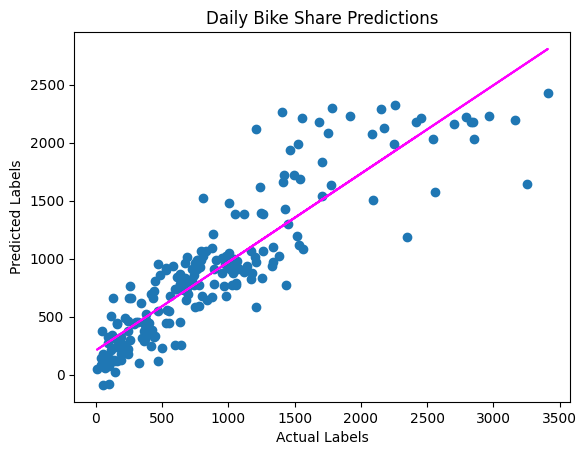

In [8]:
# Train the model
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor


# Fit an ensemble model on the training set
model = GradientBoostingRegressor().fit(X_train, y_train)
print (model, "\n")

# Evaluate the model using the test data
predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
print("MSE:", mse)
rmse = np.sqrt(mse)
print("RMSE:", rmse)
r2 = r2_score(y_test, predictions)
print("R2:", r2)

# Plot predicted vs actual
plt.scatter(y_test, predictions)
plt.xlabel('Actual Labels')
plt.ylabel('Predicted Labels')
plt.title('Daily Bike Share Predictions')
# overlay the regression line
z = np.polyfit(y_test, predictions, 1)
p = np.poly1d(z)
plt.plot(y_test,p(y_test), color='magenta')
plt.show()


#####Optimize Hyperparameters

Best parameter combination: {'learning_rate': 0.1, 'n_estimators': 100} 

GradientBoostingRegressor() 

MSE: 103623.0809323421
RMSE: 321.90539127566984
R2: 0.7968534535941674


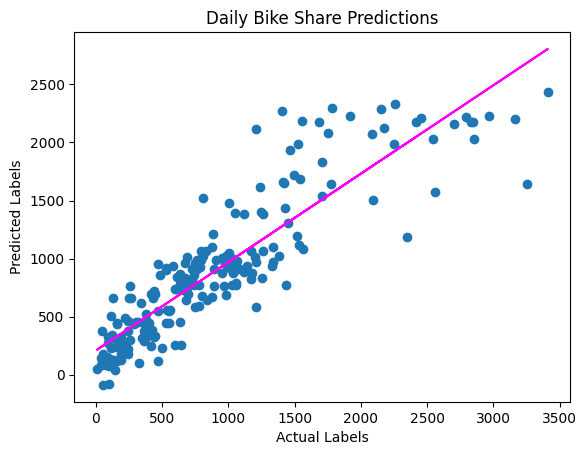

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, r2_score

# Use a Gradient Boosting algorithm
alg = GradientBoostingRegressor()

# Try these hyperparameter values
params = {
 'learning_rate': [0.1, 0.5, 1.0],
 'n_estimators' : [50, 100, 150]
 }

# Find the best hyperparameter combination to optimize the R2 metric
score = make_scorer(r2_score)
gridsearch = GridSearchCV(alg, params, scoring=score, cv=3, return_train_score=True)
gridsearch.fit(X_train, y_train)
print("Best parameter combination:", gridsearch.best_params_, "\n")

# Get the best model
model=gridsearch.best_estimator_
print(model, "\n")

# Evaluate the model using the test data
predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
print("MSE:", mse)
rmse = np.sqrt(mse)
print("RMSE:", rmse)
r2 = r2_score(y_test, predictions)
print("R2:", r2)

# Plot predicted vs actual
plt.scatter(y_test, predictions)
plt.xlabel('Actual Labels')
plt.ylabel('Predicted Labels')
plt.title('Daily Bike Share Predictions')
# overlay the regression line
z = np.polyfit(y_test, predictions, 1)
p = np.poly1d(z)
plt.plot(y_test,p(y_test), color='magenta')
plt.show()

#####Preprocess the Data

In [11]:
# Train the model
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
import numpy as np

# Define preprocessing for numeric columns (scale them)
numeric_features = [6,7,8,9]
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())])

# Define preprocessing for categorical features (encode them)
categorical_features = [0,1,2,3,4,5]
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])

# Create preprocessing and training pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', GradientBoostingRegressor())])


# fit the pipeline to train a linear regression model on the training set
model = pipeline.fit(X_train, (y_train))
print (model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  [6, 7, 8, 9]),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [0, 1, 2, 3, 4, 5])])),
                ('regressor', GradientBoostingRegressor())])


MSE: 105468.26270526333
RMSE: 324.7587761789715
R2: 0.7932360905386848


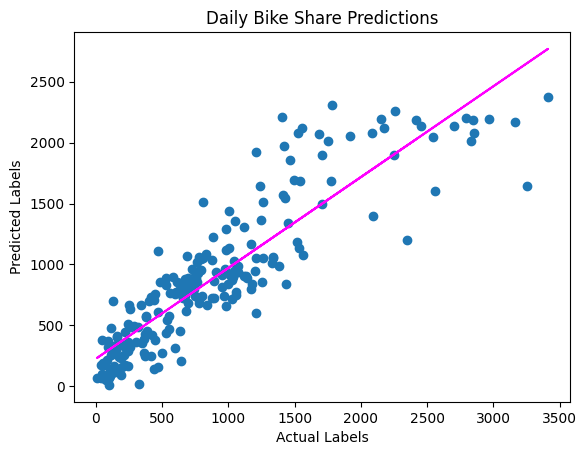

In [12]:
# Get predictions
predictions = model.predict(X_test)

# Display metrics
mse = mean_squared_error(y_test, predictions)
print("MSE:", mse)
rmse = np.sqrt(mse)
print("RMSE:", rmse)
r2 = r2_score(y_test, predictions)
print("R2:", r2)

# Plot predicted vs actual
plt.scatter(y_test, predictions)
plt.xlabel('Actual Labels')
plt.ylabel('Predicted Labels')
plt.title('Daily Bike Share Predictions')
z = np.polyfit(y_test, predictions, 1)
p = np.poly1d(z)
plt.plot(y_test,p(y_test), color='magenta')
plt.show()

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  [6, 7, 8, 9]),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [0, 1, 2, 3, 4, 5])])),
                ('regressor', RandomForestRegressor())]) 

MSE: 104038.54345363636
RMSE: 322.5500634841611
R2: 0.7960389653971112


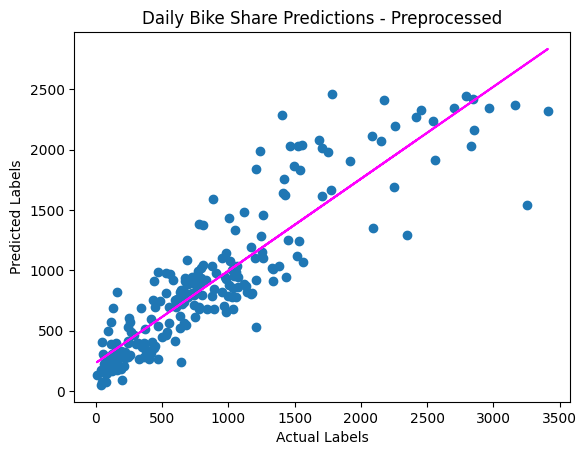

In [13]:
# Use a different estimator in the pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', RandomForestRegressor())])


# fit the pipeline to train a linear regression model on the training set
model = pipeline.fit(X_train, (y_train))
print (model, "\n")

# Get predictions
predictions = model.predict(X_test)

# Display metrics
mse = mean_squared_error(y_test, predictions)
print("MSE:", mse)
rmse = np.sqrt(mse)
print("RMSE:", rmse)
r2 = r2_score(y_test, predictions)
print("R2:", r2)

# Plot predicted vs actual
plt.scatter(y_test, predictions)
plt.xlabel('Actual Labels')
plt.ylabel('Predicted Labels')
plt.title('Daily Bike Share Predictions - Preprocessed')
z = np.polyfit(y_test, predictions, 1)
p = np.poly1d(z)
plt.plot(y_test,p(y_test), color='magenta')
plt.show()

#####Use the Trained Model

In [14]:
import joblib

# Save the model as a pickle file
filename = './bike-share.pkl'
joblib.dump(model, filename)

['./bike-share.pkl']

In [15]:
# Load the model from the file
loaded_model = joblib.load(filename)

# Create a numpy array containing a new observation (for example tomorrow's seasonal and weather forecast information)
X_new = np.array([[1,1,0,3,1,1,0.226957,0.22927,0.436957,0.1869]]).astype('float64')
print ('New sample: {}'.format(list(X_new[0])))

# Use the model to predict tomorrow's rentals
result = loaded_model.predict(X_new)
print('Prediction: {:.0f} rentals'.format(np.round(result[0])))

New sample: [np.float64(1.0), np.float64(1.0), np.float64(0.0), np.float64(3.0), np.float64(1.0), np.float64(1.0), np.float64(0.226957), np.float64(0.22927), np.float64(0.436957), np.float64(0.1869)]
Prediction: 93 rentals


In [16]:
# An array of features based on five-day weather forecast
X_new = np.array([[0,1,1,0,0,1,0.344167,0.363625,0.805833,0.160446],
                  [0,1,0,1,0,1,0.363478,0.353739,0.696087,0.248539],
                  [0,1,0,2,0,1,0.196364,0.189405,0.437273,0.248309],
                  [0,1,0,3,0,1,0.2,0.212122,0.590435,0.160296],
                  [0,1,0,4,0,1,0.226957,0.22927,0.436957,0.1869]])

# Use the model to predict rentals
results = loaded_model.predict(X_new)
print('5-day rental predictions:')
for prediction in results:
    print(np.round(prediction))

5-day rental predictions:
594.0
751.0
253.0
209.0
264.0


#####Summary

This concludes the notebooks for this module on regression. In this notebook, we ran a complex regression, tuned it, saved the model, and used it to predict outcomes for the future.

####Summary

In this module, you learned how you can use regression to create a machine-learning model that predicts numeric values. You then used the scikit-learn framework in Python to train and evaluate a regression model.

While scikit-learn is a popular framework for writing code to train regression models, you can also create machine-learning solutions for regression using the graphical tools in Microsoft Azure Machine Learning. You can learn more about no-code development of regression models using Azure Machine Learning in the Create a Regression Model with Azure Machine Learning designer module.

####[Regression Hands On](https://github.com/TrippleA001/DSN-30-days-of-learning-2025/blob/Personal/Machine%20Learning%20with%20Python%20and%20%20Azure/02_Real_Estate_Regression_Challenge.ipynb)

###Create and understand classification models in machine learning

####Learning objectives

In this module, you will:

- Discover how classification differs from classical regression.
- Build models that can perform classification tasks.
- Explore how to assess and improve classification models.

####Exercise - Build a simple logistic regression model

#####Loading the Data

In [22]:
import pandas
!pip install statsmodels
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/graphing.py
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/avalanche.csv

#Import the data from the .csv file
dataset = pandas.read_csv('avalanche.csv', delimiter="\t", index_col=0)

#Let's have a look at the data
dataset

--2025-08-09 03:55:54--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/graphing.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21511 (21K) [text/plain]
Saving to: ‘graphing.py.4’

graphing.py.4       100%[===================>]  21.01K  --.-KB/s    in 0.002s  

2025-08-09 03:55:54 (8.80 MB/s) - ‘graphing.py.4’ saved [21511/21511]

--2025-08-09 03:55:54--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/avalanche.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, aw

,avalanche,no_visitors,surface_hoar,fresh_thickness,wind,weak_layers,tracked_out
0,0,4,3.900508,8.715485,6,9,0
1,0,9,1.477586,6.801417,30,0,0
2,1,3,3.236594,5.632457,8,8,1
3,0,0,3.244283,9.348871,12,10,0
4,1,2,5.196741,3.782315,4,9,1
...,...,...,...,...,...,...,...
1090,1,1,2.182905,6.109184,3,9,0
1091,0,2,3.718231,10.426100,28,0,0
1092,1,8,7.037647,9.741006,34,3,0
1093,0,2,2.449889,7.337579,37,10,1


#####Data Exploration

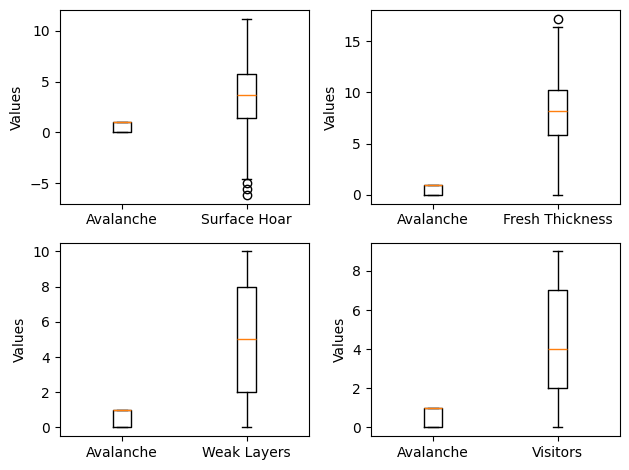

In [23]:
import matplotlib.pyplot as plt

# Create subplots
fig, axs = plt.subplots(2, 2)

# Create box plots
axs[0, 0].boxplot([dataset["avalanche"], dataset["surface_hoar"]])
axs[0, 0].set_xticklabels(['Avalanche', 'Surface Hoar'])
axs[0, 0].set_ylabel('Values')

axs[0, 1].boxplot([dataset["avalanche"], dataset["fresh_thickness"]])
axs[0, 1].set_xticklabels(['Avalanche', 'Fresh Thickness'])
axs[0, 1].set_ylabel('Values')

axs[1, 0].boxplot([dataset["avalanche"], dataset["weak_layers"]])
axs[1, 0].set_xticklabels(['Avalanche', 'Weak Layers'])
axs[1, 0].set_ylabel('Values')

axs[1, 1].boxplot([dataset["avalanche"], dataset["no_visitors"]])
axs[1, 1].set_xticklabels(['Avalanche', 'Visitors'])
axs[1, 1].set_ylabel('Values')

plt.tight_layout()

plt.show()

#####Building a simple logistic regression model

In [25]:
# Here we import a function that splits datasets according to a given ratio
from sklearn.model_selection import train_test_split

# Split the dataset in an 70/30 train/test ratio.
train, test = train_test_split(dataset, test_size=0.3, random_state=2)
print(train.shape)
print(test.shape)

(766, 7)
(329, 7)


In [26]:
import statsmodels.formula.api as smf

# Perform logistic regression.
model = smf.logit("avalanche ~ weak_layers", train).fit()

print("Model trained")

Optimization terminated successfully.
         Current function value: 0.631451
         Iterations 5
Model trained


In [27]:
print(model.summary())

                           Logit Regression Results                           
Dep. Variable:              avalanche   No. Observations:                  766
Model:                          Logit   Df Residuals:                      764
Method:                           MLE   Df Model:                            1
Date:                Sat, 09 Aug 2025   Pseudo R-squ.:                 0.07898
Time:                        04:06:16   Log-Likelihood:                -483.69
converged:                       True   LL-Null:                       -525.17
Covariance Type:            nonrobust   LLR p-value:                 8.395e-20
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -0.8586      0.147     -5.856      0.000      -1.146      -0.571
weak_layers     0.2241      0.026      8.648      0.000       0.173       0.275


#####Using our model

In [28]:
# predict to get a probability

# get first 3 samples from dataset
samples = test["weak_layers"][:4]

# use the model to get predictions as possibilities
estimated_probabilities = model.predict(samples)

# Print results for each sample
for sample, pred in zip(samples,estimated_probabilities):
    print(f"A weak_layer with value {sample} yields a {pred * 100:.2f}% chance of an avalanche.")


A weak_layer with value 5 yields a 56.51% chance of an avalanche.
A weak_layer with value 4 yields a 50.95% chance of an avalanche.
A weak_layer with value 7 yields a 67.05% chance of an avalanche.
A weak_layer with value 0 yields a 29.76% chance of an avalanche.


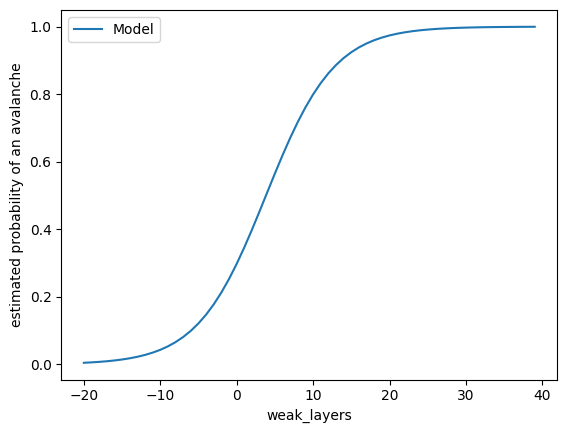

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

predict = lambda x: model.predict(pd.DataFrame({"weak_layers": x}))

# Generate x values
x_values = range(-20, 40)
y_values = predict(x_values)

# Create the plot
plt.plot(x_values, y_values, label="Model")

# Add labels
plt.xlabel("weak_layers")
plt.ylabel("estimated probability of an avalanche")
plt.legend()

plt.show()

In [30]:
print("Minimum number of weak layers:", min(train.weak_layers))
print("Maximum number of weak layers:", max(train.weak_layers))

Minimum number of weak layers: 0
Maximum number of weak layers: 10


In [31]:
import numpy as np

# Get actual rates of avalanches at 0 layers
avalanche_outcomes_for_0_layers = train[train.weak_layers == 0].avalanche
print("Average rate of avalanches for 0 weak layers of snow", np.average(avalanche_outcomes_for_0_layers))

# Get actual rates of avalanches at 10 layers
avalanche_outcomes_for_10_layers = train[train.weak_layers == 10].avalanche
print("Average rate of avalanches for 10 weak layers of snow", np.average(avalanche_outcomes_for_10_layers))

Average rate of avalanches for 0 weak layers of snow 0.3880597014925373
Average rate of avalanches for 10 weak layers of snow 0.7761194029850746


#####Classification or decision thresholds

In [32]:
# threshold to get an absolute value
threshold = 0.5

# Add classification to the samples we used before
for sample, pred in list(zip(samples,estimated_probabilities)):
    print(f"A weak_layer with value {sample} yields a chance of {pred * 100:.2f}% of an avalanche. Classification = {pred > threshold}")

A weak_layer with value 5 yields a chance of 56.51% of an avalanche. Classification = True
A weak_layer with value 4 yields a chance of 50.95% of an avalanche. Classification = True
A weak_layer with value 7 yields a chance of 67.05% of an avalanche. Classification = True
A weak_layer with value 0 yields a chance of 29.76% of an avalanche. Classification = False


#####Performance on test set

In [33]:
# Classify the mdel predictions using the threshold
predictions = model.predict(test) > threshold

# Compare the predictions to the actual outcomes in the dataset
accuracy = np.average(predictions == test.avalanche)

# Print the evaluation
print(f"The model correctly predicted outcomes {accuracy * 100:.2f}% of time.")

The model correctly predicted outcomes 65.05% of time.


#####Summary

In this unit, we covered the following topics:
 - Using Data Exploration to understand which features have a stronger correlation to the outcomes
 - Building a simple Logistic Regression model
 - Using the trained model to predict _probabilities_
 - Using *thresholds* to map probabilities to binary classes
 - How to use a test set to measure the model's performance


####.